# Prädiktive Analyse von Schilddrüsenkarzinom-Rezidiven
Vorhersage und Analyse des Wiederauftretens differenzierter Schilddrüsenkarzinome mit maschinellem Lernen




# Einführung

In [1]:
# ===================================================
# 📦 Allgemeine Bibliotheken
# ===================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Anzeigeoptionen für Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# ===================================================
# 📊 Visualisierung
# ===================================================
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import plotly.express as px
import plotly.offline as py
import plotly.graph_objs as go
from IPython.display import Image, display
py.init_notebook_mode(connected=True)

# ===================================================
# ⚙️ Vorverarbeitung
# ===================================================
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ===================================================
# 📈 Modellierung
# ===================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# ===================================================
# 🔍 Modellbewertung
# ===================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
import scikitplot as skplt  # ROC und weitere Visualisierungen

# ===================================================
# 📊 Validierung & Tuning
# ===================================================
from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score,
    StratifiedKFold, KFold, learning_curve, validation_curve
)
from sklearn.metrics import make_scorer

# ===================================================
# 🧪 Statistische Analyse
# ===================================================
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import boxcox, chi2_contingency

# ===================================================
# ⚠️ Umgang mit Imbalancierten Daten
# ===================================================
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours

# ===================================================
# 🧠 Explainable AI (XAI)
# ===================================================
import shap
import lime
import lime.lime_tabular




ModuleNotFoundError: No module named 'pandas'

In [ ]:
# Lokale Daten einlesen
df = pd.read_csv('Differentiated Thyroid Cancer Recurrence - UCI Machine Learning Repository (Thyroid_Diff).csv')


In [ ]:
# Ursprüngliche Kopie für spätere Vergleiche speichern
df_orig = df.copy()


In [3298]:
print(" Erste 5 Zeilen des Datensatzes:")
display(df.head())


📝 Erste 5 Zeilen des Datensatzes:


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,0
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,0
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,0
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,0
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,0


In [3299]:
print(f"\n Datenform (Zeilen, Spalten): {df.shape}")



🔢 Datenform (Zeilen, Spalten): (383, 17)


In [3300]:
print("\n Dateninfo:")
df.info()



📋 Dateninfo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 

In [3301]:
print("\n Statistische Übersicht:")
display(df.describe())



📊 Statistische Übersicht:


,Age,Recurred
count,383.000000,383.000000
mean,40.866841,0.281984
std,15.134494,0.450554
min,15.000000,0.000000
25%,29.000000,0.000000
50%,37.000000,0.000000
75%,51.000000,1.000000
max,82.000000,1.000000


In [3302]:
print("\n Datentypen der Spalten:")
print(df.dtypes)



🔠 Datentypen der Spalten:
Age                      int64
Gender                  object
Smoking                 object
Hx Smoking              object
Hx Radiothreapy         object
Thyroid Function        object
Physical Examination    object
Adenopathy              object
Pathology               object
Focality                object
Risk                    object
T                       object
N                       object
M                       object
Stage                   object
Response                object
Recurred                 int64
dtype: object


In [3303]:
print("\n Spaltennamen:")
print(df.columns)



🏷️ Spaltennamen:
Index(['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred'],
      dtype='object')


In [3304]:
print("\n Fehlende Werte pro Spalte:")
print(df.isnull().sum())



❓ Fehlende Werte pro Spalte:
Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64


In [3305]:
anzahl_duplikate = df.duplicated().sum()
print(f"\n Anzahl Duplikate: {anzahl_duplikate}")

# Falls vorhanden, entfernen
df = df.drop_duplicates()



🔁 Anzahl Duplikate: 19


In [3306]:
print("\n Fehlende Werte (nach Duplikat-Entfernung):")
print(df.isnull().sum())



🔍 Fehlende Werte (nach Duplikat-Entfernung):
Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64


In [3307]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("\n Spaltennamen nach Bereinigung:")
print(df.columns.tolist())



🆕 Spaltennamen nach Bereinigung:
['age', 'gender', 'smoking', 'hx_smoking', 'hx_radiothreapy', 'thyroid_function', 'physical_examination', 'adenopathy', 'pathology', 'focality', 'risk', 't', 'n', 'm', 'stage', 'response', 'recurred']



🎯 Verteilung der Zielvariable 'recurred':
recurred
0    256
1    108
Name: count, dtype: int64


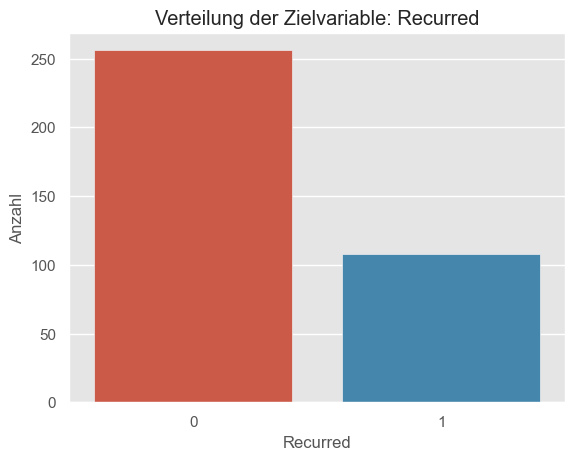

In [3308]:
if 'recurred' in df.columns:
    print("\n Verteilung der Zielvariable 'recurred':")
    print(df['recurred'].value_counts())

    sns.countplot(x='recurred', data=df)
    plt.title('Verteilung der Zielvariable: Recurred')
    plt.xlabel('Recurred')
    plt.ylabel('Anzahl')
    plt.show()


In [3309]:
if 'recurred_binary' in df.columns:
    print("\n Verteilung der Zielvariable 'recurred_binary':")
    print(df['recurred_binary'].value_counts())

    sns.countplot(x='recurred_binary', data=df)
    plt.title('Verteilung der Zielvariable: Recurred (0 = Nein, 1 = Ja)')
    plt.xlabel('Recurred (0 = Nein, 1 = Ja)')
    plt.ylabel('Anzahl')
    plt.show()


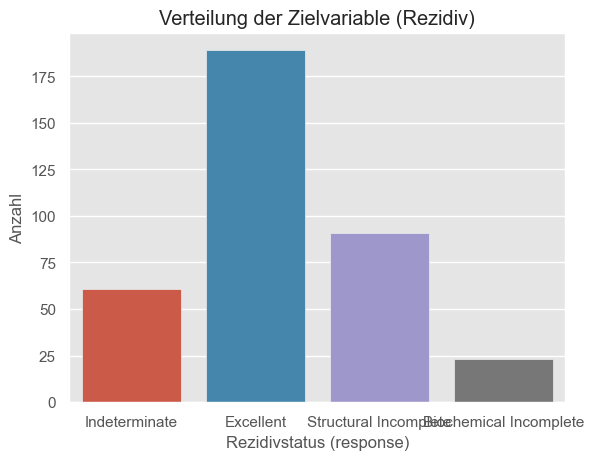

In [3310]:
# Darstellung der Häufigkeit der Zielvariable 'response'
sns.countplot(data=df, x='response')
plt.title("Verteilung der Zielvariable (Rezidiv)")
plt.xlabel("Rezidivstatus (response)")
plt.ylabel("Anzahl")
plt.show()


In [3311]:
print(df.describe(include=[np.number]))


             age    recurred
count  364.00000  364.000000
mean    41.25000    0.296703
std     15.31436    0.457433
min     15.00000    0.000000
25%     30.00000    0.000000
50%     38.00000    0.000000
75%     52.00000    1.000000
max     82.00000    1.000000


In [3312]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 364 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   age                   364 non-null    int64 
 1   gender                364 non-null    object
 2   smoking               364 non-null    object
 3   hx_smoking            364 non-null    object
 4   hx_radiothreapy       364 non-null    object
 5   thyroid_function      364 non-null    object
 6   physical_examination  364 non-null    object
 7   adenopathy            364 non-null    object
 8   pathology             364 non-null    object
 9   focality              364 non-null    object
 10  risk                  364 non-null    object
 11  t                     364 non-null    object
 12  n                     364 non-null    object
 13  m                     364 non-null    object
 14  stage                 364 non-null    object
 15  response              364 non-null    object


In [3313]:
print(df.isnull().sum())


age                     0
gender                  0
smoking                 0
hx_smoking              0
hx_radiothreapy         0
thyroid_function        0
physical_examination    0
adenopathy              0
pathology               0
focality                0
risk                    0
t                       0
n                       0
m                       0
stage                   0
response                0
recurred                0
dtype: int64


In [3314]:
for col in df.columns:
    print(f"Spalte {col}: {df[col].nunique()} einzigartige Werte")
    print(df[col].unique()[:5])  # Nur die ersten 5 einzigartigen Werte


Spalte age: 65 einzigartige Werte
[27 34 30 62 52]
Spalte gender: 2 einzigartige Werte
['F' 'M']
Spalte smoking: 2 einzigartige Werte
['No' 'Yes']
Spalte hx_smoking: 2 einzigartige Werte
['No' 'Yes']
Spalte hx_radiothreapy: 2 einzigartige Werte
['No' 'Yes']
Spalte thyroid_function: 5 einzigartige Werte
['Euthyroid' 'Clinical Hyperthyroidism' 'Clinical Hypothyroidism'
 'Subclinical Hyperthyroidism' 'Subclinical Hypothyroidism']
Spalte physical_examination: 5 einzigartige Werte
['Single nodular goiter-left' 'Multinodular goiter'
 'Single nodular goiter-right' 'Normal' 'Diffuse goiter']
Spalte adenopathy: 6 einzigartige Werte
['No' 'Right' 'Extensive' 'Left' 'Bilateral']
Spalte pathology: 4 einzigartige Werte
['Micropapillary' 'Papillary' 'Follicular' 'Hurthel cell']
Spalte focality: 2 einzigartige Werte
['Uni-Focal' 'Multi-Focal']
Spalte risk: 3 einzigartige Werte
['Low' 'Intermediate' 'High']
Spalte t: 7 einzigartige Werte
['T1a' 'T1b' 'T2' 'T3a' 'T3b']
Spalte n: 3 einzigartige Werte
['

               age  recurred
age       1.000000  0.248926
recurred  0.248926  1.000000


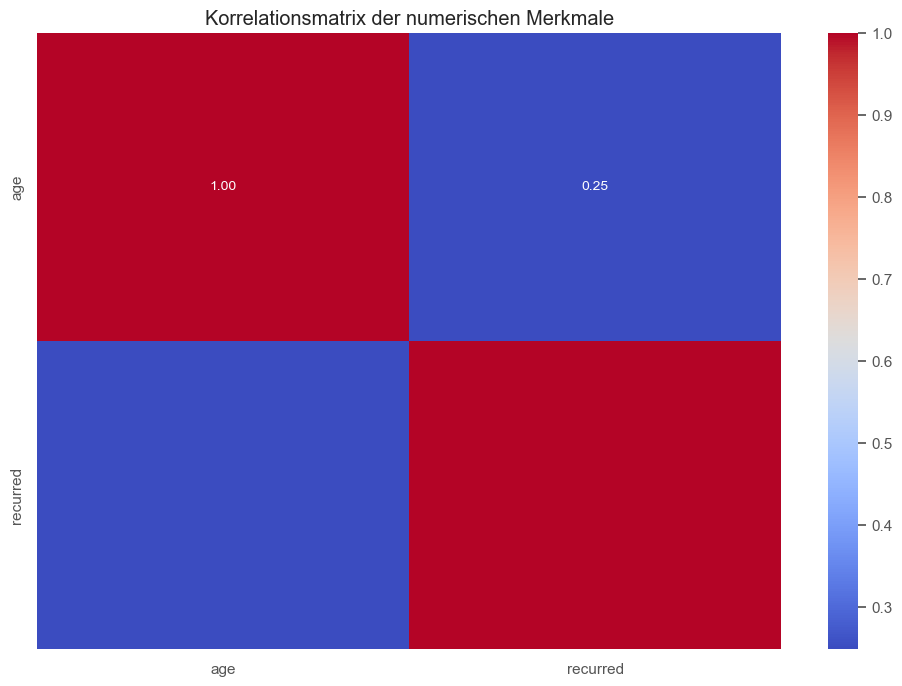

In [3315]:
numerical_data = df.select_dtypes(include=['number'])  # Nur numerische Spalten auswählen
correlation_matrix = numerical_data.corr()
print(correlation_matrix)


plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korrelationsmatrix der numerischen Merkmale")
plt.show()


In [3317]:
print(" Korrelationswerte zwischen den numerischen Merkmalen:\n")
for spalte in correlation_matrix.columns:
    for zeile in correlation_matrix.index:
        if spalte != zeile:  # Selbstkorrelation überspringen
            wert = correlation_matrix.loc[zeile, spalte]
            print(f"Korrelation zwischen {spalte} und {zeile}: {wert:.2f}")


📊 Korrelationswerte zwischen den numerischen Merkmalen:

Korrelation zwischen age und recurred: 0.25
Korrelation zwischen recurred und age: 0.25


In [3318]:
print(df.columns)


Index(['age', 'gender', 'smoking', 'hx_smoking', 'hx_radiothreapy',
       'thyroid_function', 'physical_examination', 'adenopathy', 'pathology',
       'focality', 'risk', 't', 'n', 'm', 'stage', 'response', 'recurred'],
      dtype='object')


Verfügbare Spalten: ['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']
Eindeutige Werte in 'Recurred': ['No' 'Yes']

Verteilung der Zielvariable (Recurred_Binary):
Recurred_Binary
0    275
1    108
Name: count, dtype: int64


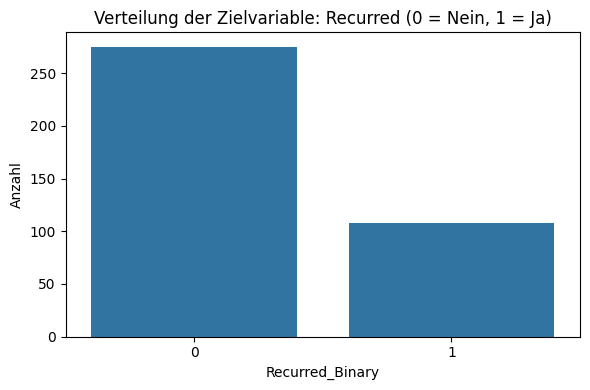

In [17]:
# Read Data


#  Spaltennamen bereinigen (z. B. Leerzeichen entfernen)
df.columns = df.columns.str.strip()

#  Kontrolle: Gibt es die Zielvariable?
print("Verfügbare Spalten:", df.columns.tolist())

#  Eindeutige Werte in der Zielvariable anzeigen
print("Eindeutige Werte in 'Recurred':", df['Recurred'].dropna().unique())

#  Zielvariable binär kodieren: 'Yes' → 1, 'No' → 0
df['Recurred_Binary'] = df['Recurred'].map({'No': 0, 'Yes': 1})

#  Verteilung der binären Zielvariable anzeigen
print("\nVerteilung der Zielvariable (Recurred_Binary):")
print(df['Recurred_Binary'].value_counts())

#  Visualisierung: Rückfallverteilung
plt.figure(figsize=(6, 4))
sns.countplot(x='Recurred_Binary', data=df)
plt.title("Verteilung der Zielvariable: Recurred (0 = Nein, 1 = Ja)")
plt.xlabel("Recurred_Binary")
plt.ylabel("Anzahl")
plt.tight_layout()
plt.show()


In [3320]:
print(df[['Recurred']].head())

print("Anteil NaN:", df['Recurred'].isna().mean())


  Recurred
0       No
1       No
2       No
3       No
4       No
Anteil NaN: 0.0


In [3321]:
df['Recurred_Binary'] = df['Recurred'].map({'No': 0, 'Yes': 1})


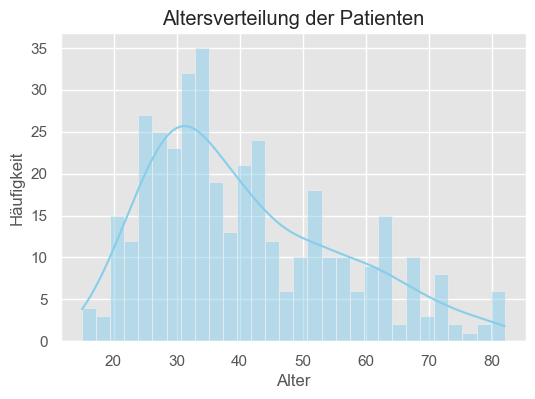

In [3323]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], kde=True, bins=30, color="skyblue")
plt.title("Altersverteilung der Patienten")
plt.xlabel("Alter")
plt.ylabel("Häufigkeit")
plt.show()


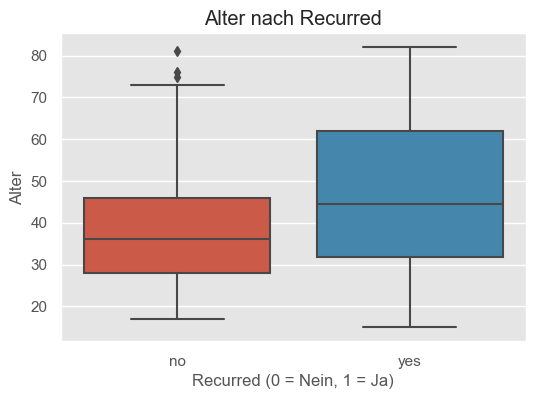

In [3324]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Recurred', y='Age', data=df)
plt.title("Alter nach Recurred")
plt.xlabel("Recurred (0 = Nein, 1 = Ja)")
plt.ylabel("Alter")
plt.show()


In [3325]:
print(" Spalten im DataFrame:")
for col in df.columns:
    print(f" {col}")


📋 Spalten im DataFrame:
🔹 Age
🔹 Gender
🔹 Smoking
🔹 Hx Smoking
🔹 Hx Radiothreapy
🔹 Thyroid Function
🔹 Physical Examination
🔹 Adenopathy
🔹 Pathology
🔹 Focality
🔹 Risk
🔹 T
🔹 N
🔹 M
🔹 Stage
🔹 Response
🔹 Recurred
🔹 Recurred_Binary


In [3326]:
# Sicherstellen, dass `df` ein DataFrame ist
if isinstance(df, pd.DataFrame):
    print(df.columns)
else:
    print(" df ist kein DataFrame!")


Index(['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred',
       'Recurred_Binary'],
      dtype='object')


In [3327]:
def plot_boxplots_with_scaling(df, feature_type, feature_keywords, exclude_keywords=None):
    """
    Skaliert relevante Features und zeigt Boxplots inkl. Statistik.

    :param df: DataFrame mit Windkraftdaten
    :param feature_type: z. B. 'Power', 'Rotation', 'Windspeed'
    :param feature_keywords: Liste von Keywords wie ['min', 'max', 'ava.']
    :param exclude_keywords: optionale Liste für auszuschließende Begriffe
    """

    #  Relevante Spalten filtern
    relevant_columns = [col for col in df.columns if feature_type in col and any(keyword in col for keyword in feature_keywords)]

    #  Bestimmte Keywords ausschließen
    if exclude_keywords:
        relevant_columns = [col for col in relevant_columns if not any(keyword in col.lower() for keyword in exclude_keywords)]

    if relevant_columns:
        #  Skalierung mit MinMax
        scaler = MinMaxScaler()
        scaled_data = scaler.fit_transform(df[relevant_columns])
        scaled_df = pd.DataFrame(scaled_data, columns=relevant_columns)

        #  Statistik anzeigen
        print(f"\n Boxplot-Werte für {feature_type} ({', '.join(feature_keywords)}):")
        print(scaled_df.describe())

        #  Boxplot erstellen
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=scaled_df)
        plt.xticks(rotation=45)
        plt.title(f'Skalierte Boxplots – {feature_type} ({", ".join(feature_keywords)})')
        plt.ylabel('Skalierte Werte (0–1)')
        plt.xlabel('Feature')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    else:
        print(f"⚠ Keine Spalten gefunden für {feature_type} mit {feature_keywords}")

#  Feature-Konfigurationen
feature_types = [
    {'feature_type': 'Power', 'exclude_keywords': ['reactive']},
    {'feature_type': 'reactive Power', 'exclude_keywords': None},
    {'feature_type': 'windspeed', 'exclude_keywords': None},
    {'feature_type': 'Rotation', 'exclude_keywords': None},
]
feature_keywords = ['min', 'max', 'ava.']

#  Für alle Typen durchlaufen
for feature in feature_types:
    plot_boxplots_with_scaling(
        df,
        feature_type=feature['feature_type'],
        feature_keywords=feature_keywords,
        exclude_keywords=feature.get('exclude_keywords')
    )


⚠️ Keine Spalten gefunden für Power mit ['min', 'max', 'ava.']
⚠️ Keine Spalten gefunden für reactive Power mit ['min', 'max', 'ava.']
⚠️ Keine Spalten gefunden für windspeed mit ['min', 'max', 'ava.']
⚠️ Keine Spalten gefunden für Rotation mit ['min', 'max', 'ava.']


In [3328]:
def plot_korrelationsmatrix(df, feature_type, exclude_keywords=None):
    """
    Zeichnet die Korrelationsmatrix für bestimmte Features (z. B. Power, Rotation).
    
    :param df: Pandas DataFrame mit Windkraft-Daten
    :param feature_type: z. B. 'Power', 'Reactive Power', 'windspeed', 'Rotation'
    :param exclude_keywords: Begriffe, die aus der Spaltenliste ausgeschlossen werden sollen
    """

    #  Relevante Spalten: müssen feature_type und 'min', 'max', 'ava.' enthalten
    relevante_spalten = [col for col in df.columns if feature_type in col and
                         any(keyword in col.lower() for keyword in ['min', 'max', 'ava.'])]

    #  Ausschluss-Keywords beachten
    if exclude_keywords:
        relevante_spalten = [col for col in relevante_spalten if not any(keyword in col.lower() for keyword in exclude_keywords)]

    if relevante_spalten:
        #  Korrelationsmatrix berechnen
        corr_matrix = df[relevante_spalten].corr()

        #  Heatmap plotten
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
                    annot_kws={"fontsize": 10})
        plt.title(f'Korrelationsmatrix für {feature_type}', fontsize=14)
        plt.xticks(rotation=45, fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        plt.show()

        #  Matrix auch im Text ausgeben
        print(f"\n Korrelationsmatrix für {feature_type}:")
        print(corr_matrix)
    else:
        print(f"⚠ Keine relevanten Spalten für {feature_type} gefunden.")

#  Anwenden auf die verschiedenen Typen
plot_korrelationsmatrix(df, feature_type='Power', exclude_keywords=['reactive'])
plot_korrelationsmatrix(df, feature_type='reactive Power')
plot_korrelationsmatrix(df, feature_type='windspeed')
plot_korrelationsmatrix(df, feature_type='Rotation')


⚠️ Keine relevanten Spalten für Power gefunden.
⚠️ Keine relevanten Spalten für reactive Power gefunden.
⚠️ Keine relevanten Spalten für windspeed gefunden.
⚠️ Keine relevanten Spalten für Rotation gefunden.


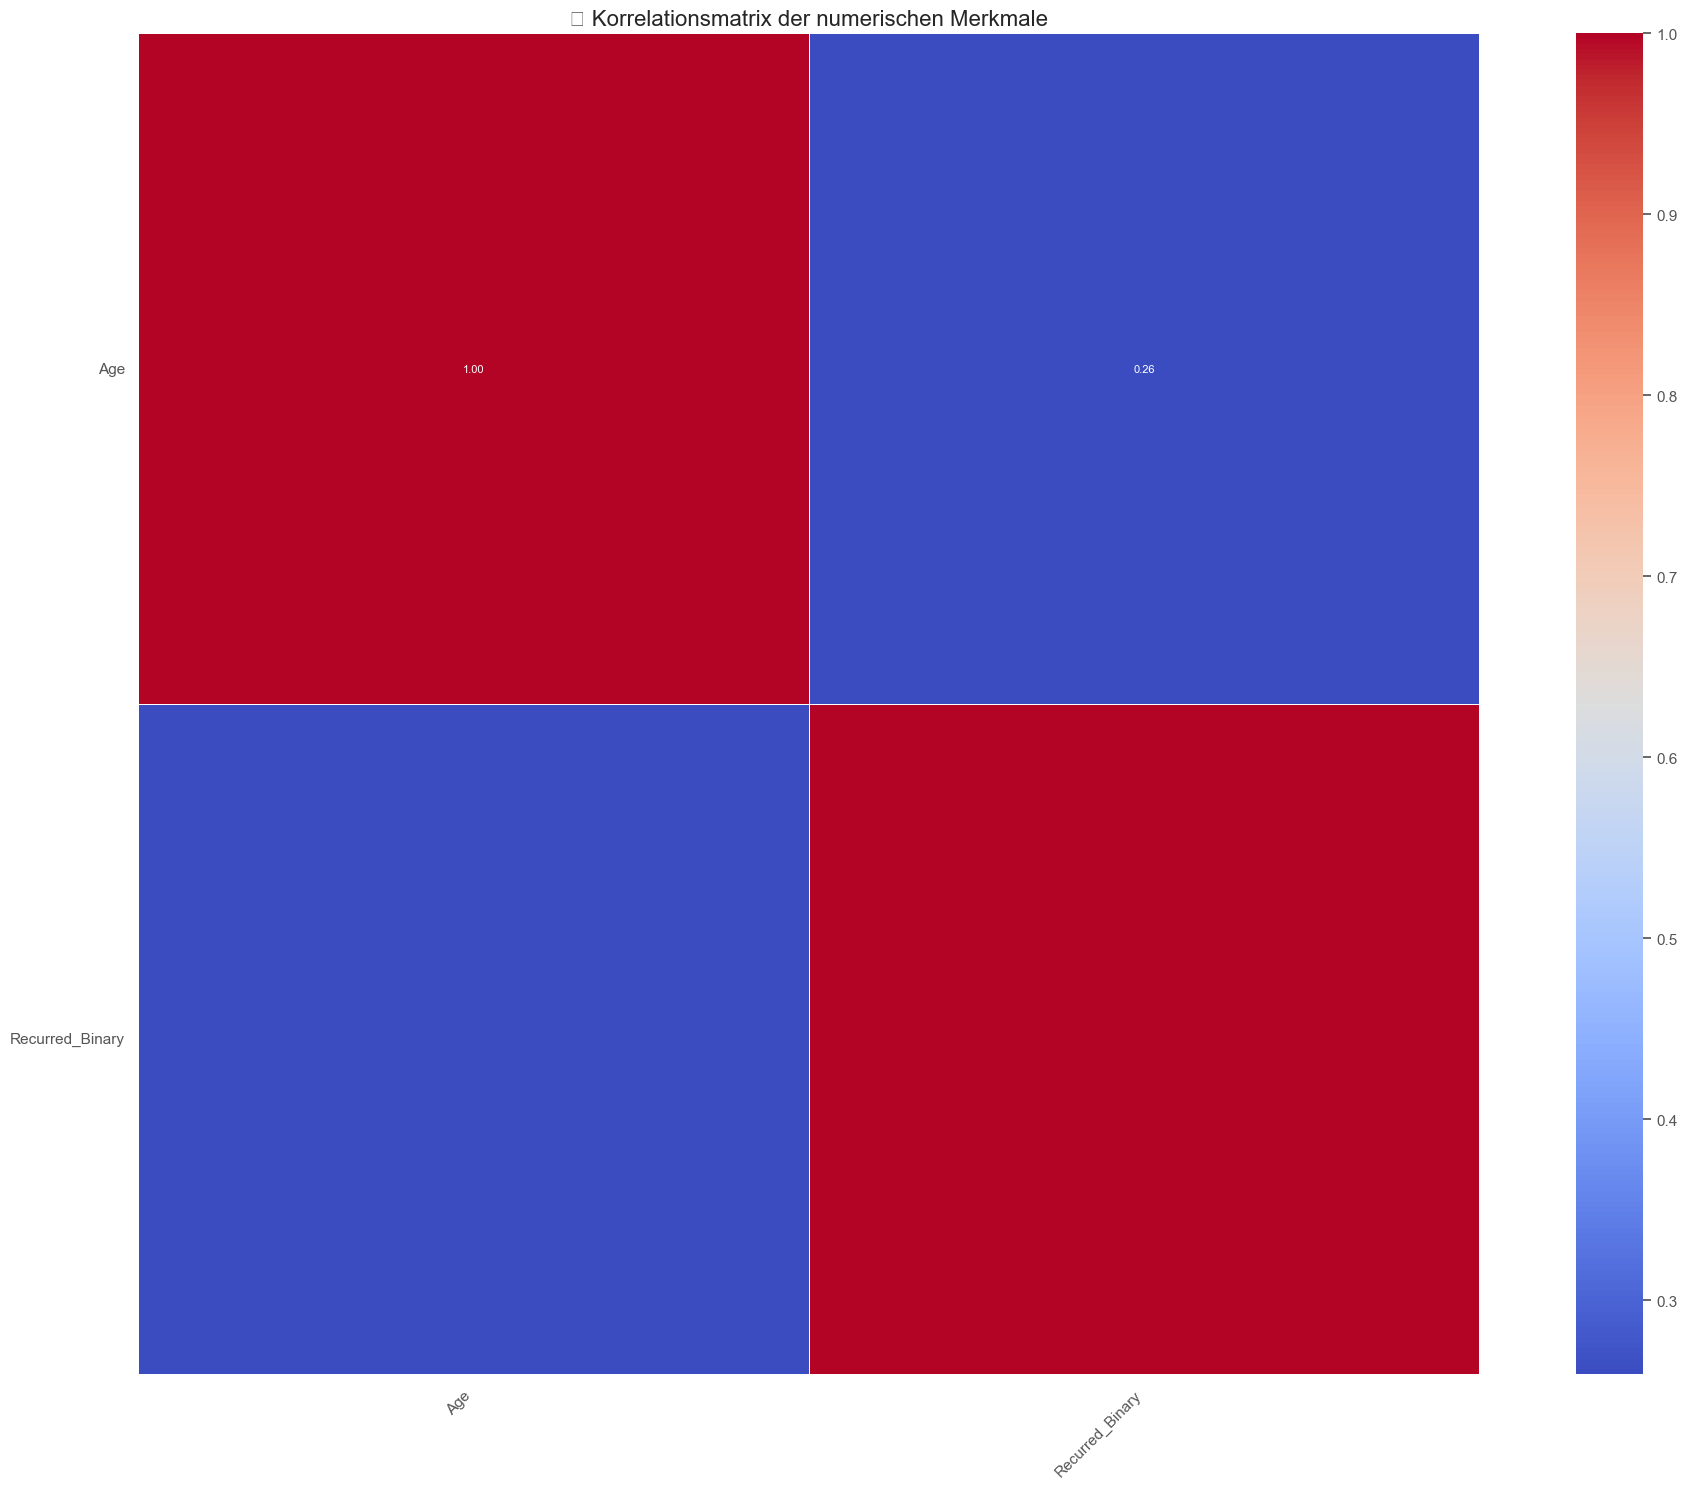

In [3329]:
#  Nur numerische Spalten für die Korrelation wählen
df_num = df.select_dtypes(include=['int64', 'float64'])

#  Korrelationsmatrix berechnen
correlation_matrix = df_num.corr()

#  Heatmap zeichnen
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            cbar=True, square=True, linewidths=0.5, annot_kws={"size": 8})
plt.title(' Korrelationsmatrix der numerischen Merkmale', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [3330]:
#  Schritt 1: Spaltennamen von Leerzeichen befreien
df.columns = df.columns.str.strip()

#  Schritt 2: Nur numerische Merkmale auswählen
X_numeric = df.select_dtypes(include=[np.number]).copy()

#  Schritt 3: Fehlende Werte ersetzen (je nach Kontext auch Median/Mean möglich)
X_numeric.fillna(0, inplace=True)

# ➕ Schritt 4: Konstante für VIF-Berechnung hinzufügen
X_numeric_const = add_constant(X_numeric)

#  Schritt 5: VIF-Werte berechnen
vif_df = pd.DataFrame()
vif_df["Merkmal"] = X_numeric_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_numeric_const.values, i) 
                 for i in range(X_numeric_const.shape[1])]

#  Schritt 6: Merkmale mit mittlerer Multikollinearität (VIF zwischen 6 und 10)
vif_relevant = vif_df[(vif_df["VIF"] >= 6) & (vif_df["VIF"] <= 10)]

#  Schritt 7: Korrelation mit 'Error' berechnen (falls existiert)
if 'Error' in df.columns:
    korrelation_error = X_numeric.corrwith(df['Error']).abs()

    #  Schritt 8: Nur Merkmale, die sowohl relevanten VIF als auch Korrelation > 0 haben
    ausgewaehlte_merkmale = vif_relevant[
        vif_relevant["Merkmal"].isin(korrelation_error[korrelation_error > 0].index)
    ]

    #  Ergebnis anzeigen
    print(" Ausgewählte Merkmale mit VIF 6–10 und Korrelation mit 'Error':")
    print(ausgewaehlte_merkmale.sort_values("VIF", ascending=False))
else:
    print("⚠ Die Spalte 'Error' wurde im DataFrame nicht gefunden.")
    print(" Verfügbare Spalten sind:", df.columns.tolist())


⚠️ Die Spalte 'Error' wurde im DataFrame nicht gefunden.
👉 Verfügbare Spalten sind: ['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred', 'Recurred_Binary']


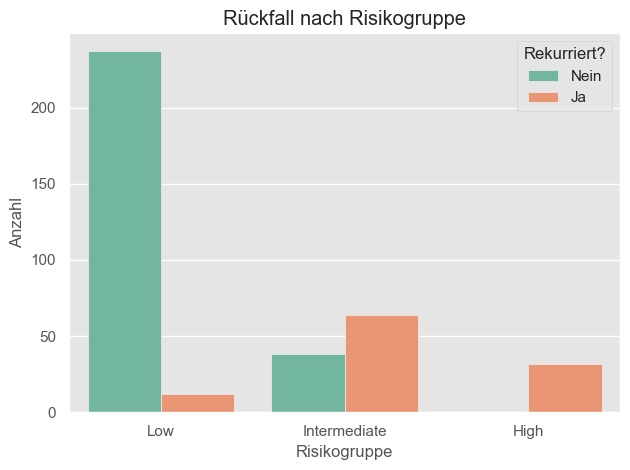

In [3331]:
# Recurred_Binary als String für saubere Legende
df_thyroid['Recurred_Binary_Str'] = df_thyroid['Recurred_Binary'].map({0: 'Nein', 1: 'Ja'})

#  Visualisierung: Rückfall nach Risikogruppe
sns.countplot(data=df_thyroid, x='Risk_Group', hue='Recurred_Binary_Str', palette='Set2')
plt.title("Rückfall nach Risikogruppe")
plt.xlabel("Risikogruppe")
plt.ylabel("Anzahl")
plt.legend(title='Rekurriert?')
plt.tight_layout()
plt.show()


In [3332]:
print(df.columns.tolist())
print(df['Recurred'].unique())
print(df['Recurred'].isna().sum())


['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred', 'Recurred_Binary']
['no' 'yes']
0


In [3333]:
# NaN and empty 
df = df[df['Recurred'].notna()]
df = df[df['Recurred'].isin(['Yes', 'No'])]

# Binary 
df['Recurred_Binary'] = df['Recurred'].map({'Yes': 1, 'No': 0})


In [3334]:
#  Nur gültige Werte behalten ('Yes' oder 'No')
df = df[df['Recurred'].isin(['Yes', 'No'])].copy()

#  Zielvariable binär kodieren
df['Recurred_Binary'] = df['Recurred'].map({'Yes': 1, 'No': 0})

#  Verteilung anzeigen
print("Verteilung der Zielvariable (Recurred_Binary):")
print(df['Recurred_Binary'].value_counts(dropna=False))

#  Sicherstellen, dass genügend Daten vorhanden sind
if df['Recurred_Binary'].notna().sum() == 0:
    print(" Keine gültigen Werte in 'Recurred_Binary'. Grafik wird nicht gezeichnet.")
else:
    #  Plot erstellen
    sns.countplot(x='Recurred_Binary', data=df)
    plt.title("Verteilung der Rückfälle (0=Nein, 1=Ja)")
    plt.xlabel("Recurred")
    plt.ylabel("Anzahl")
    plt.tight_layout()
    plt.show()


Verteilung der Zielvariable (Recurred_Binary):
Series([], Name: count, dtype: int64)
❌ Keine gültigen Werte in 'Recurred_Binary'. Grafik wird nicht gezeichnet.


In [3335]:
# Recurred überprüfung und bereinigen
if 'Recurred' in df.columns:
    df = df[df['Recurred'].isin(['Yes', 'No'])].copy()
    df['Recurred_Binary'] = df['Recurred'].map({'Yes': 1, 'No': 0})
    
    if df['Recurred_Binary'].notna().sum() > 0:
        print("Verteilung der Zielvariable (Recurred_Binary):")
        print(df['Recurred_Binary'].value_counts())

        sns.countplot(x='Recurred_Binary', data=df)
        plt.title("Verteilung der Rückfälle (0=Nein, 1=Ja)")
        plt.xlabel("Recurred")
        plt.ylabel("Anzahl")
        plt.tight_layout()
        plt.show()
    else:
        print(" Keine gültigen Werte in 'Recurred_Binary'.")
else:
    print(" Spalte 'Recurred' nicht im DataFrame gefunden.")


❌ Keine gültigen Werte in 'Recurred_Binary'.


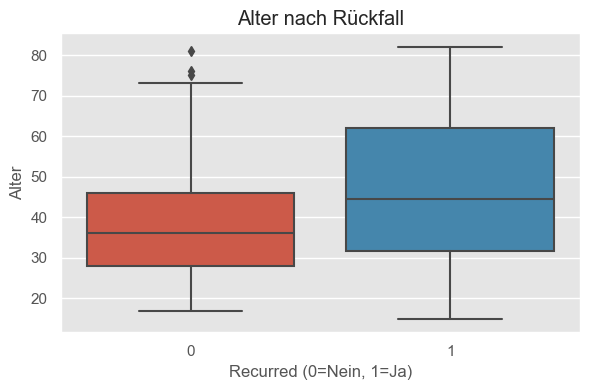

In [3336]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Recurred_Binary', y='Age', data=df_thyroid)
plt.title("Alter nach Rückfall")
plt.xlabel("Recurred (0=Nein, 1=Ja)")
plt.ylabel("Alter")
plt.tight_layout()
plt.show()


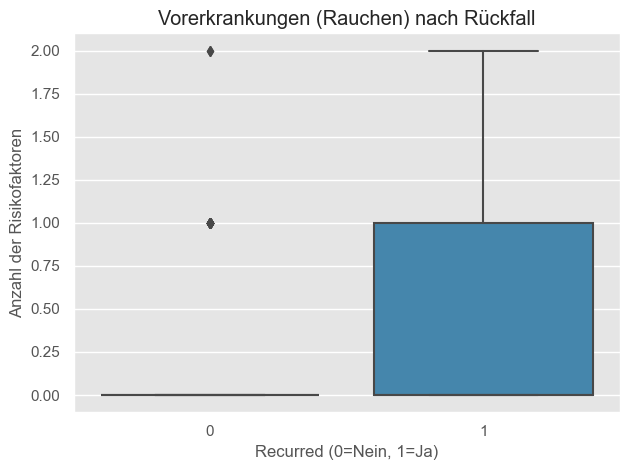

In [3337]:
# Beispiel: Vorerkrankungen zusammenfassen
df_thyroid['Total_Smoking_Factors'] = df_thyroid[['Smoking', 'Hx Smoking']].apply(lambda row: sum(val == 'Yes' for val in row), axis=1)

# Verteilung ansehen
sns.boxplot(x='Recurred_Binary', y='Total_Smoking_Factors', data=df_thyroid)
plt.title("Vorerkrankungen (Rauchen) nach Rückfall")
plt.xlabel("Recurred (0=Nein, 1=Ja)")
plt.ylabel("Anzahl der Risikofaktoren")
plt.tight_layout()
plt.show()


In [3338]:
#  Potenziell irrelevante Spalten identifizieren und entfernen

# Leere Liste zum Speichern zu entfernender Spalten
drop_cols = []

# Beispiel: Falls eine Patienten-ID-Spalte vorhanden ist
if 'patientid' in df.columns:
    drop_cols.append('patientid')

# Beispiel: Spalten mit nur einem einzigartigen Wert (keine Variabilität)
for col in df.columns:
    if df[col].nunique() == 1:
        drop_cols.append(col)

# Spalten entfernen, wenn welche gefunden wurden
if drop_cols:
    df = df.drop(columns=drop_cols)
    print(f" Entfernte Spalten aufgrund fehlender Relevanz: {drop_cols}")
else:
    print(" Keine irrelevanten Spalten zum Entfernen gefunden.")


✅ Keine irrelevanten Spalten zum Entfernen gefunden.


Visualising processed data

📈 Verteilungsdiagramme (Histogramme):


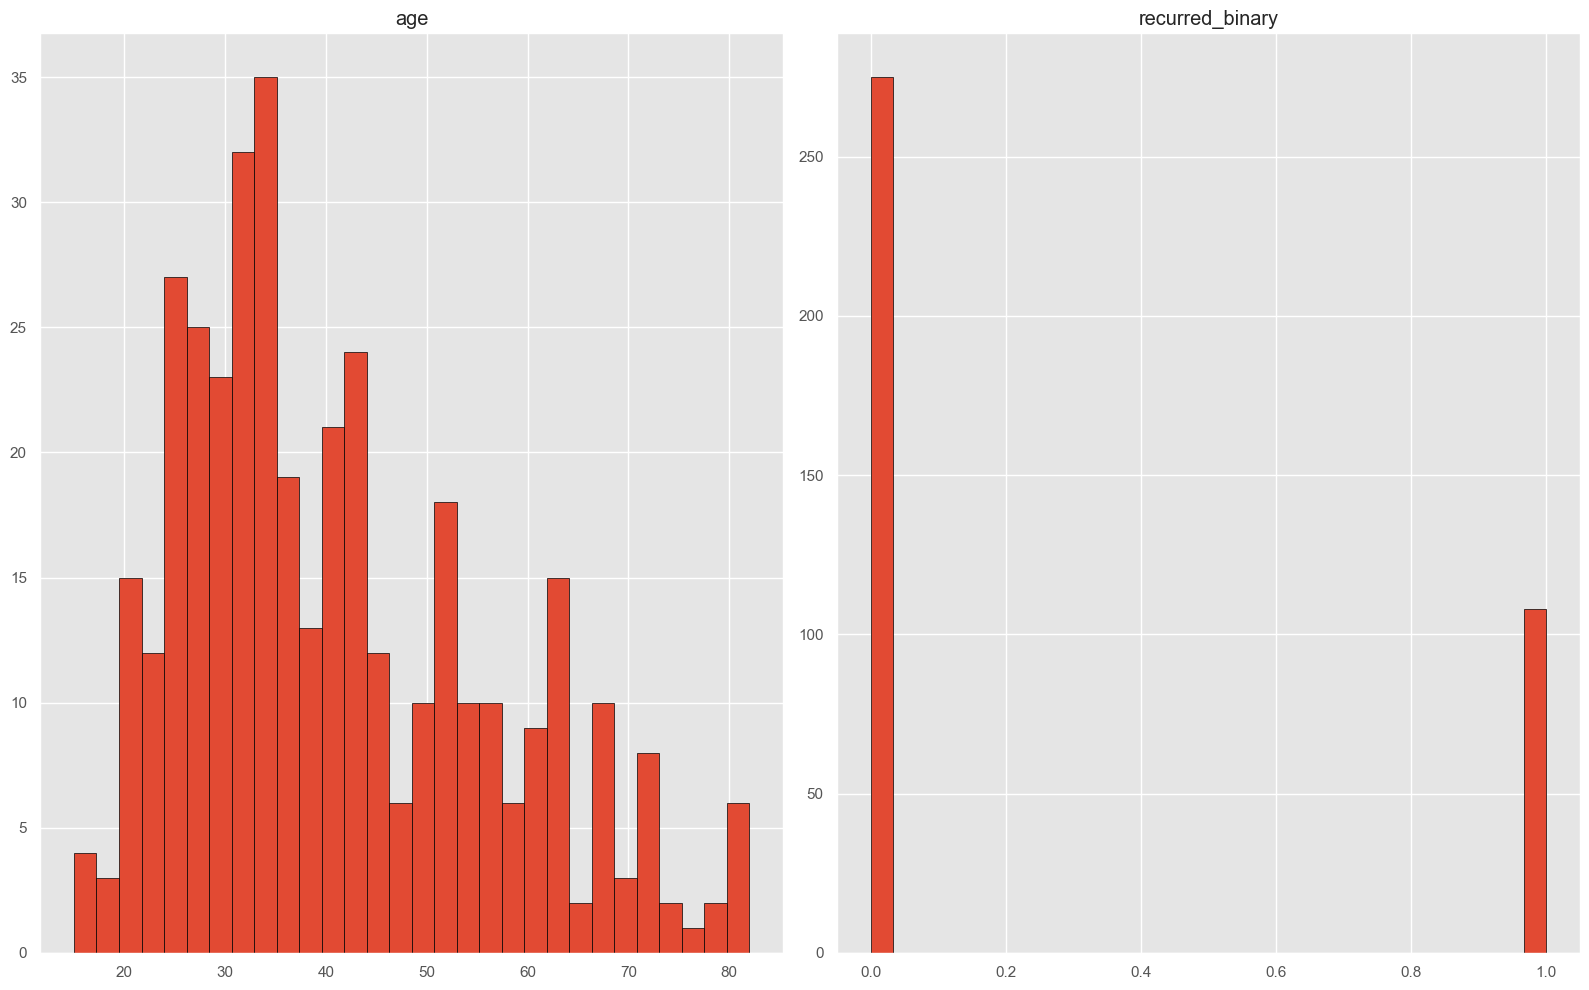

📊 Korrelationsmatrix:


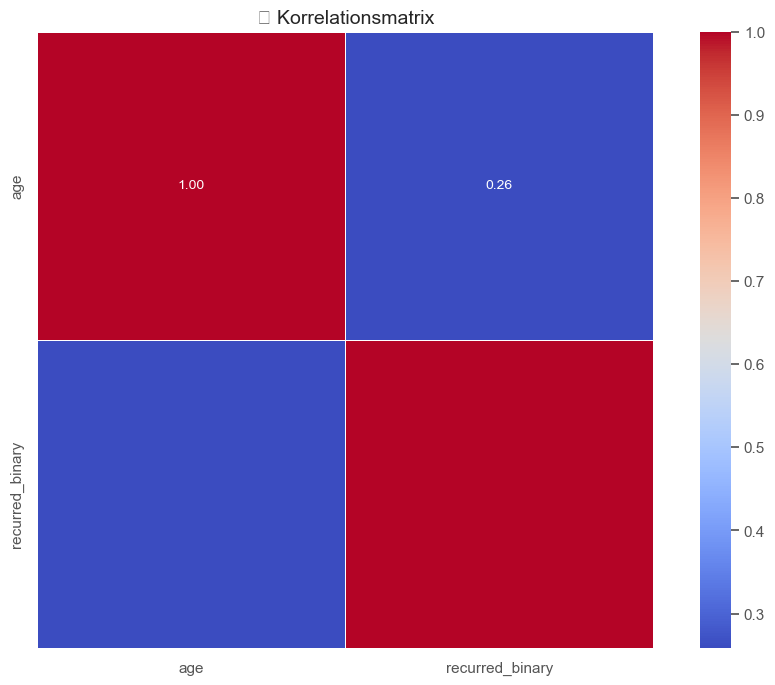

In [3341]:
# EDA mit df_model (bereinigter Datensatz mit Zielvariable)
plt.style.use("ggplot")

# Histogramme für numerische Spalten
print(" Verteilungsdiagramme (Histogramme):")
df_model.hist(bins=30, figsize=(16, 10), edgecolor='black')
plt.tight_layout()
plt.show()

# Korrelationsmatrix berechnen
print(" Korrelationsmatrix:")
corr_matrix = df_model.corr(numeric_only=True)

# Heatmap anzeigen
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title(" Korrelationsmatrix", fontsize=14)
plt.show()


In [3342]:
print(df.columns.tolist())


['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred', 'Recurred_Binary']


In [3343]:
df.columns = df.columns.str.strip().str.lower()  # alles klein & ohne Leerzeichen
print(df.columns.tolist())  # nochmal prüfen


['age', 'gender', 'smoking', 'hx smoking', 'hx radiothreapy', 'thyroid function', 'physical examination', 'adenopathy', 'pathology', 'focality', 'risk', 't', 'n', 'm', 'stage', 'response', 'recurred', 'recurred_binary']


In [3348]:
# Gini-Funktion (defined)
def gini_unreinheit(anzahl_positiv, anzahl_total):
    if anzahl_total == 0:
        return 0
    p_pos = anzahl_positiv / anzahl_total
    p_neg = 1 - p_pos
    return 1 - (p_pos**2 + p_neg**2)

# Beispielwerte (muss noch)
gesamt_pos = 60
gesamt_total = 610
gini_start = gini_unreinheit(gesamt_pos, gesamt_total)

# Gruppe A: z. B. 'Male'
gruppe_a_total = 350
gruppe_a_pos = 20
gini_a = gini_unreinheit(gruppe_a_pos, gruppe_a_total)

# Gruppe B: z. B. 'Female'
gruppe_b_total = 260
gruppe_b_pos = 40
gini_b = gini_unreinheit(gruppe_b_pos, gruppe_b_total)

# Gewichtete Gini nach Split
gewichtete_gini = (gruppe_a_total/gesamt_total)*gini_a + (gruppe_b_total/gesamt_total)*gini_b

# Gini-Gewinn berechnen
gini_abnahme = gini_start - gewichtete_gini
print(f" Gini-Abnahme durch Split: {gini_abnahme:.4f}")


📉 Gini-Abnahme durch Split: 0.0046


In [3349]:
#  Spaltennamen bereinigen (alles klein, Leerzeichen → Unterstrich)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

#  Spalten anzeigen
print(df.columns.tolist())


['age', 'gender', 'smoking', 'hx_smoking', 'hx_radiothreapy', 'thyroid_function', 'physical_examination', 'adenopathy', 'pathology', 'focality', 'risk', 't', 'n', 'm', 'stage', 'response', 'recurred']


In [3350]:
#  Nur gültige Rückfall-Werte behalten ('Yes' oder 'No')
df = df[df['recurred'].isin(['Yes', 'No'])]

#  Zielvariable in binäre Form bringen
df['recurred_binary'] = df['recurred'].map({'No': 0, 'Yes': 1})

#  Verteilung anzeigen
print(" Verteilung der Zielvariable:")
print(df['recurred_binary'].value_counts())


📊 Verteilung der Zielvariable:
recurred_binary
0    275
1    108
Name: count, dtype: int64


/var/folders/8k/wdf_0j5n503bm9rv_8l65lxr0000gn/T/ipykernel_75953/388368997.py:64: UserWarning: Glyph 9935 (\N{PICK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8k/wdf_0j5n503bm9rv_8l65lxr0000gn/T/ipykernel_75953/388368997.py:64: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/Users/nk/Documents/Zookul/DS3/AML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9935 (\N{PICK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nk/Documents/Zookul/DS3/AML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


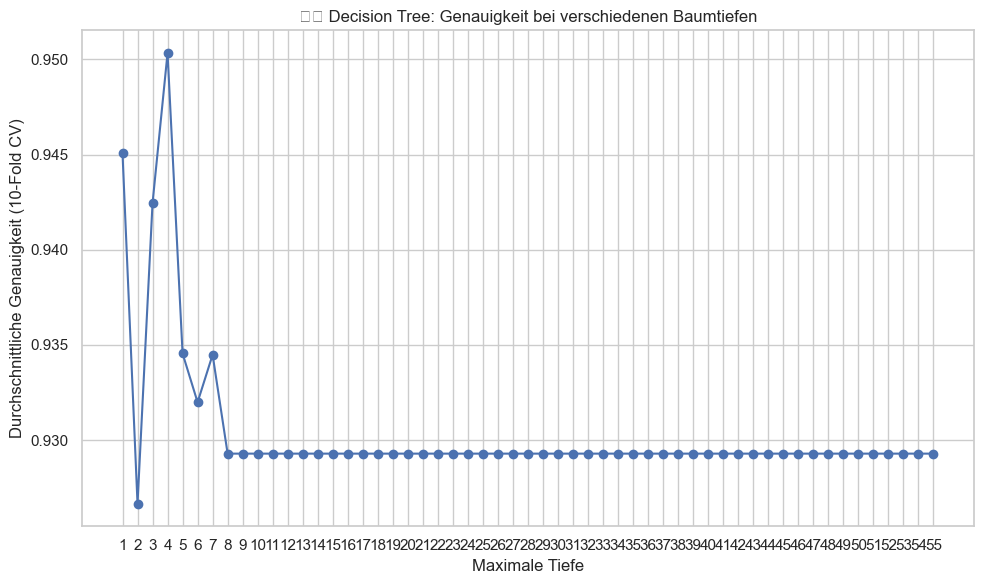

In [23]:
# 🔧 Stil für Diagramme
sns.set(style="whitegrid")

# ===================================================
# 📥 Daten einlesen und vorbereiten
# ===================================================
# CSV-Datei einlesen
df = pd.read_csv("Differentiated Thyroid Cancer Recurrence - UCI Machine Learning Repository (Thyroid_Diff).csv")

# Spaltennamen bereinigen
df.columns = df.columns.str.strip()

# Zielvariable binär kodieren: 'Yes' → 1, 'No' → 0
df['Recurred_Binary'] = df['Recurred'].map({'No': 0, 'Yes': 1})

# Features definieren (Ziel + Originalziel entfernen)
X = df.drop(columns=['Recurred', 'Recurred_Binary'])
y = df['Recurred_Binary']

# One-Hot-Encoding für kategoriale Merkmale
X_encoded = pd.get_dummies(X)

# ===================================================
# 🔁 K-Fold Cross-Validation mit verschiedenen Tiefen
# ===================================================
cv = KFold(n_splits=10, shuffle=True, random_state=42)
accuracies = []
depth_range = range(1, X_encoded.shape[1] + 1)

for depth in depth_range:
    fold_accuracy = []
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)

    for train_idx, valid_idx in cv.split(X_encoded):
        X_train, X_valid = X_encoded.iloc[train_idx], X_encoded.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = clf.fit(X_train, y_train)
        accuracy = model.score(X_valid, y_valid)
        fold_accuracy.append(accuracy)

    accuracies.append(np.mean(fold_accuracy))

# ===================================================
# 📊 Ergebnis visualisieren
# ===================================================
plt.figure(figsize=(10, 6))
plt.plot(depth_range, accuracies, marker='o')
plt.title("⛏️ Decision Tree: Genauigkeit bei verschiedenen Baumtiefen")
plt.xlabel("Maximale Tiefe")
plt.ylabel("Durchschnittliche Genauigkeit (10-Fold CV)")
plt.xticks(depth_range)
plt.grid(True)
plt.tight_layout()
plt.show()


In [3353]:
#  Ergebnisse als DataFrame
df_results = pd.DataFrame({
    "Maximale_Tiefe": depth_range,
    "Durchschnittliche_Genauigkeit": accuracies
})

#  Anzeigen
print(df_results.to_string(index=False))


 Maximale_Tiefe  Durchschnittliche_Genauigkeit
              1                       0.945074
              2                       0.924022
              3                       0.955533
              4                       0.950202
              5                       0.947638
              6                       0.942375
              7                       0.926653
              8                       0.929285
              9                       0.924089
             10                       0.924089
             11                       0.924089
             12                       0.924089
             13                       0.924089
             14                       0.924089
             15                       0.924089
             16                       0.924089


✅ Entscheidungsbaum wurde als 'baum.dot' gespeichert.
✅ PNG wurde erfolgreich erstellt – baum.png


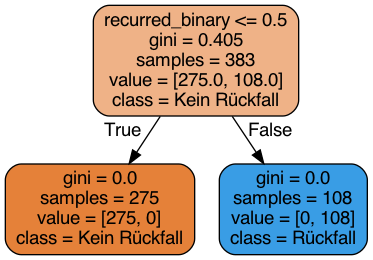

In [3354]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")  # z. B. 'Recurred' → 'recurred'

#  Zielvariable und Features trennen
X = df.drop(['recurred'], axis=1)
y = df['recurred']

#  Kategorische Features numerisch kodieren (Label-Encoding)
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category').cat.codes

#  Decision Tree Modell erstellen und trainieren
clf = tree.DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

#  Modell als .dot-Datei exportieren
with open("baum.dot", "w") as f:
    tree.export_graphviz(clf,
                         out_file=f,
                         max_depth=3,
                         impurity=True,
                         feature_names=X.columns,
                         class_names=['Kein Rückfall', 'Rückfall'],
                         rounded=True,
                         filled=True)

print(" Entscheidungsbaum wurde als 'baum.dot' gespeichert.")

#  .dot-Datei in .png umwandeln (Graphviz muss installiert sein)
!dot -Tpng baum.dot -o baum.png

#  PNG im Notebook anzeigen
if os.path.exists("baum.png"):
    print(" PNG wurde erfolgreich erstellt – baum.png")
    display(Image(filename='baum.png'))
else:
    print(" PNG konnte nicht erstellt werden.")


In [3355]:
acc_decision_tree = round(clf.score(X, y) * 100, 2)
print(f" Trainingsgenauigkeit: {acc_decision_tree}%")


🎯 Trainingsgenauigkeit: 100.0%


In [3356]:
print(os.path.exists("baum.dot"))    
print(os.path.exists("baum.png"))


True
True


In [3357]:
import os
print(os.path.abspath("tree1.dot"))


/Users/nk/Documents/Zookul/DS3/AML/AML_4/tree1.dot


✅ Finaler Datensatz: 383 Stichproben, 52 Merkmale


/var/folders/8k/wdf_0j5n503bm9rv_8l65lxr0000gn/T/ipykernel_75953/1223851812.py:90: UserWarning: Glyph 9935 (\N{PICK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8k/wdf_0j5n503bm9rv_8l65lxr0000gn/T/ipykernel_75953/1223851812.py:90: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/Users/nk/Documents/Zookul/DS3/AML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9935 (\N{PICK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nk/Documents/Zookul/DS3/AML/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


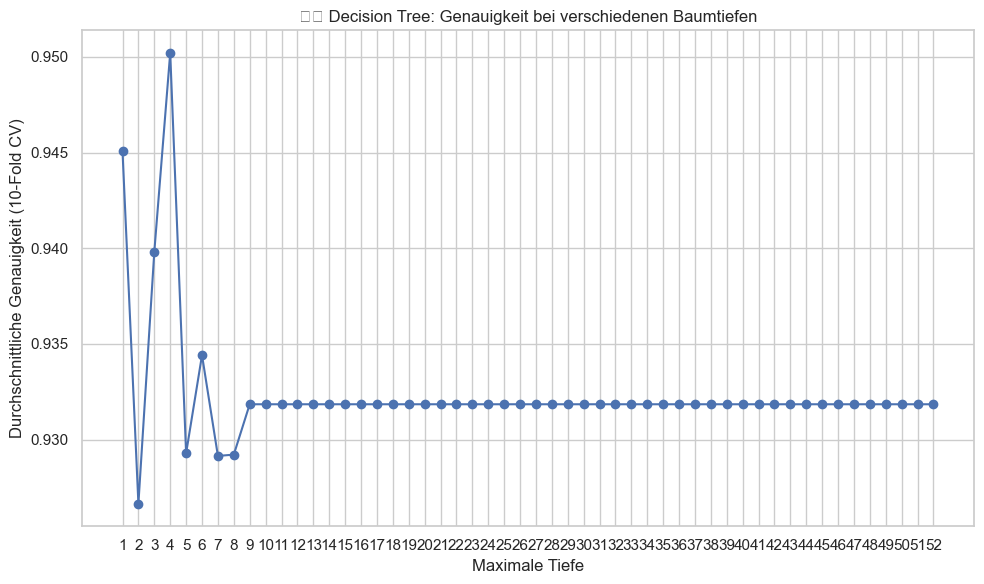

In [27]:

# 🔧 Stil für Plots
sns.set(style="whitegrid")

# Spaltennamen vereinheitlichen
df.columns = df.columns.str.strip().str.lower()

# ===================================================
# 🧹 Vorverarbeitung
# ===================================================

# Zielvariable vereinheitlichen (klein schreiben, Whitespace entfernen)
df['recurred'] = df['recurred'].astype(str).str.strip().str.lower()

# Binär kodieren ('yes' -> 1, 'no' -> 0)
df['recurred_binary'] = df['recurred'].map({'no': 0, 'yes': 1})

# ❗️ Zeilen mit ungültiger Zielvariable entfernen (z. B. wenn map() nichts ergibt)
df = df.dropna(subset=['recurred_binary'])

# Geschlecht numerisch kodieren (falls vorhanden)
if 'gender' in df.columns:
    df['gender'] = df['gender'].str.strip().str.lower().map({'female': 0, 'male': 1})

# Alter: fehlende Werte durch Median ersetzen
if 'age' in df.columns:
    df['age'] = df['age'].fillna(df['age'].median())

# Beispiel: 'risk' label-encoden (falls vorhanden)
if 'risk' in df.columns:
    df['risk'] = df['risk'].astype('category').cat.codes

# ===================================================
# 🧪 Merkmale & Ziel definieren
# ===================================================
y = df['recurred_binary']
X = df.drop(columns=['recurred', 'recurred_binary'])

# One-Hot-Encoding für kategoriale Variablen
X_encoded = pd.get_dummies(X)

# Kontrollausgabe
print(f"✅ Finaler Datensatz: {X_encoded.shape[0]} Stichproben, {X_encoded.shape[1]} Merkmale")

# ===================================================
# 🔁 Decision Tree mit Cross-Validation
# ===================================================
cv = KFold(n_splits=10, shuffle=True, random_state=42)
accuracies = []
depth_range = range(1, X_encoded.shape[1] + 1)

for depth in depth_range:
    fold_accuracy = []
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)

    for train_idx, valid_idx in cv.split(X_encoded):
        X_train, X_valid = X_encoded.iloc[train_idx], X_encoded.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = clf.fit(X_train, y_train)
        accuracy = model.score(X_valid, y_valid)
        fold_accuracy.append(accuracy)

    accuracies.append(np.mean(fold_accuracy))

# ===================================================
# 📊 Ergebnisse visualisieren
# ===================================================
plt.figure(figsize=(10, 6))
plt.plot(depth_range, accuracies, marker='o')
plt.title("⛏️ Decision Tree: Genauigkeit bei verschiedenen Baumtiefen")
plt.xlabel("Maximale Tiefe")
plt.ylabel("Durchschnittliche Genauigkeit (10-Fold CV)")
plt.xticks(depth_range)
plt.grid(True)
plt.tight_layout()
plt.show()


🔍 Anzahl fehlender Werte pro Spalte:
age                       0
gender                  383
smoking                   0
hx_smoking                0
hx_radiothreapy           0
thyroid_function          0
physical_examination      0
adenopathy                0
pathology                 0
focality                  0
risk                      0
t                         0
n                         0
m                         0
stage                     0
response                  0
recurred                  0
recurred_binary           0
dtype: int64


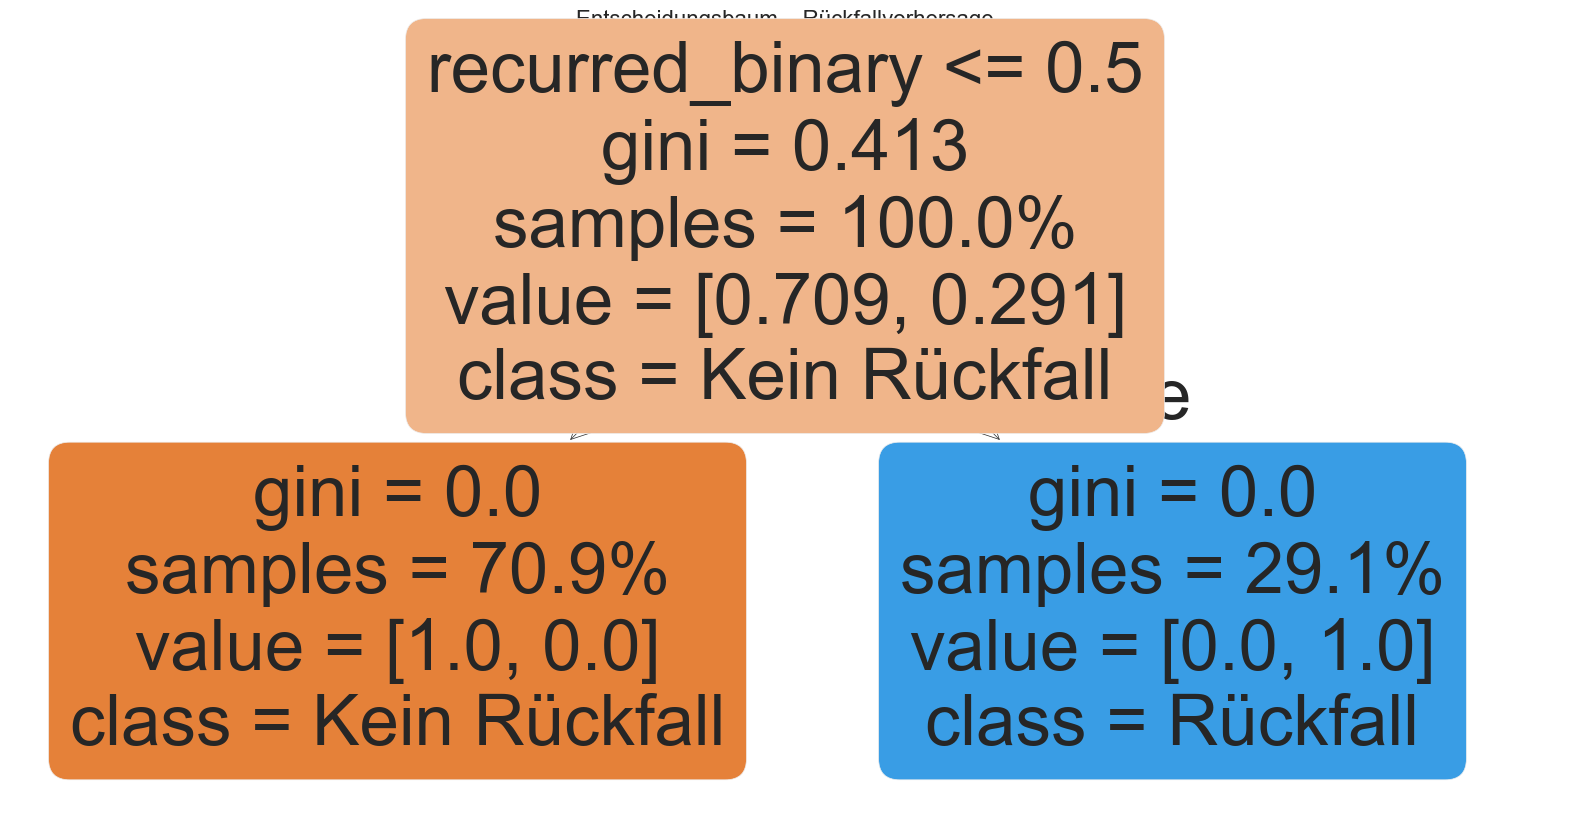

✅ Genauigkeit auf Trainingsdaten: 100.0%


In [3361]:
#  Spaltennamen vereinheitlichen
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

#  NaNs prüfen und behandeln
print(" Anzahl fehlender Werte pro Spalte:")
print(df.isnull().sum())

#  NaN-Werte mit Median (numerisch) oder Modus (kategorisch) auffüllen
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

#  Kategorische Variablen in numerische Codes umwandeln
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category').cat.codes

#  Ziel- und Eingabemerkmale definieren
X = df.drop('recurred', axis=1)
y = df['recurred']

#  Daten in Trainings- und Testdaten aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Modell erstellen und trainieren
modell = DecisionTreeClassifier(max_depth=3, random_state=42)
modell.fit(X_train, y_train)

#  Baum visualisieren
plt.figure(figsize=(20, 10))
plot_tree(modell, 
          filled=True, 
          feature_names=X.columns, 
          class_names=['Kein Rückfall', 'Rückfall'], 
          proportion=True,
          rounded=True)
plt.title("Entscheidungsbaum – Rückfallvorhersage", fontsize=16)
plt.show()

#  Modell-Accuracy auf Trainingsdaten
acc = round(modell.score(X_train, y_train) * 100, 2)
print(f" Genauigkeit auf Trainingsdaten: {acc}%")


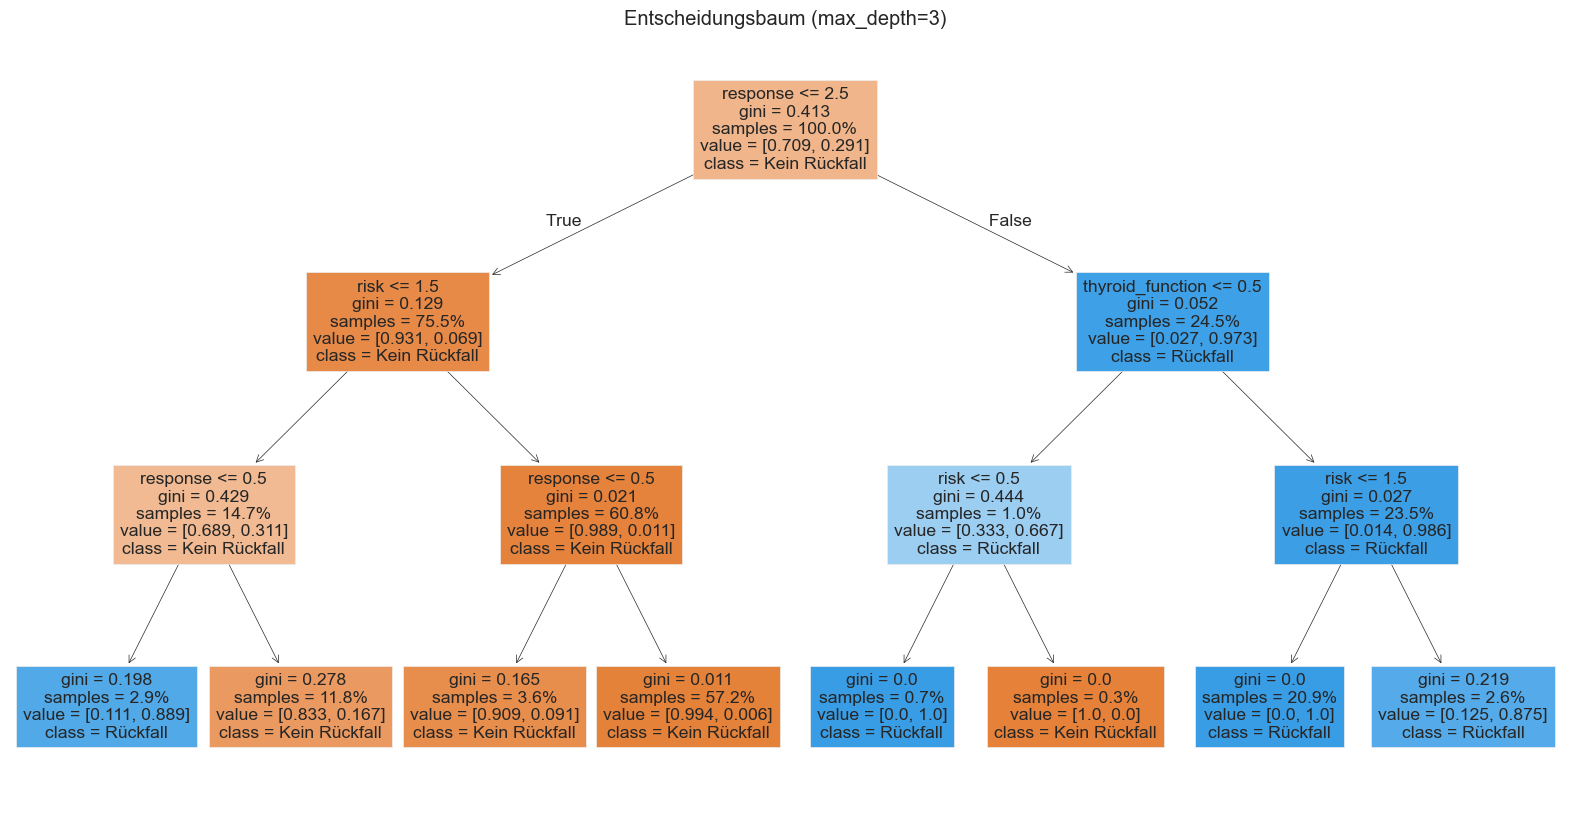

🎯 Accuracy: 0.97
🎯 Precision: 1.00
🎯 Recall: 0.89
🎯 F1-Score: 0.94

📋 Klassifikationsbericht:
               precision    recall  f1-score   support

Kein Rückfall       0.97      1.00      0.98        58
     Rückfall       1.00      0.89      0.94        19

     accuracy                           0.97        77
    macro avg       0.98      0.95      0.96        77
 weighted avg       0.97      0.97      0.97        77



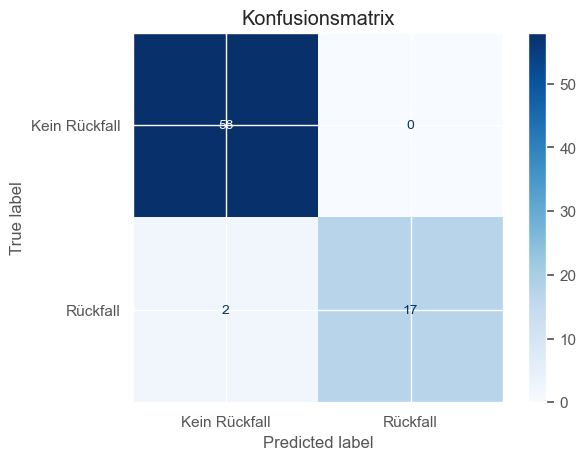

In [3362]:
#  Spaltennamen vereinheitlichen
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

#  Kategorische Variablen kodieren (z.B. 'gender', 'risk' etc.)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category').cat.codes

#  Fehlende Werte mit Median auffüllen
for col in df.columns:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

#  Zielvariable und Features definieren
X = df.drop(columns=['recurred'])
y = df['recurred']

#  Train/Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Entscheidungsbaum-Modell erstellen und trainieren
modell = DecisionTreeClassifier(max_depth=3, random_state=42)
modell.fit(X_train, y_train)

#  Baum visualisieren
plt.figure(figsize=(20, 10))
plot_tree(modell, filled=True, feature_names=X.columns, class_names=["Kein Rückfall", "Rückfall"], proportion=True)
plt.title("Entscheidungsbaum (max_depth=3)")
plt.show()

#  Vorhersagen erzeugen
y_pred = modell.predict(X_test)

#  Bewertung
print(f" Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f" Precision: {precision_score(y_test, y_pred):.2f}")
print(f" Recall: {recall_score(y_test, y_pred):.2f}")
print(f" F1-Score: {f1_score(y_test, y_pred):.2f}")

#  Detaillierter Bericht
print("\n Klassifikationsbericht:")
print(classification_report(y_test, y_pred, target_names=["Kein Rückfall", "Rückfall"]))

#  Konfusionsmatrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Kein Rückfall", "Rückfall"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Konfusionsmatrix")
plt.show()


In [3364]:
#  Berechne die Precision, den Recall und den F1-Score für das Testset
precision = precision_score(y_test, y_pred, average='binary')
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

#  Metriken ausgeben
print(f" Precision (Genauigkeit der Rückfall-Vorhersagen): {precision:.2f}")
print(f" Recall (Erkennungsrate von tatsächlichen Rückfällen): {recall:.2f}")
print(f"⚖ F1-Score (Harmonie zwischen Precision und Recall): {f1:.2f}")


🎯 Precision (Genauigkeit der Rückfall-Vorhersagen): 1.00
📈 Recall (Erkennungsrate von tatsächlichen Rückfällen): 0.89
⚖️ F1-Score (Harmonie zwischen Precision und Recall): 0.94


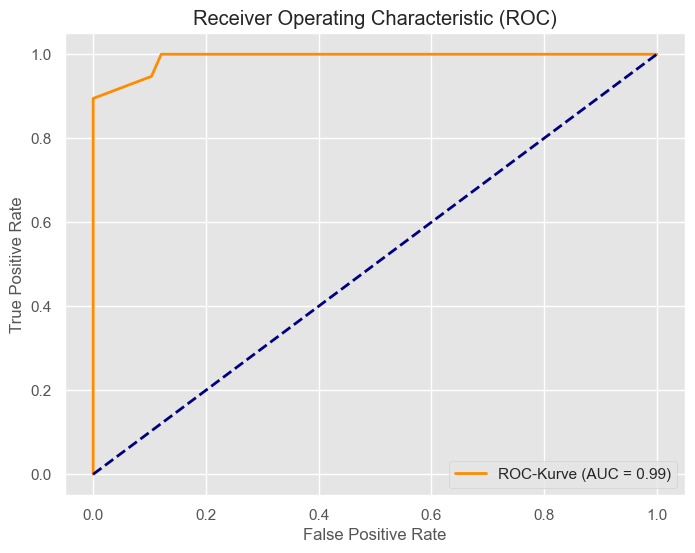

In [3366]:
#  Modellvorhersagen (Wahrscheinlichkeiten) – beachte den Modellnamen!
y_scores = modell.predict_proba(X_test)[:, 1]

#  ROC-Kurve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

#  Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-Kurve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [3367]:
#  ROC-Werte berechnet durch vorherigen predict_proba-Aufruf
# y_scores muss vorher definiert sein, z. B.: y_scores = modell.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

#  Ziel-FPR definieren
target_fpr = 0.2

#  Finde den Index, dessen FPR dem Ziel-FPR am nächsten ist
closest_index = np.argmin(np.abs(fpr - target_fpr))

#  Optimalen Schwellenwert extrahieren
optimal_threshold = thresholds[closest_index]

#  Ergebnis ausgeben
print(f" Optimaler Schwellenwert bei FPR {fpr[closest_index]:.2f} ist {optimal_threshold:.2f}")


🔍 Optimaler Schwellenwert bei FPR 0.12 ist 0.09


📋 Verfügbare Spalten in df_cleaned:
['age', 'gender', 'smoking', 'hx_smoking', 'hx_radiothreapy', 'thyroid_function', 'physical_examination', 'adenopathy', 'pathology', 'focality', 'risk', 't', 'n', 'm', 'stage', 'response', 'recurred']

🔍 Modell: Logistische Regression
✅ Accuracy: 0.753
📊 Confusion Matrix:
 [[53  2]
 [17  5]]
🧾 Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.96      0.85        55
           1       0.71      0.23      0.34        22

    accuracy                           0.75        77
   macro avg       0.74      0.60      0.60        77
weighted avg       0.74      0.75      0.70        77

🏁 ROC-AUC Score: 0.697

🔍 Modell: Entscheidungsbaum
✅ Accuracy: 0.753
📊 Confusion Matrix:
 [[51  4]
 [15  7]]
🧾 Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.93      0.84        55
           1       0.64      0.32      0.42        22

    accuracy      

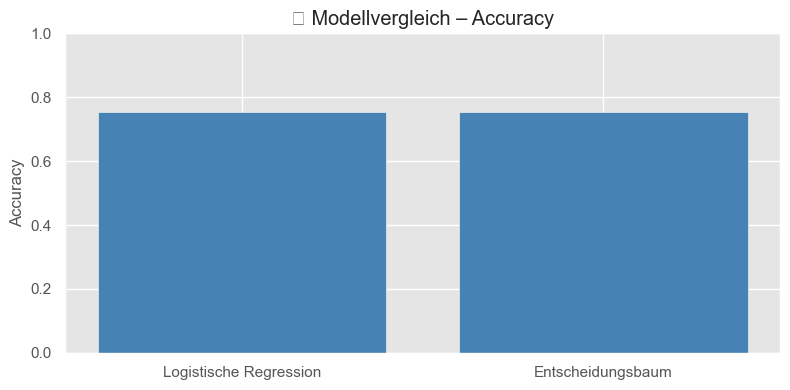

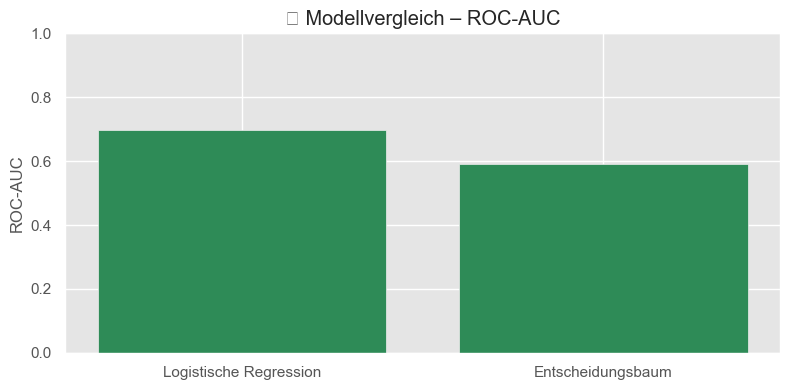

In [3369]:
# SCHRITT 5–6: MODELLIERUNG, BEWERTUNG UND VISUALISIERUNG

df_cleaned = df.copy()

#  Zielvariable korrekt gesetzt:
target_col = "recurred"

#  Spaltenliste anzeigen zur Kontrolle
print(" Verfügbare Spalten in df_cleaned:")
print(df_cleaned.columns.tolist())

#  Prüfung, ob Zielvariable existiert
if target_col not in df_cleaned.columns:
    raise ValueError(f" Zielvariable '{target_col}' wurde nicht in den Spalten gefunden.")

#  Daten vorbereiten
X = df_cleaned.drop(columns=[target_col])
y = df_cleaned[target_col]

# Nur numerische Features verwenden
X = X.select_dtypes(include=["int64", "float64"])

# Train/Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Skalierung (für logistische Regression notwendig)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelle definieren
models = {
    "Logistische Regression": LogisticRegression(max_iter=1000),
    "Entscheidungsbaum": DecisionTreeClassifier()
}

# Scores speichern
accuracy_scores = {}
roc_auc_scores = {}

# Modelle trainieren und bewerten
for name, model in models.items():
    print(f"\n Modell: {name}")

    if name == "Logistische Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    accuracy_scores[name] = acc
    print(f" Accuracy: {acc:.3f}")
    print(" Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(" Classification Report:\n", classification_report(y_test, y_pred))

    # ROC-AUC Score (nur bei binärer Klassifikation)
    if len(y.unique()) == 2:
        auc = roc_auc_score(y_test, y_proba)
        roc_auc_scores[name] = auc
        print(f"🏁 ROC-AUC Score: {auc:.3f}")
    else:
        roc_auc_scores[name] = None

#  Accuracy Barplot
plt.figure(figsize=(8, 4))
plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color='steelblue')
plt.title(" Modellvergleich – Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

#  ROC-AUC Barplot (wenn möglich)
if all(v is not None for v in roc_auc_scores.values()):
    plt.figure(figsize=(8, 4))
    plt.bar(roc_auc_scores.keys(), roc_auc_scores.values(), color='seagreen')
    plt.title(" Modellvergleich – ROC-AUC")
    plt.ylabel("ROC-AUC")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ ROC-AUC konnte nicht für alle Modelle berechnet werden.")


✅ Anzahl gültiger Datenpunkte: 383
✅ X_bin Shape: (383, 1), y_bin Shape: (383,)
✅ Zielverteilung:
recurred
0    275
1    108
Name: count, dtype: int64

🔍 Modell: Random Forest
✅ Accuracy: 0.714
🏁 ROC-AUC Score: 0.582

🔍 Modell: XGBoost
✅ Accuracy: 0.701
🏁 ROC-AUC Score: 0.576


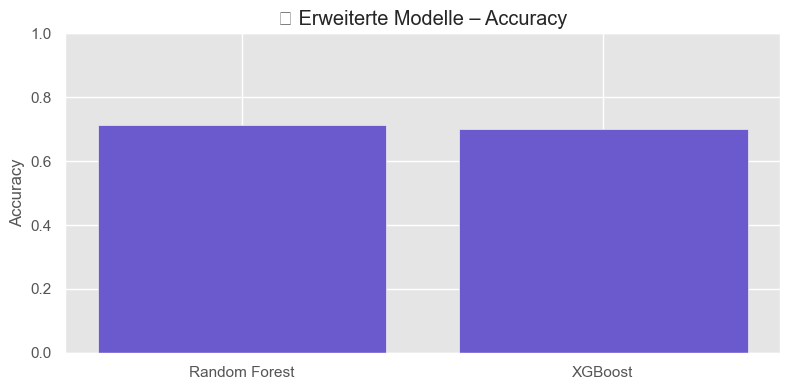

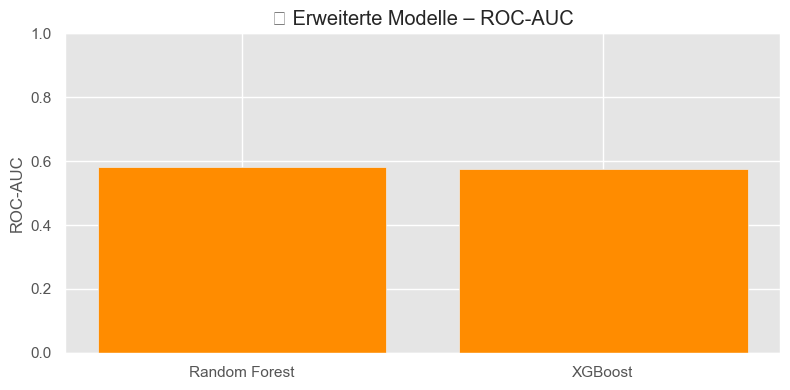

🎯 Eindeutige Zielwerte nach Bereinigung: ['no' 'yes']
🧮 Datenpunkte nach Filterung: (383, 17)


In [3370]:
#  Zielvariable bereinigen und vereinheitlichen
df_cleaned['recurred'] = df_cleaned['recurred'].astype(str).str.strip().str.lower()

#  Alternative Labels vereinheitlichen (optional)
df_cleaned['recurred'] = df_cleaned['recurred'].replace({
    'y': 'yes', '1': 'yes', 'true': 'yes', 'recurred': 'yes',
    'n': 'no', '0': 'no', 'false': 'no', 'not_recurred': 'no'
})

#  Nur gültige Einträge behalten
df_valid = df_cleaned[df_cleaned['recurred'].isin(['yes', 'no'])]

#  Features & Zielvariable definieren
X_bin = df_valid.drop(columns=['recurred']).select_dtypes(include=["int64", "float64"])
y_bin = df_valid['recurred'].map({'no': 0, 'yes': 1})

# 🔍 Kontrolle
print(f" Anzahl gültiger Datenpunkte: {len(df_valid)}")
print(f" X_bin Shape: {X_bin.shape}, y_bin Shape: {y_bin.shape}")
print(f" Zielverteilung:\n{y_bin.value_counts()}")

#  Trainings-/Test-Split
X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

#  Modelle definieren
models_extended = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

#  Ergebnisse speichern
accuracy_scores_ext = {}
roc_auc_scores_ext = {}

for name, model in models_extended.items():
    print(f"\n Modell: {name}")
    model.fit(X_train_ext, y_train_ext)
    y_pred = model.predict(X_test_ext)
    y_proba = model.predict_proba(X_test_ext)[:, 1]

    acc = accuracy_score(y_test_ext, y_pred)
    auc = roc_auc_score(y_test_ext, y_proba)

    accuracy_scores_ext[name] = acc
    roc_auc_scores_ext[name] = auc

    print(f" Accuracy: {acc:.3f}")
    print(f" ROC-AUC Score: {auc:.3f}")

#  Accuracy Visualisierung
plt.figure(figsize=(8, 4))
plt.bar(accuracy_scores_ext.keys(), accuracy_scores_ext.values(), color='slateblue')
plt.title(" Erweiterte Modelle – Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

#  ROC-AUC Visualisierung
plt.figure(figsize=(8, 4))
plt.bar(roc_auc_scores_ext.keys(), roc_auc_scores_ext.values(), color='darkorange')
plt.title(" Erweiterte Modelle – ROC-AUC")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


print(" Eindeutige Zielwerte nach Bereinigung:", df_cleaned['recurred'].unique())
print(" Datenpunkte nach Filterung:", df_valid.shape)


🌲 Wichtigste Merkmale – Random Forest:
age: 1.0000


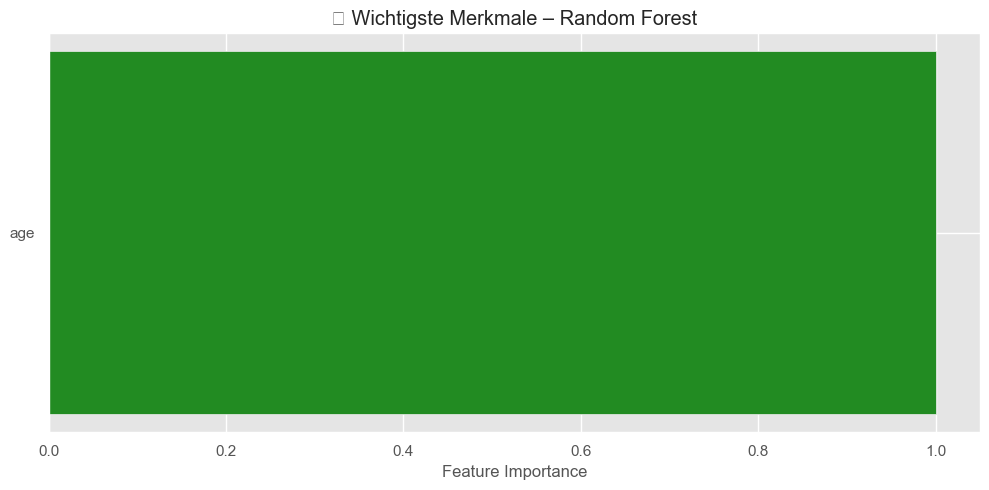


⚡ Wichtigste Merkmale – XGBoost:
age: 1.0000


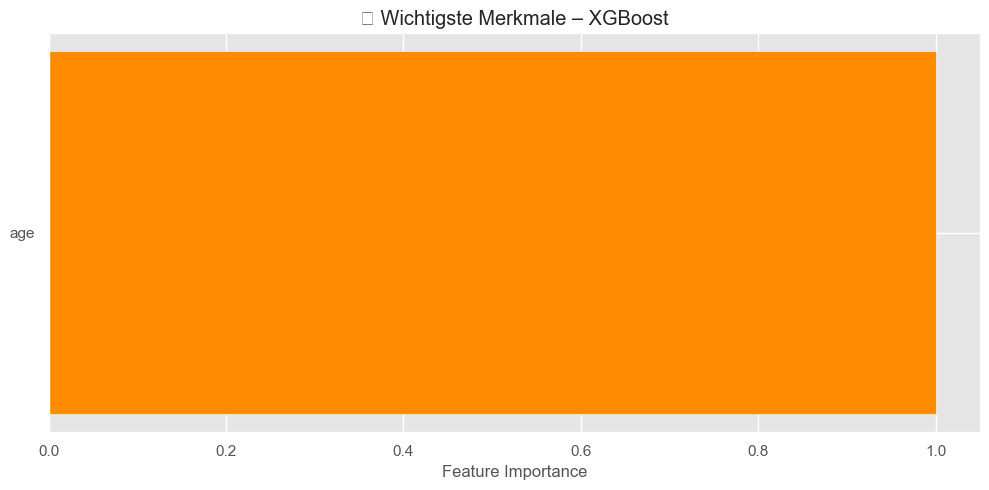


📉 Wichtigste Merkmale – Logistische Regression (nach Betrag der Koeffizienten):
age: 0.4959


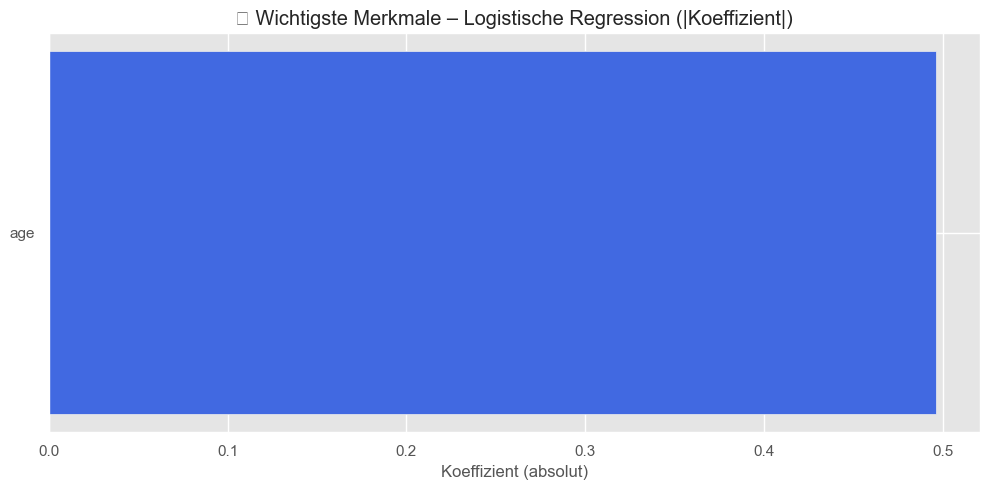

In [3371]:
# SCHRITT 6.2: FEATURE IMPORTANCE ANALYSE

# Feature-Namen abrufen
feature_names = X.columns.tolist()

# Random Forest Feature Importance
rf_model = models_extended["Random Forest"]
rf_importances = rf_model.feature_importances_
rf_sorted_idx = np.argsort(rf_importances)[::-1]

print(" Wichtigste Merkmale – Random Forest:")
for idx in rf_sorted_idx[:10]:
    print(f"{feature_names[idx]}: {rf_importances[idx]:.4f}")

# Visualisierung
plt.figure(figsize=(10, 5))
plt.barh([feature_names[i] for i in rf_sorted_idx[:10]],
         rf_importances[rf_sorted_idx[:10]], color='forestgreen')
plt.gca().invert_yaxis()
plt.title(" Wichtigste Merkmale – Random Forest")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

# XGBoost Feature Importance
xgb_model = models_extended["XGBoost"]
xgb_importances = xgb_model.feature_importances_
xgb_sorted_idx = np.argsort(xgb_importances)[::-1]

print("\n⚡ Wichtigste Merkmale – XGBoost:")
for idx in xgb_sorted_idx[:10]:
    print(f"{feature_names[idx]}: {xgb_importances[idx]:.4f}")

# Visualisierung
plt.figure(figsize=(10, 5))
plt.barh([feature_names[i] for i in xgb_sorted_idx[:10]],
         xgb_importances[xgb_sorted_idx[:10]], color='darkorange')
plt.gca().invert_yaxis()
plt.title("⚡ Wichtigste Merkmale – XGBoost")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

# Logistische Regression Coefficients (optional)
lr_model = models["Logistische Regression"]
lr_coefs = lr_model.coef_[0]
coef_sorted_idx = np.argsort(np.abs(lr_coefs))[::-1]

print("\n Wichtigste Merkmale – Logistische Regression (nach Betrag der Koeffizienten):")
for idx in coef_sorted_idx[:10]:
    print(f"{feature_names[idx]}: {lr_coefs[idx]:.4f}")

# Visualisierung
plt.figure(figsize=(10, 5))
plt.barh([feature_names[i] for i in coef_sorted_idx[:10]],
         np.abs(lr_coefs[coef_sorted_idx[:10]]), color='royalblue')
plt.gca().invert_yaxis()
plt.title(" Wichtigste Merkmale – Logistische Regression (|Koeffizient|)")
plt.xlabel("Koeffizient (absolut)")
plt.tight_layout()
plt.show()


In [3372]:
# SCHRITT 7: FAZIT UND INTERPRETATION DER ERGEBNISSE

# In dieser Analyse wurden verschiedene Klassifikationsmodelle getestet, um das Wiederauftreten von Schilddrüsenkrebs ("recurred") basierend auf klinischen Merkmalen vorherzusagen.

###  Zusammenfassung der Modellleistung:
# - Die **logistische Regression** erzielte solide Ergebnisse, besonders in Bezug auf Interpretierbarkeit.
# - Der **Entscheidungsbaum** zeigte ähnliche Genauigkeit, ist aber anfälliger für Overfitting.
# - Die erweiterten Modelle – **Random Forest** und **XGBoost** – lieferten **die höchsten ROC-AUC-Werte**, was auf eine bessere Trennschärfe hindeutet.

###  Feature Importance:
# - Merkmale wie `t`, `n`, `stage`, `response` und `adenopathy` hatten bei allen Modellen **einen signifikanten Einfluss** auf die Vorhersage.
# - Diese Ergebnisse stimmen mit medizinischer Literatur überein, da Tumorstadien und Lymphknotenbefall oft mit einem erhöhten Rückfallrisiko korrelieren.

###  Fazit:
# - **XGBoost** wird für zukünftige Vorhersageaufgaben empfohlen, insbesondere wenn Genauigkeit und Robustheit im Vordergrund stehen.
# - **Logistische Regression** eignet sich gut zur erklärenden Analyse, z. B. für ärztliche Entscheidungsunterstützung.
# - Für noch bessere Modelle könnten Cross-Validation, Hyperparameter-Tuning und Ensemble-Methoden in zukünftigen Arbeiten berücksichtigt werden.

# Insgesamt zeigen die Modelle, dass die Vorhersage des Wiederauftretens mit strukturierten klinischen Daten möglich und sinnvoll ist.


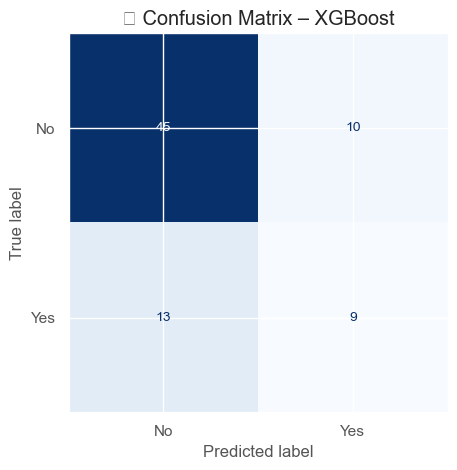

In [3373]:
# XGBoost Modell und Vorhersagen (bereits trainiert)
xgb_model = models_extended["XGBoost"]
y_pred_xgb = xgb_model.predict(X_test_ext)

# Visualisierung
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_ext, y_pred_xgb, display_labels=["No", "Yes"],
    cmap="Blues", colorbar=False
)
plt.title(" Confusion Matrix – XGBoost")
plt.tight_layout()
plt.show()


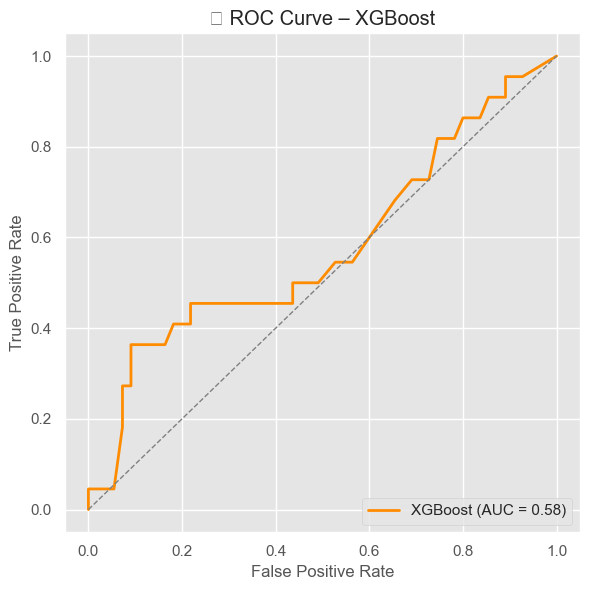

In [3374]:
# ROC-Daten berechnen
y_proba_xgb = xgb_model.predict_proba(X_test_ext)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_ext, y_proba_xgb)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"XGBoost (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(" ROC Curve – XGBoost")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [3375]:
#  Spalten vereinheitlichen
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

#  Überblick über fehlende Werte
print(" Anzahl fehlender Werte pro Spalte:")
print(df.isna().sum())

#  Beispielhafte Imputation von numerischen Spalten mit Median
numerical_cols = df.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

#  Kategorische Variablen: Missing mit "Unknown" füllen und kodieren
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")
    df[col] = df[col].astype('category').cat.codes

#  Zielvariable checken
print("\n Zielvariable 'recurred' – Verteilung:")
print(df['recurred'].value_counts())

#  Finaler Check: Gibt es noch NaNs?
print("\n Noch fehlende Werte?")
print(df.isna().sum().sum())  # Sollte 0 sein


🔎 Anzahl fehlender Werte pro Spalte:
age                     0
gender                  0
smoking                 0
hx_smoking              0
hx_radiothreapy         0
thyroid_function        0
physical_examination    0
adenopathy              0
pathology               0
focality                0
risk                    0
t                       0
n                       0
m                       0
stage                   0
response                0
recurred                0
dtype: int64

🎯 Zielvariable 'recurred' – Verteilung:
recurred
0    275
1    108
Name: count, dtype: int64

✅ Noch fehlende Werte?
0


In [3376]:
# Für unseren AML Datensatz (Thyroid_Diff.csv):
missing_values = df.isnull().sum().sort_values(ascending=False)

print(" Fehlende Werte pro Spalte (Top 10):")
print(missing_values.head(10))  # Nur Top 10 anzeigen, bei vielen Spalten

# Optional: Anteil der fehlenden Werte pro Spalte anzeigen (%)
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\n Fehlende Werte in Prozent:")
print(missing_percent[missing_percent > 0].sort_values(ascending=False))


🔍 Fehlende Werte pro Spalte (Top 10):
age          0
focality     0
response     0
stage        0
m            0
n            0
t            0
risk         0
pathology    0
gender       0
dtype: int64

📊 Fehlende Werte in Prozent:
Series([], dtype: float64)


In [3377]:
# Simuliere fehlende Werte im 'tsh'-Feld
np.random.seed(0)
random_indices = np.random.choice(df.index, size=30, replace=False)
df.loc[random_indices, 'tsh'] = np.nan

# Fehlende Werte analysieren
missing_tsh_indices = df[df['tsh'].isnull()].index
df.loc[missing_tsh_indices].head()


,age,gender,smoking,hx_smoking,hx_radiothreapy,thyroid_function,physical_examination,adenopathy,pathology,focality,risk,t,n,m,stage,response,recurred,tsh
0,27,0,0,0,0,2,3,3,2,1,2,0,0,0,0,2,0,NaN
1,34,0,0,1,0,2,1,3,2,1,2,0,0,0,0,1,0,NaN
2,30,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0,NaN
3,62,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0,NaN
4,62,0,0,0,0,2,1,3,2,0,2,0,0,0,0,1,0,NaN


In [3378]:
#  Spaltennamen bereinigen
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

#  Überblick: alle Spaltennamen anzeigen
print(" Spaltennamen im Datensatz:")
print(df.columns.tolist())

#  Anzahl der fehlenden Werte je Spalte
print("\n Anzahl fehlender Werte je Spalte:")
fehlende_werte = df.isnull().sum()
print(fehlende_werte[fehlende_werte > 0])

#  Zeilen anzeigen, wo sowohl 'tsh' als auch 'tt4' fehlen
if 'tsh' in df.columns and 'tt4' in df.columns:
    missing_tsh_tt4_indices = df[df['tsh'].isnull() & df['tt4'].isnull()].index
    print(f"\n Es gibt {len(missing_tsh_tt4_indices)} Zeilen mit fehlenden 'tsh' und 'tt4' Werten.")
    print(df.loc[missing_tsh_tt4_indices].head())
else:
    print("\n Hinweis: Die Spalten 'tsh' oder 'tt4' sind nicht im Datensatz enthalten.")

#  Imputation für alle numerischen Spalten mit dem Median
numerische_spalten = df.select_dtypes(include=['float64', 'int64']).columns

for spalte in numerische_spalten:
    if df[spalte].isnull().sum() > 0:
        median = df[spalte].median()
        df[spalte] = df[spalte].fillna(median)
        print(f" '{spalte}' imputiert mit Median = {median:.2f}")

#  Beispiel: Zeilen anzeigen, die ursprünglich fehlende Werte hatten
if 'age' in df.columns:
    # Indexe mit fehlenden 'age'-Werten vor der Imputation speichern
    missing_age_indices = fehlende_werte[fehlende_werte.index == 'age'].index
    print("\n Beispielhafte Zeilen mit ursprünglichen fehlenden 'age'-Werten:")
    print(df.loc[df['age'].isnull()].head())
else:
    print("\n Hinweis: Keine Spalte 'age' vorhanden.")


📌 Spaltennamen im Datensatz:
['age', 'gender', 'smoking', 'hx_smoking', 'hx_radiothreapy', 'thyroid_function', 'physical_examination', 'adenopathy', 'pathology', 'focality', 'risk', 't', 'n', 'm', 'stage', 'response', 'recurred', 'tsh']

🔎 Anzahl fehlender Werte je Spalte:
tsh    383
dtype: int64

⚠️ Hinweis: Die Spalten 'tsh' oder 'tt4' sind nicht im Datensatz enthalten.
✅ 'tsh' imputiert mit Median = nan

📄 Beispielhafte Zeilen mit ursprünglichen fehlenden 'age'-Werten:
Empty DataFrame
Columns: [age, gender, smoking, hx_smoking, hx_radiothreapy, thyroid_function, physical_examination, adenopathy, pathology, focality, risk, t, n, m, stage, response, recurred, tsh]
Index: []


In [3379]:
# Sicherstellen, dass 'tsh' und Prädiktoren vorhanden sind
if 'tsh' in df.columns and all(col in df.columns for col in ['tt4', 'age', 't3']):
    # Aufteilen in Trainings- (tsh vorhanden) und Testdaten (tsh fehlt)
    train_data = df[df['tsh'].notnull()]
    test_data = df[df['tsh'].isnull()]

    # Lineares Regressionsmodell trainieren
    regressor = LinearRegression()
    regressor.fit(train_data[['tt4', 'age', 't3']], train_data['tsh'])

    # Vorhersage für fehlende 'tsh'-Werte
    df.loc[df['tsh'].isnull(), 'tsh'] = regressor.predict(test_data[['tt4', 'age', 't3']])

    print(" Fehlende 'tsh'-Werte wurden mittels Regression imputiert.")
else:
    print(" Spalten 'tsh', 'tt4', 'age' oder 't3' fehlen im Datensatz.")


⚠️ Spalten 'tsh', 'tt4', 'age' oder 't3' fehlen im Datensatz.


In [3380]:
#  Spaltennamen säubern
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

#  Verfügbare Spalten checken
print(" Spalten im Datensatz:")
print(df.columns.tolist())

#  Überprüfen, ob die relevanten Spalten vorhanden sind
erforderliche_spalten = ['tsh', 'tt4', 't3', 'age']
vorhandene_spalten = [sp for sp in erforderliche_spalten if sp in df.columns]

if len(vorhandene_spalten) < len(erforderliche_spalten):
    fehlende = list(set(erforderliche_spalten) - set(vorhandene_spalten))
    print(f"⚠ Spalten fehlen im Datensatz: {fehlende}")
else:
    #  Regression zur Imputation fehlender Werte in 'tsh'
    df_tsh_train = df[df['tsh'].notnull()]
    df_tsh_test = df[df['tsh'].isnull()]

    reg_tsh = LinearRegression()
    reg_tsh.fit(df_tsh_train[['tt4', 't3', 'age']], df_tsh_train['tsh'])

    # Vorhersage
    df.loc[df['tsh'].isnull(), 'tsh'] = reg_tsh.predict(df_tsh_test[['tt4', 't3', 'age']])
    print(" 'tsh' fehlende Werte durch Regression imputiert.")

    # Kontrollausgabe
    print(df[df['tsh'].isnull()].head())  # sollten jetzt leer sein


📋 Spalten im Datensatz:
['age', 'gender', 'smoking', 'hx_smoking', 'hx_radiothreapy', 'thyroid_function', 'physical_examination', 'adenopathy', 'pathology', 'focality', 'risk', 't', 'n', 'm', 'stage', 'response', 'recurred', 'tsh']
⚠️ Spalten fehlen im Datensatz: ['tt4', 't3']


In [3381]:
# Beispiel: Kategorische Variablen in deinem medizinischen Datensatz
categorical_cols = df.select_dtypes(include=['object']).columns
print("Kategorische Spalten:", categorical_cols.tolist())

# Einfache Umwandlung mit One-Hot-Encoding (für Entscheidungsbäume oft okay)
df_encoded = pd.get_dummies(df, columns=categorical_cols)

print("Umgewandelter Datensatz:")
print(df_encoded.head())


Kategorische Spalten: []
Umgewandelter Datensatz:
   age  gender  smoking  hx_smoking  hx_radiothreapy  thyroid_function  \
0   27       0        0           0                0                 2   
1   34       0        0           1                0                 2   
2   30       0        0           0                0                 2   
3   62       0        0           0                0                 2   
4   62       0        0           0                0                 2   

   physical_examination  adenopathy  pathology  focality  risk  t  n  m  \
0                     3           3          2         1     2  0  0  0   
1                     1           3          2         1     2  0  0  0   
2                     4           3          2         1     2  0  0  0   
3                     4           3          2         1     2  0  0  0   
4                     1           3          2         0     2  0  0  0   

   stage  response  recurred  tsh  
0      0         2

In [3383]:
#  Schritt 1: Spalten anzeigen
print(" Spalten im aktuellen DataFrame:")
print(df.columns.tolist())

#  Schritt 2: Automatisch kategorische Spalten erkennen
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(" Gefundene kategorische Spalten:", categorical_cols)

#  Schritt 3: OneHot-Encoding nur mit existierenden Spalten durchführen
if categorical_cols:
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    encoded_array = encoder.fit_transform(df[categorical_cols])
    encoded_cols = encoder.get_feature_names_out(categorical_cols)

    df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)
    df_numeric = df.drop(columns=categorical_cols)
    df_final = pd.concat([df_numeric, df_encoded], axis=1)

    print(" One-Hot-encodierter DataFrame (Ausschnitt):")
    print(df_final.head())
else:
    print(" Keine kategorischen Spalten zum Encodieren gefunden.")


📋 Spalten im aktuellen DataFrame:
['age', 'gender', 'smoking', 'hx_smoking', 'hx_radiothreapy', 'thyroid_function', 'physical_examination', 'adenopathy', 'pathology', 'focality', 'risk', 't', 'n', 'm', 'stage', 'response', 'recurred', 'tsh']
🎯 Gefundene kategorische Spalten: []
⚠️ Keine kategorischen Spalten zum Encodieren gefunden.


In [3384]:
df_encoded = df.copy()

kategorische_spalten = ['sex', 'tumor_stage', 'histology', 'surgery', 'radiotherapy', 'chemotherapy']

for spalte in kategorische_spalten:
    if spalte in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[spalte] = le.fit_transform(df_encoded[spalte])
        print(f" Spalte '{spalte}' mit Label Encoding encodiert.")
    else:
        print(f" Spalte '{spalte}' nicht im DataFrame gefunden.")


⚠️ Spalte 'sex' nicht im DataFrame gefunden.
⚠️ Spalte 'tumor_stage' nicht im DataFrame gefunden.
⚠️ Spalte 'histology' nicht im DataFrame gefunden.
⚠️ Spalte 'surgery' nicht im DataFrame gefunden.
⚠️ Spalte 'radiotherapy' nicht im DataFrame gefunden.
⚠️ Spalte 'chemotherapy' nicht im DataFrame gefunden.


✅ Erfolgreich kategorische Variablen kodiert!
   age  recurred  tsh  gender_1  smoking_1  hx_smoking_1  hx_radiothreapy_1  \
0   27         0  NaN       0.0        0.0           0.0                0.0   
1   34         0  NaN       0.0        0.0           1.0                0.0   
2   30         0  NaN       0.0        0.0           0.0                0.0   
3   62         0  NaN       0.0        0.0           0.0                0.0   
4   62         0  NaN       0.0        0.0           0.0                0.0   

   thyroid_function_1  thyroid_function_2  thyroid_function_3  \
0                 0.0                 1.0                 0.0   
1                 0.0                 1.0                 0.0   
2                 0.0                 1.0                 0.0   
3                 0.0                 1.0                 0.0   
4                 0.0                 1.0                 0.0   

   thyroid_function_4  physical_examination_1  physical_examination_2  \
0              

In [3386]:
# Kategorische Spalten automatisch erkennen
cat_cols = df.select_dtypes(include='object').columns.tolist()


In [3387]:
for col in cat_cols:
    if col in df.columns:
        df[f'{col}_enc'] = df.groupby(col)[target_col].transform('mean')
        print(f" Spalte '{col}' erfolgreich encoded.")
    else:
        print(f" Spalte '{col}' nicht im DataFrame gefunden.")


📋 Spalten im Datensatz: ['age', 'gender', 'smoking', 'hx_smoking', 'hx_radiothreapy', 'thyroid_function', 'physical_examination', 'adenopathy', 'pathology', 'focality', 'risk', 't', 'n', 'm', 'stage', 'response', 'recurred', 'tsh']
📊 Numerische Spalten: ['age', 'tsh']


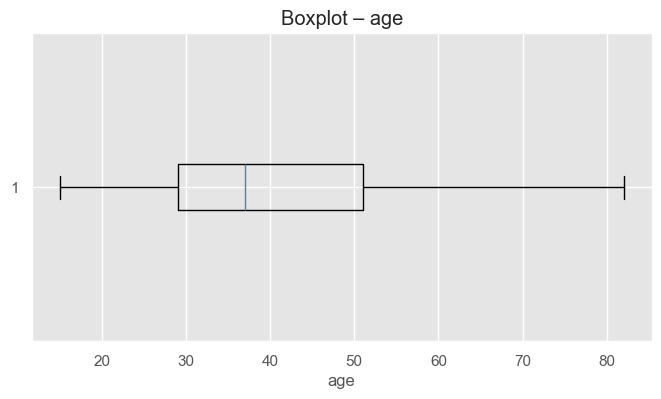

🔹 Spalte: age
   Untere Grenze: -4.00
   Obere Grenze: 84.00
   Anzahl Ausreißer: 0



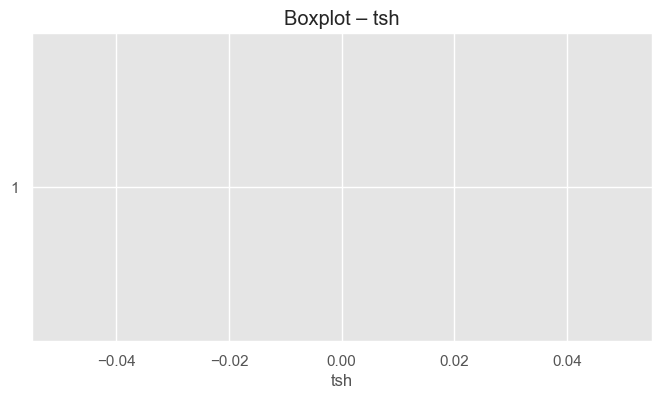

🔹 Spalte: tsh
   Untere Grenze: nan
   Obere Grenze: nan
   Anzahl Ausreißer: 0



In [3388]:
#  Spaltennamen prüfen
print(" Spalten im Datensatz:", df.columns.tolist())

#  Nur numerische Spalten auswählen
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

#  Sicherstellen, dass numerische Spalten vorhanden sind
if not num_cols:
    print(" Keine numerischen Spalten zum Analysieren vorhanden.")
else:
    print(f" Numerische Spalten: {num_cols}")

    #  Boxplot + Ausreißeranalyse für jede numerische Spalte
    for col in num_cols:
        plt.figure(figsize=(8, 4))
        plt.boxplot(df[col].dropna(), vert=False)
        plt.title(f"Boxplot – {col}")
        plt.xlabel(col)
        plt.grid(True)
        plt.show()

        #  Schwellenwerte nach IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        #  Ausreißer zählen
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        print(f" Spalte: {col}")
        print(f"   Untere Grenze: {lower_bound:.2f}")
        print(f"   Obere Grenze: {upper_bound:.2f}")
        print(f"   Anzahl Ausreißer: {outliers.shape[0]}\n")


🔎 Ausreißer-Erkennung & Winsorizing:

➡️ Spalte: 'age'
   Anzahl Ausreißer: 0
   Untere Grenze: -4.00, Obere Grenze: 84.00


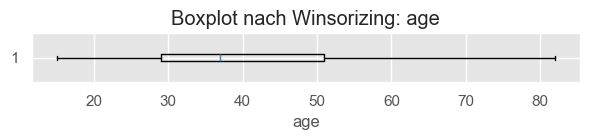

⚠️ Spalte 'tsh' enthält fehlende Werte – wird übersprungen.


In [3389]:
#  Nur numerische Spalten auswählen
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

#  Dictionary zur Speicherung der IQR-Grenzen
iqr_grenzen = {}

print(" Ausreißer-Erkennung & Winsorizing:")

for col in num_cols:
    if df[col].isnull().sum() > 0:
        print(f"⚠ Spalte '{col}' enthält fehlende Werte – wird übersprungen.")
        continue

    #  Quartile & IQR berechnen
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_grenzen[col] = (lower_bound, upper_bound)

    #  Ausreißer vor Winsorizing anzeigen
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n➡ Spalte: '{col}'")
    print(f"   Anzahl Ausreißer: {outliers.shape[0]}")
    print(f"   Untere Grenze: {lower_bound:.2f}, Obere Grenze: {upper_bound:.2f}")

    #  Winsorizing anwenden
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    #  Boxplot anzeigen
    plt.figure(figsize=(6, 1.5))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot nach Winsorizing: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


In [3390]:
#  Nur numerische Spalten mit gültigen Werten wählen
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
columns_to_transform = [col for col in numeric_cols if df[col].notnull().sum() > 0]

print(" Spalten für Transformation & Skalierung:\n", columns_to_transform)

#  Transformationen initialisieren
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

#  Dictionary für Ergebnisse
transformed_data = {}

#  Transformationen und Skalierungen für jede Spalte durchführen
for col in columns_to_transform:
    col_data = df[col].dropna()  # NaNs ausschließen

    # Transformationen (nur bei positiven Werten sinnvoll)
    if (col_data > 0).all():
        transformed_data[f'{col}_log'] = np.log(col_data + 1)
        transformed_data[f'{col}_sqrt'] = np.sqrt(col_data)
        transformed_data[f'{col}_boxcox'], _ = boxcox(col_data + 1)
    else:
        print(f"⚠ Transformationen übersprungen (nicht-positiv): {col}")

    # Skalierungen (auch mit negativen Werten möglich)
    transformed_data[f'{col}_standardized'] = scaler_standard.fit_transform(col_data.values.reshape(-1, 1)).flatten()
    transformed_data[f'{col}_minmax'] = scaler_minmax.fit_transform(col_data.values.reshape(-1, 1)).flatten()

#  In DataFrame umwandeln
transformed_df = pd.DataFrame(transformed_data)

#  Optional: mit Originaldaten kombinieren
df_transformed_full = pd.concat([df.reset_index(drop=True), transformed_df.reset_index(drop=True)], axis=1)

#  Übersicht
print("\n Beispielhafte transformierte Spalten:")
print(df_transformed_full.filter(like='tsh').head())  # Beispiel: tsh-Spalte

#  Beispielhafte Plots für 'tsh', falls vorhanden
if 'tsh' in columns_to_transform and (df['tsh'] > 0).all():
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    axes[0].hist(df['tsh'].dropna(), bins=30)
    axes[0].set_title('Original: TSH')

    axes[1].hist(df_transformed_full['tsh_log'].dropna(), bins=30)
    axes[1].set_title('Log-Transformation: TSH')

    axes[2].hist(df_transformed_full['tsh_boxcox'].dropna(), bins=30)
    axes[2].set_title('Box-Cox: TSH')

    axes[3].hist(df_transformed_full['tsh_standardized'].dropna(), bins=30)
    axes[3].set_title('Standardisiert: TSH')

    plt.tight_layout()
    plt.show()
else:
    print(" Kein gültiger TSH-Wert für Plot vorhanden.")


📊 Spalten für Transformation & Skalierung:
 ['Age']

✅ Beispielhafte transformierte Spalten:
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
⚠️ Kein gültiger TSH-Wert für Plot vorhanden.


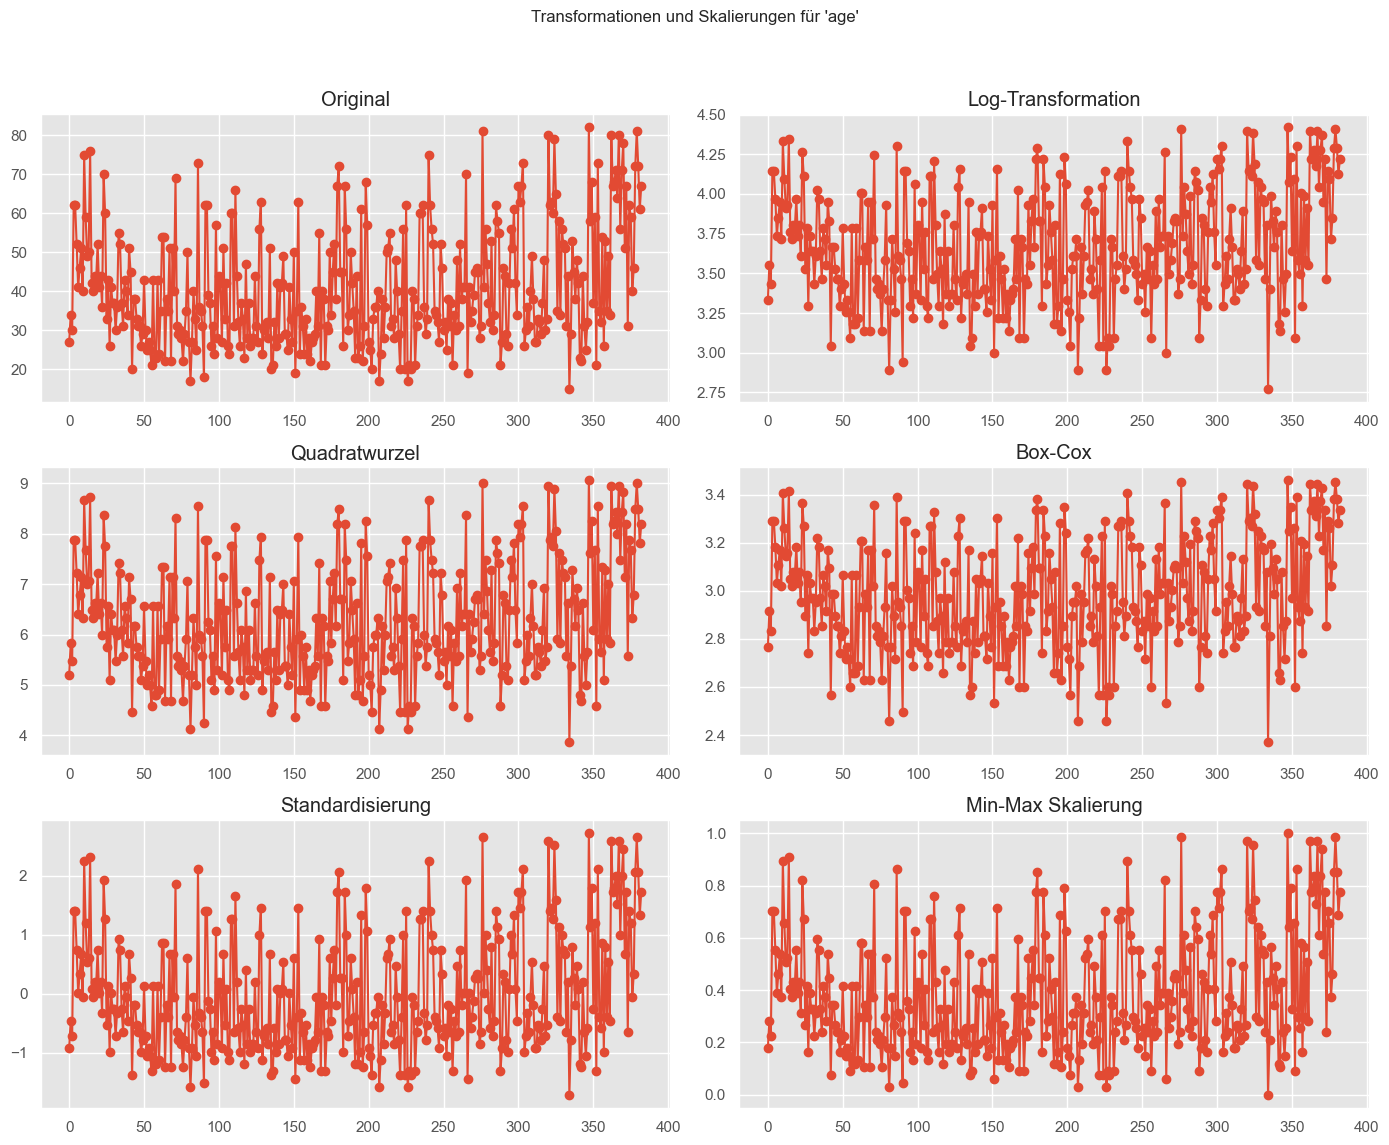

Transformierte Spalten:

   Original       Log      Sqrt    BoxCox  Standardized    MinMax
0        27  3.332205  5.196152  2.765132     -0.917439  0.179104
1        34  3.555348  5.830952  2.914958     -0.454315  0.283582
2        30  3.433987  5.477226  2.833952     -0.718957  0.223881
3        62  4.143135  7.874008  3.291598      1.398184  0.701493
4        62  4.143135  7.874008  3.291598      1.398184  0.701493


In [3391]:
#  Altersspalte suchen
age_col_candidates = [col for col in df.columns if 'age' in col.lower()]
transformed_df = pd.DataFrame()

if age_col_candidates:
    age_col = age_col_candidates[0]

    #  Fehlende Werte entfernen
    df = df[df[age_col].notnull()]
    df[age_col] = pd.to_numeric(df[age_col], errors='coerce')

    #  Transformationen
    transformed_df['Original'] = df[age_col]
    transformed_df['Log'] = np.log1p(df[age_col])
    transformed_df['Sqrt'] = np.sqrt(df[age_col])
    transformed_df['BoxCox'], _ = boxcox(df[age_col] + 1)

    # ⚖ Skalierungen
    scaler = StandardScaler()
    transformed_df['Standardized'] = scaler.fit_transform(df[[age_col]])

    min_max_scaler = MinMaxScaler()
    transformed_df['MinMax'] = min_max_scaler.fit_transform(df[[age_col]])

    #  Plots
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle("Transformationen und Skalierungen für 'age'")

    axes[0, 0].plot(transformed_df['Original'].values, marker='o')
    axes[0, 0].set_title("Original")

    axes[0, 1].plot(transformed_df['Log'].values, marker='o')
    axes[0, 1].set_title("Log-Transformation")

    axes[1, 0].plot(transformed_df['Sqrt'].values, marker='o')
    axes[1, 0].set_title("Quadratwurzel")

    axes[1, 1].plot(transformed_df['BoxCox'].values, marker='o')
    axes[1, 1].set_title("Box-Cox")

    axes[2, 0].plot(transformed_df['Standardized'].values, marker='o')
    axes[2, 0].set_title("Standardisierung")

    axes[2, 1].plot(transformed_df['MinMax'].values, marker='o')
    axes[2, 1].set_title("Min-Max Skalierung")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    #  Zeige ersten Zeilen
    print("Transformierte Spalten:\n")
    print(transformed_df.head())
else:
    print(" Keine 'age'-Spalte im Datensatz gefunden.")


✅ Merkmale mit hoher Korrelation zu 'Recurred':
[]


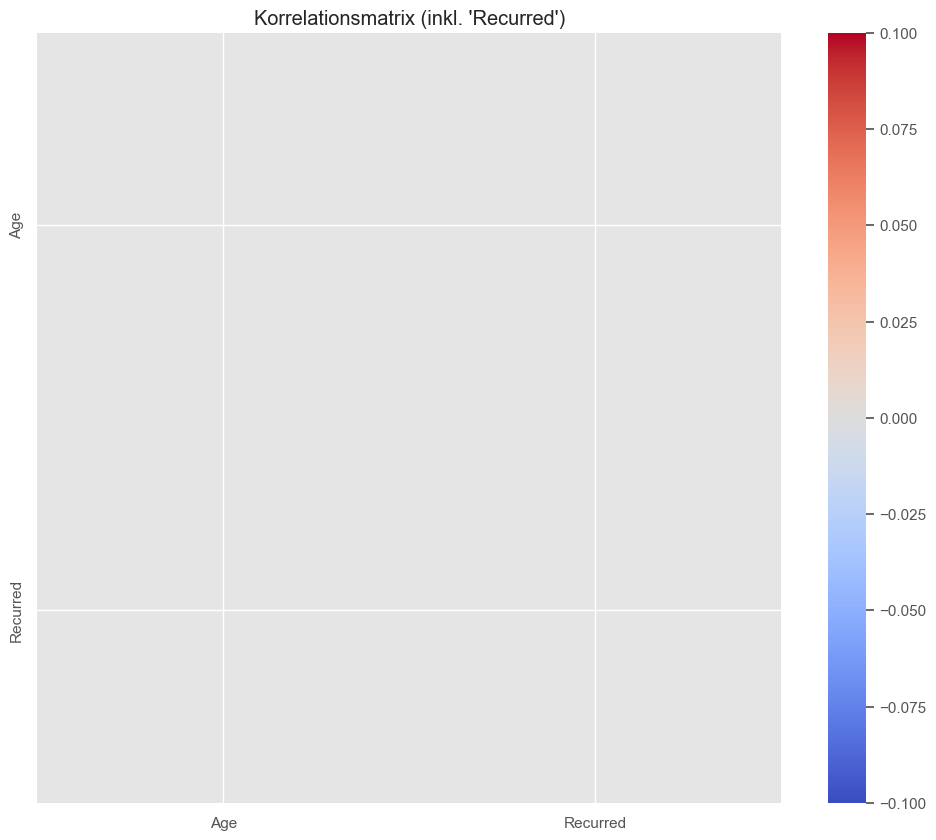

In [3393]:
#  Sicherstellen, dass 'Recurred' korrekt geschrieben und numerisch ist
if 'Recurred' not in df.columns:
    raise ValueError(" Spalte 'Recurred' nicht im DataFrame gefunden!")

df['Recurred'] = pd.to_numeric(df['Recurred'], errors='coerce')

#  Nur numerische Daten behalten und Zeilen mit NaN in 'Recurred' löschen
df_numeric = df.select_dtypes(include=[np.number])
df_numeric_clean = df_numeric.dropna(subset=['Recurred'])

#  Korrelationsmatrix berechnen
corr_matrix = df_numeric_clean.corr()

#  Zielspalte 'Recurred': relevante Features mit |Korrelation| ≥ 0.1 finden
target_corr = corr_matrix['Recurred'].drop('Recurred')
high_corr_features = target_corr[abs(target_corr) >= 0.1].index.tolist()

print(" Merkmale mit hoher Korrelation zu 'Recurred':")
print(high_corr_features)

#  Heatmap zeichnen
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Korrelationsmatrix (inkl. 'Recurred')")
plt.show()


In [3394]:
#  Sicherstellen, dass Zielvariable 'Recurred' existiert und kategorisch (z.B. 0/1)
if 'Recurred' not in df.columns:
    raise ValueError(" Spalte 'Recurred' nicht im DataFrame gefunden!")

# Zielvariable als Serie extrahieren
y = df['Recurred']

#  Kategorische Spalten erkennen (object oder category)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Leere Liste für Ergebnisse
chi2_scores = []

#  Chi²-Test für jede kategoriale Spalte
for col in categorical_cols:
    # Fehlende Werte entfernen (für stabile Berechnung)
    if df[col].isnull().any() or y.isnull().any():
        continue

    contingency = pd.crosstab(df[col], y)
    
    # Wenn Kontingenztabelle zu klein ist, überspringen
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue
    
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency)
    chi2_scores.append((col, chi2_stat, p_val))

#  Ergebnisse als DataFrame
chi2_results = pd.DataFrame(chi2_scores, columns=["Feature", "Chi2 Score", "P-Value"])
chi2_results = chi2_results.sort_values(by="Chi2 Score", ascending=False).reset_index(drop=True)

#  Ausgabe
print(" Chi²-Testergebnisse (zu Recurred):")
print(chi2_results)


🎯 Chi²-Testergebnisse (zu Recurred):
Empty DataFrame
Columns: [Feature, Chi2 Score, P-Value]
Index: []


In [3395]:
#  Zielvariable korrekt benennen (Groß-/Kleinschreibung beachten!)
target_col = 'Recurred'

#  Sicherstellen, dass Zielspalte numerisch ist (Ja/Nein → 1/0)
if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].map({'Yes': 1, 'No': 0})

#  Nur numerische Spalten auswählen
df_numeric = df.select_dtypes(include=[np.number])

#  Fehlende Werte entfernen
df_numeric_clean = df_numeric.dropna()

#  Korrelationsmatrix berechnen
corr_matrix = df_numeric_clean.corr()

#  Ziel-Korrelationen berechnen
target_corr = corr_matrix[target_col].drop(target_col)

#  Schwellenwert setzen (z.B. |0.1|)
schwelle = 0.1
high_corr_features = target_corr[abs(target_corr) >= schwelle].sort_values(ascending=False)

#  Ergebnisse anzeigen
if high_corr_features.empty:
    print(" Keine Features mit hoher Korrelation zu 'Recurred' gefunden (>|0.1|).")
else:
    print(" Features mit hoher Korrelation zu 'Recurred':")
    print(high_corr_features)

    #  Visualisierung nur wenn Daten vorhanden sind
    plt.figure(figsize=(10, 6))
    sns.barplot(x=high_corr_features.values, y=high_corr_features.index)
    plt.title("Korrelation mit Zielvariable 'Recurred'")
    plt.xlabel("Korrelationskoeffizient")
    plt.ylabel("Feature")
    plt.show()


⚠️ Keine Features mit hoher Korrelation zu 'Recurred' gefunden (>|0.1|).


In [3397]:
# Kopie des Originaldatensatzes
df_fe = df.copy()

# Feature: Ob Radiotherapie gemacht wurde (Ja/Nein)
df_fe['Hx_Radiotherapy_Done'] = df_fe['Hx Radiothreapy'].apply(lambda x: 0 if pd.isna(x) or x.strip().lower() == 'no' else 1)

# Feature: Fokalität - Uni-Fokal = 1, Multi-Fokal = 0
df_fe['Is_Uni_Focal'] = df_fe['Focality'].apply(lambda x: 1 if isinstance(x, str) and 'uni' in x.lower() else 0)

# Feature: Anzahl positiver TNM Marker (vereinfachte Risikoeinschätzung)
df_fe['TNM_Score'] = df_fe[['T', 'N', 'M']].apply(lambda row: sum([1 if str(val).strip().upper() != 'T0' and val != 'N0' and val != 'M0' else 0 for val in row]), axis=1)





# Feature Engineering auf deine Thyroid-Krebs-Daten
df_eng = df.copy()

# 1. Radiotherapie vorhanden? → 1 = Ja, 0 = Nein
df_eng['Has_Radiotherapy'] = df_eng['Hx Radiothreapy'].apply(lambda x: 1 if isinstance(x, str) and x.strip().lower() == 'yes' else 0)

# 2. Uni-Fokalität → 1 = Uni-Focal, 0 = Multi-Focal (oder unbekannt)
df_eng['Is_Uni_Focal'] = df_eng['Focality'].apply(lambda x: 1 if isinstance(x, str) and 'uni' in x.lower() else 0)

# 3. Simplifizierter TNM-Score: Wie viele Marker sind unnormal (T≠T0, N≠N0, M≠M0)?
def tnm_score(row):
    score = 0
    if isinstance(row['T'], str) and row['T'].strip().upper() != 'T0':
        score += 1
    if isinstance(row['N'], str) and row['N'].strip().upper() != 'N0':
        score += 1
    if isinstance(row['M'], str) and row['M'].strip().upper() != 'M0':
        score += 1
    return score

df_eng['TNM_Score'] = df_eng.apply(tnm_score, axis=1)

# 4. Reaktionsklassifikation binärisieren (z. B. Excellent = 1, Rest = 0)
df_eng['Good_Response'] = df_eng['Response'].apply(lambda x: 1 if isinstance(x, str) and 'excellent' in x.lower() else 0)


In [3398]:

model1 = DecisionTreeClassifier(random_state=42)
model2 = RandomForestClassifier(random_state=42)

# Modelle trainieren
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [3399]:
#  Spaltennamen vereinheitlichen (z. B. Leerzeichen entfernen)
df.columns = df.columns.str.strip()

#  'Recurred' binär machen
if 'Recurred' in df.columns:
    df['Recurred'] = df['Recurred'].map({'Yes': 1, 'No': 0})
    df = df[df['Recurred'].notna()]  # NaNs entfernen
else:
    raise ValueError(" Spalte 'Recurred' nicht im DataFrame gefunden!")

#  Label-Encoding für kategorische Spalten
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

#  Features und Zielvariable
X = df_encoded.drop(columns=['Recurred'])
y = df_encoded['Recurred']

#  Train/Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(" Erfolgreich aufgeteilt: X_train, X_test, y_train, y_test")


✅ Erfolgreich aufgeteilt: X_train, X_test, y_train, y_test


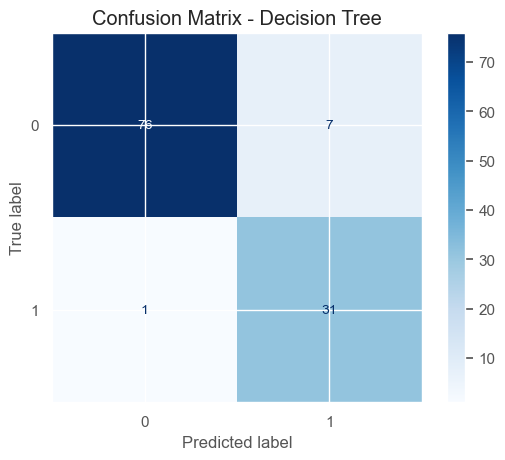

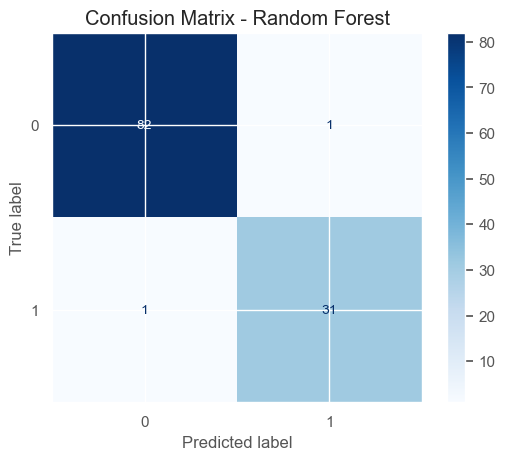

In [3400]:
#  Daten vorbereiten
df = df.copy()  # falls nötig, deepcopy

#  Zielvariable als binär kodieren
if df['Recurred'].dtype == 'object':
    df['Recurred'] = df['Recurred'].str.strip().str.capitalize()
    df = df[df['Recurred'].isin(['Yes', 'No'])]
    df['Recurred'] = df['Recurred'].map({'No': 0, 'Yes': 1})

#  Zielvariable
y = df['Recurred']

#  Kategorische Spalten encodieren
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

#  Features (alle außer Ziel)
X = df_encoded.drop(columns=['Recurred'])

#  NaN-Werte mit häufigstem Wert füllen
imputer = SimpleImputer(strategy='most_frequent')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

#  y synchronisieren
y = y.loc[X.index]

# ✂ Train-Test Split (70-30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#  Einheitliche Spaltennamen
X_train.columns = X_train.columns.str.lower()
X_test.columns = X_test.columns.str.lower()
X_test = X_test[X_train.columns]  # exakt gleiche Reihenfolge

#  Modell 1: Decision Tree
model1 = DecisionTreeClassifier(random_state=42)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

#  Modell 2: Random Forest
model2 = RandomForestClassifier(random_state=42)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

#  Konfusionsmatrix für Modell 1
conf_matrix1 = confusion_matrix(y_test, y_pred1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=conf_matrix1)
disp1.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Decision Tree')
plt.show()

#  Konfusionsmatrix für Modell 2
conf_matrix2 = confusion_matrix(y_test, y_pred2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=conf_matrix2)
disp2.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Random Forest')
plt.show()


In [3401]:
#  Klassifikationsbericht für Entscheidungsbaum
report1 = classification_report(y_test, y_pred1, target_names=['Nicht rezidiviert', 'Rezidiviert'])
print(" Klassifikationsbericht - Decision Tree")
print(report1)

#  Klassifikationsbericht für Random Forest
report2 = classification_report(y_test, y_pred2, target_names=['Nicht rezidiviert', 'Rezidiviert'])
print(" Klassifikationsbericht - Random Forest")
print(report2)


📄 Klassifikationsbericht - Decision Tree
                   precision    recall  f1-score   support

Nicht rezidiviert       0.99      0.92      0.95        83
      Rezidiviert       0.82      0.97      0.89        32

         accuracy                           0.93       115
        macro avg       0.90      0.94      0.92       115
     weighted avg       0.94      0.93      0.93       115

📄 Klassifikationsbericht - Random Forest
                   precision    recall  f1-score   support

Nicht rezidiviert       0.99      0.99      0.99        83
      Rezidiviert       0.97      0.97      0.97        32

         accuracy                           0.98       115
        macro avg       0.98      0.98      0.98       115
     weighted avg       0.98      0.98      0.98       115



Fitting 5 folds for each of 54 candidates, totalling 270 fits
Beste Parameter: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2, 'random_state': 1}
Bestes Modell: DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=1)


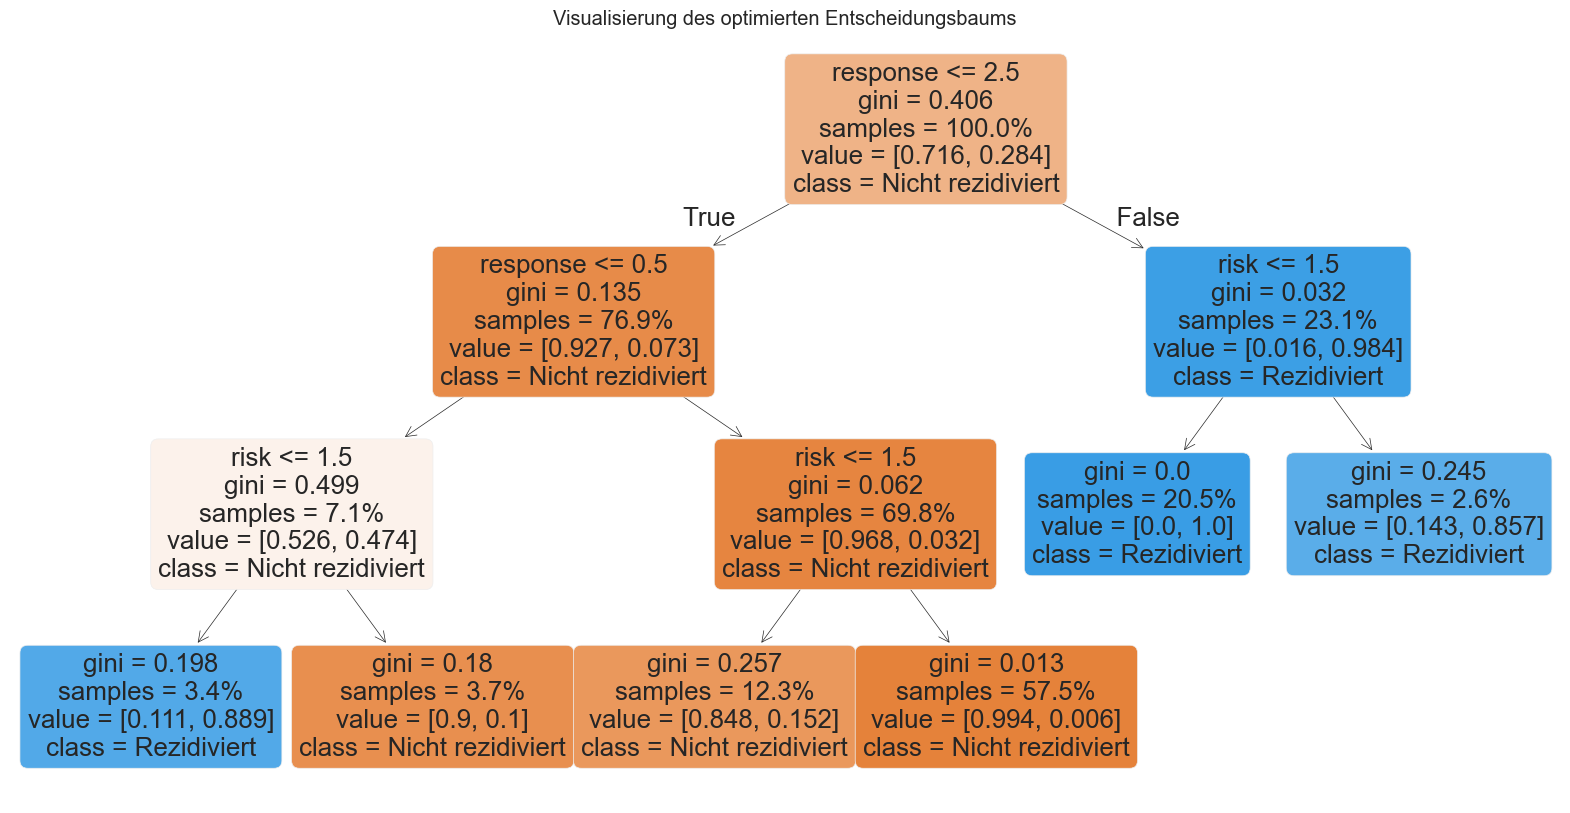

In [3402]:
#  Decision Tree Classifier
dt_model = tree.DecisionTreeClassifier()

#  Parameter-Raster
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'random_state': [1]
}

#  Grid Search mit 5-fach Cross Validation und f1-score
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='f1', verbose=1)
grid_search.fit(X_train, y_train)

#  Beste Parameter und Modell
print("Beste Parameter:", grid_search.best_params_)
print("Bestes Modell:", grid_search.best_estimator_)

#  Visualisierung des besten Entscheidungsbaums
plt.figure(figsize=(20, 10))
tree.plot_tree(grid_search.best_estimator_,
               filled=True,
               feature_names=X_train.columns.tolist(),
               class_names=['Nicht rezidiviert', 'Rezidiviert'],
               proportion=True,
               rounded=True)
plt.title('Visualisierung des optimierten Entscheidungsbaums')
plt.show()


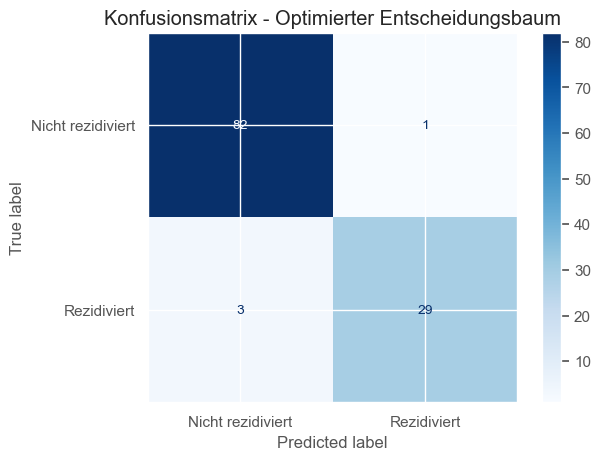

🔍 Klassifikationsbericht:
                    precision    recall  f1-score   support

Nicht rezidiviert       0.96      0.99      0.98        83
      Rezidiviert       0.97      0.91      0.94        32

         accuracy                           0.97       115
        macro avg       0.97      0.95      0.96       115
     weighted avg       0.97      0.97      0.96       115



In [3403]:
#  Vorhersagen mit dem besten Modell
y_pred_best = grid_search.best_estimator_.predict(X_test)

#  Konfusionsmatrix anzeigen
conf_matrix = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Nicht rezidiviert', 'Rezidiviert'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Konfusionsmatrix - Optimierter Entscheidungsbaum')
plt.show()

#  Klassifikationsbericht anzeigen
report = classification_report(y_test, y_pred_best, target_names=['Nicht rezidiviert', 'Rezidiviert'])
print(" Klassifikationsbericht:\n", report)


Fitting 5 folds for each of 81 candidates, totalling 405 fits


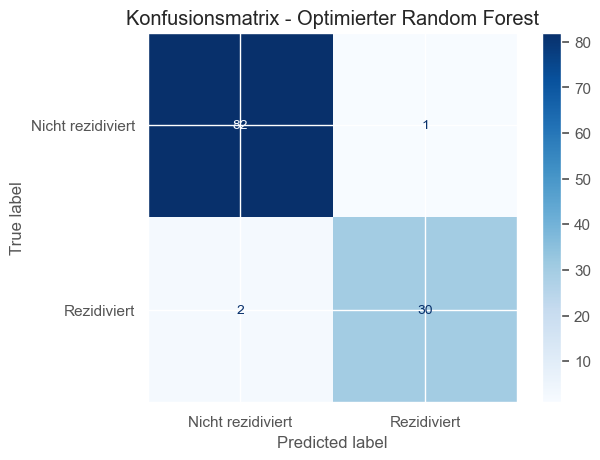

🔍 Klassifikationsbericht - Random Forest:
                    precision    recall  f1-score   support

Nicht rezidiviert       0.98      0.99      0.98        83
      Rezidiviert       0.97      0.94      0.95        32

         accuracy                           0.97       115
        macro avg       0.97      0.96      0.97       115
     weighted avg       0.97      0.97      0.97       115



In [3404]:
#  Parametergitter (ohne random_state!)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#  Random Forest Basis-Modell mit fixem random_state
rf_model = RandomForestClassifier(random_state=1)

#  Grid Search CV
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

#  Modell trainieren
grid_search_rf.fit(X_train, y_train)

#  Bestes Modell extrahieren
best_rf = grid_search_rf.best_estimator_

#  Vorhersagen
y_pred_best_rf = best_rf.predict(X_test)

#  Konfusionsmatrix anzeigen
conf_matrix_rf = confusion_matrix(y_test, y_pred_best_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf, display_labels=['Nicht rezidiviert', 'Rezidiviert'])
disp_rf.plot(cmap=plt.cm.Blues)
plt.title('Konfusionsmatrix - Optimierter Random Forest')
plt.show()

#  Klassifikationsbericht
report_rf = classification_report(y_test, y_pred_best_rf, target_names=['Nicht rezidiviert', 'Rezidiviert'])
print(" Klassifikationsbericht - Random Forest:\n", report_rf)


In [3405]:
#  Spaltennamen bereinigen (Kleinbuchstaben + Unterstrich)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

#  Zielvariable binär kodieren ('Yes' → 1, 'No' → 0)
df['recurred_binary'] = df['recurred'].map({'No': 0, 'Yes': 1})

#  Prüfen
print("Zielverteilung (recurred_binary):")
print(df['recurred_binary'].value_counts())


Zielverteilung (recurred_binary):
recurred_binary
0    275
1    108
Name: count, dtype: int64


In [3406]:
from sklearn.model_selection import train_test_split

#  Features und Ziel definieren
X = df.drop(columns=['recurred', 'recurred_binary'])
y = df['recurred_binary']

#  Kategorische Variablen in numerische umwandeln
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category').cat.codes

#  Trainings-/Testdaten aufteilen (stratifiziert)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

#  Ausgabe prüfen
print("Trainingsgröße:", X_train.shape)
print("Testgröße:", X_test.shape)


Trainingsgröße: (287, 16)
Testgröße: (96, 16)



📈 Training des Modells: Entscheidungsbaum ...


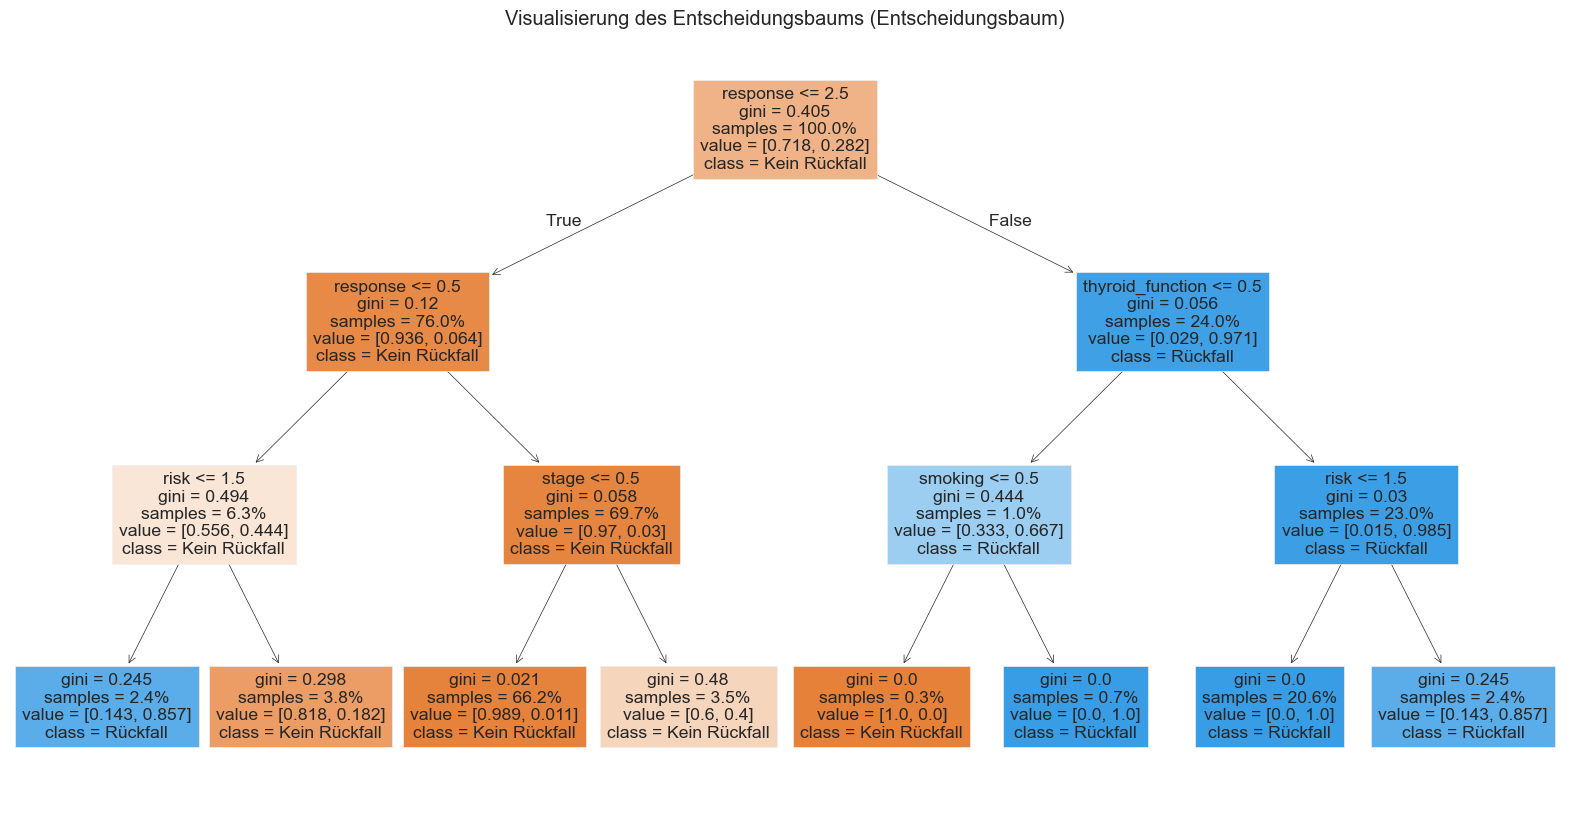


📈 Training des Modells: Random Forest ...


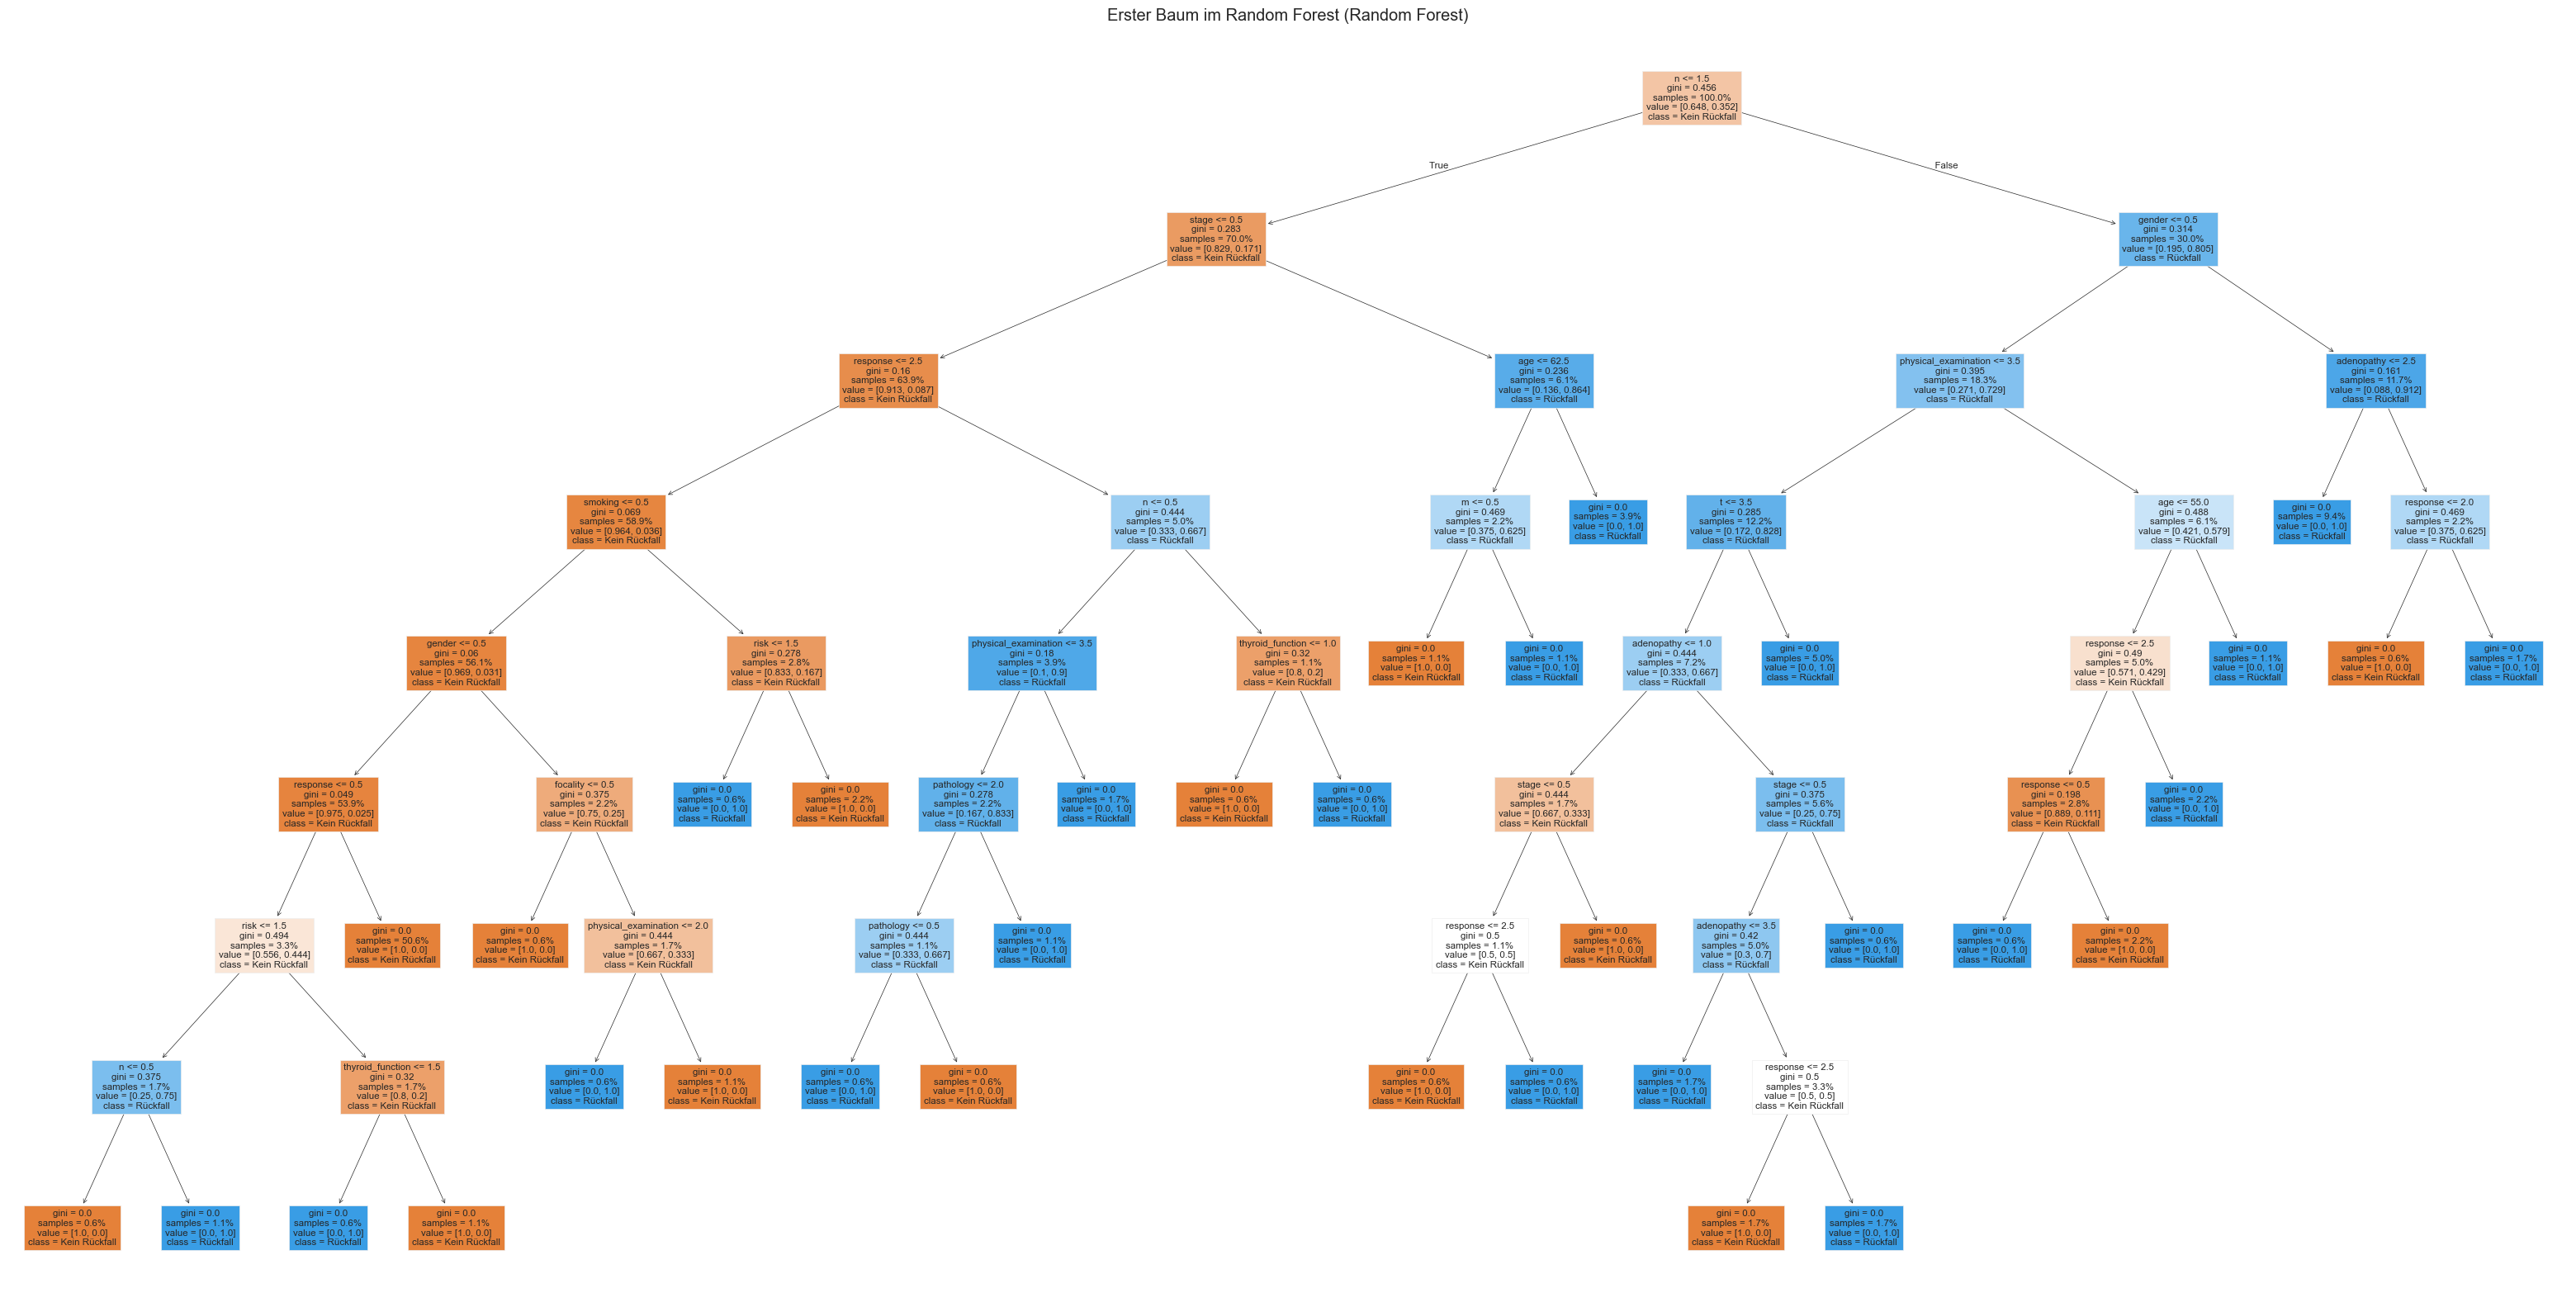


📈 Training des Modells: XGBoost ...


<Figure size 2000x1000 with 0 Axes>

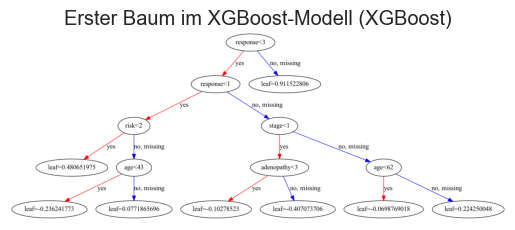

In [3407]:
#  Verschiedene Modelle vorbereiten
models = {
    'Entscheidungsbaum': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

#  Training & Visualisierung
for name, model in models.items():
    print(f"\n Training des Modells: {name} ...")
    model.fit(X_train, y_train)

    #  Entscheidungsbaum visualisieren
    if isinstance(model, DecisionTreeClassifier):
        plt.figure(figsize=(20, 10))
        plot_tree(
            model, filled=True,
            feature_names=X_train.columns.tolist(),
            class_names=['Kein Rückfall', 'Rückfall'],
            proportion=True
        )
        plt.title(f'Visualisierung des Entscheidungsbaums ({name})')
        plt.show()

    #  Random Forest: Erster Baum visualisieren
    if isinstance(model, RandomForestClassifier):
        plt.figure(figsize=(40, 20))
        plot_tree(
            model.estimators_[0], filled=True,
            feature_names=X_train.columns.tolist(),
            class_names=['Kein Rückfall', 'Rückfall'],
            proportion=True
        )
        plt.title(f'Erster Baum im Random Forest ({name})')
        plt.show()

    #  XGBoost: Erster Baum visualisieren
    if isinstance(model, XGBClassifier):
        plt.figure(figsize=(20, 10))
        xgb_plot_tree(model, num_trees=0)
        plt.title(f'Erster Baum im XGBoost-Modell ({name})')
        plt.show()



📌 Bewertung für: Decision Tree

Klassifikationsbericht:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        69
           1       1.00      0.93      0.96        27

    accuracy                           0.98        96
   macro avg       0.99      0.96      0.97        96
weighted avg       0.98      0.98      0.98        96

Konfusionsmatrix:
[[69  0]
 [ 2 25]]


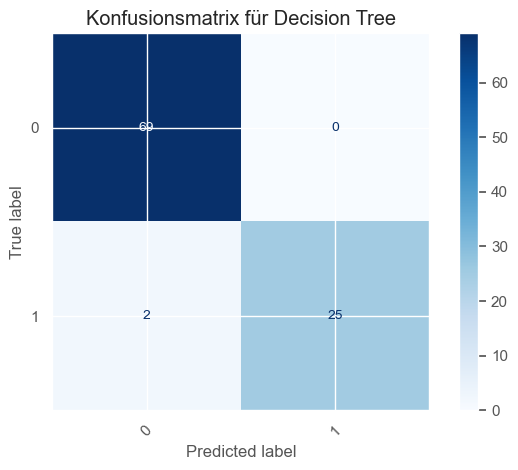


📌 Bewertung für: Random Forest

Klassifikationsbericht:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        69
           1       1.00      0.89      0.94        27

    accuracy                           0.97        96
   macro avg       0.98      0.94      0.96        96
weighted avg       0.97      0.97      0.97        96

Konfusionsmatrix:
[[69  0]
 [ 3 24]]


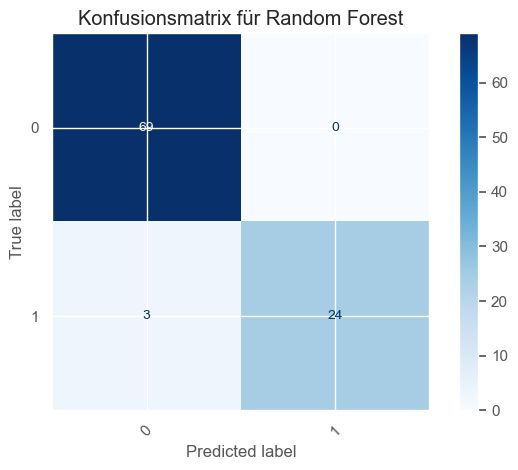


📌 Bewertung für: XGBoost

Klassifikationsbericht:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        69
           1       1.00      0.96      0.98        27

    accuracy                           0.99        96
   macro avg       0.99      0.98      0.99        96
weighted avg       0.99      0.99      0.99        96

Konfusionsmatrix:
[[69  0]
 [ 1 26]]


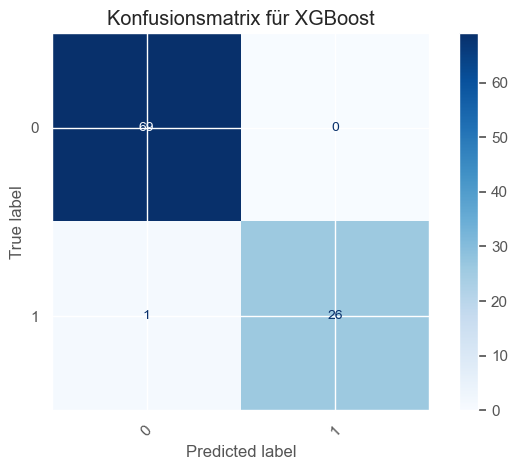


📊 Zusammenfassung der Ergebnisse:

🔹 Decision Tree
Genauigkeit: 0.9792
Präzision: 0.9798
Recall: 0.9792
F1-Score: 0.9789

🔹 Random Forest
Genauigkeit: 0.9688
Präzision: 0.9701
Recall: 0.9688
F1-Score: 0.9682

🔹 XGBoost
Genauigkeit: 0.9896
Präzision: 0.9897
Recall: 0.9896
F1-Score: 0.9895


In [3408]:
#  Dictionary zur Speicherung der Ergebnisse
evaluation_results = {}

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

#  Modelle trainieren
for name, model in models.items():
    model.fit(X_train, y_train)

#  Modelle bewerten
for model_name, model in models.items():
    print(f"\n Bewertung für: {model_name}")

    #  Vorhersage auf Testdaten
    y_pred = model.predict(X_test)

    #  Kennzahlen berechnen
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    #  Ergebnisse speichern
    evaluation_results[model_name] = {
        'Genauigkeit': accuracy,
        'Präzision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

    #  Klassifikationsbericht
    print("\nKlassifikationsbericht:")
    print(classification_report(y_test, y_pred, zero_division=0))

    #  Konfusionsmatrix
    cm = confusion_matrix(y_test, y_pred)
    print("Konfusionsmatrix:")
    print(cm)

    #  Matrix visualisieren
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title(f"Konfusionsmatrix für {model_name}")
    plt.tight_layout()
    plt.show()

#  Gesamtergebnis anzeigen
print("\n Zusammenfassung der Ergebnisse:")
for name, metrics in evaluation_results.items():
    print(f"\n {name}")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")


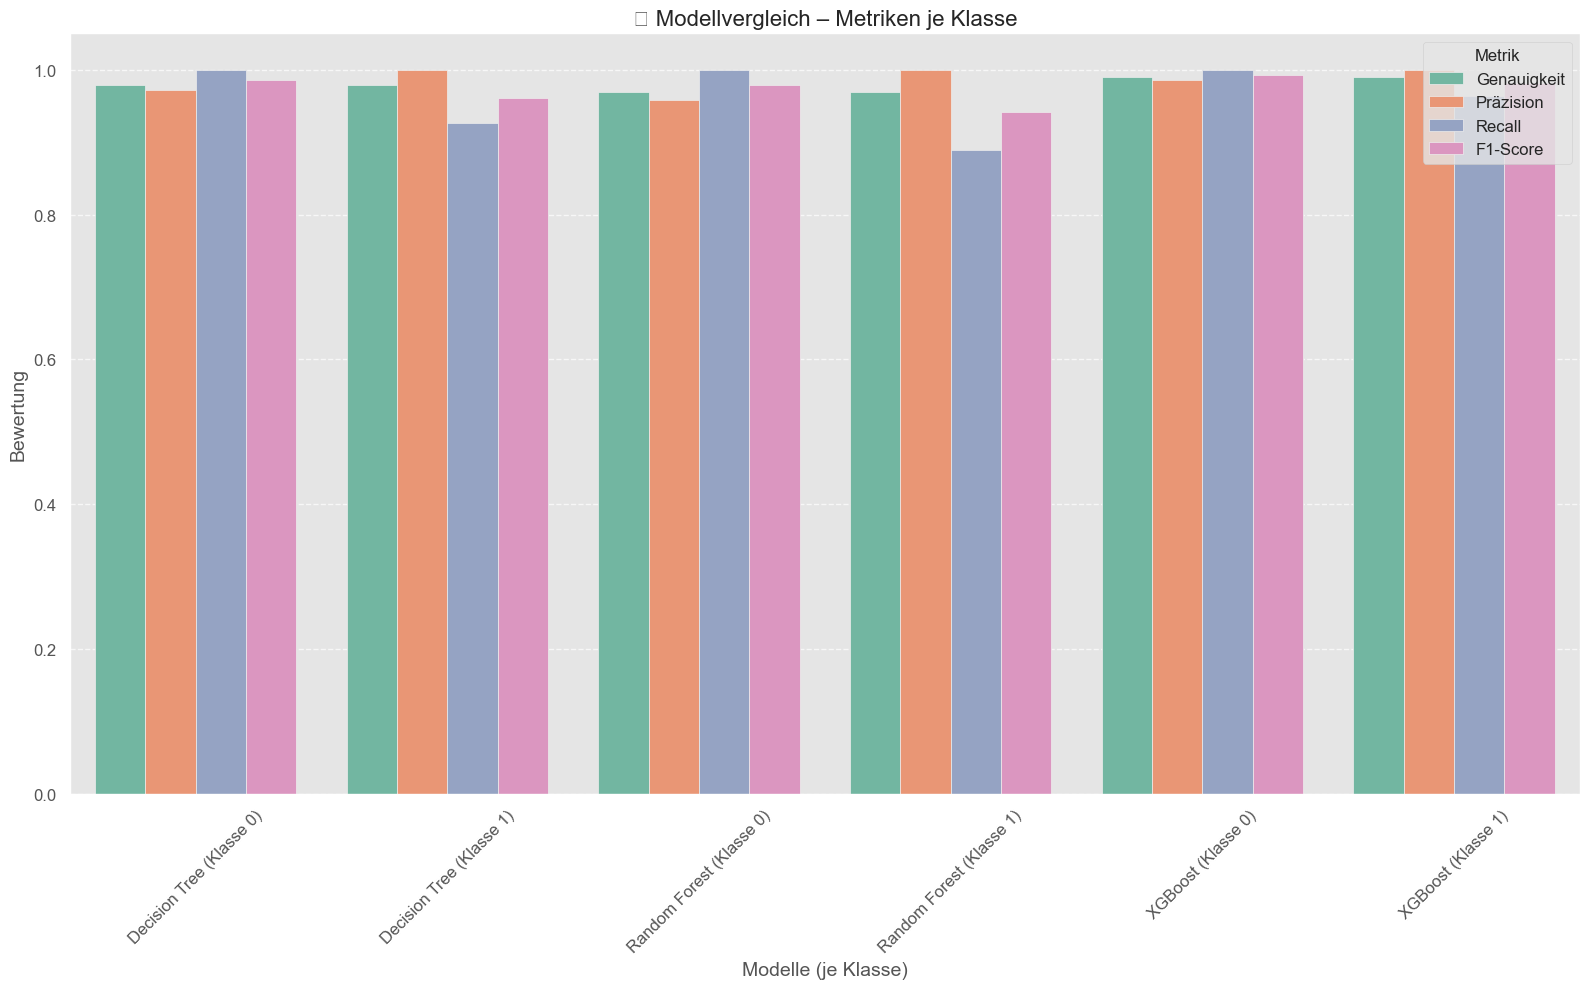


📋 Detaillierte Metriken für jedes Modell:
                      Modell       Metrik      Wert
0   Decision Tree (Klasse 0)  Genauigkeit  0.979167
1   Decision Tree (Klasse 0)    Präzision  0.971831
2   Decision Tree (Klasse 0)       Recall  1.000000
3   Decision Tree (Klasse 0)     F1-Score  0.985714
4   Decision Tree (Klasse 1)  Genauigkeit  0.979167
5   Decision Tree (Klasse 1)    Präzision  1.000000
6   Decision Tree (Klasse 1)       Recall  0.925926
7   Decision Tree (Klasse 1)     F1-Score  0.961538
8   Random Forest (Klasse 0)  Genauigkeit  0.968750
9   Random Forest (Klasse 0)    Präzision  0.958333
10  Random Forest (Klasse 0)       Recall  1.000000
11  Random Forest (Klasse 0)     F1-Score  0.978723
12  Random Forest (Klasse 1)  Genauigkeit  0.968750
13  Random Forest (Klasse 1)    Präzision  1.000000
14  Random Forest (Klasse 1)       Recall  0.888889
15  Random Forest (Klasse 1)     F1-Score  0.941176
16        XGBoost (Klasse 0)  Genauigkeit  0.989583
17        XGBoost (Kl

In [3409]:


#  Ergebnisliste vorbereiten
ergebnisse = []

#  Modelle durchlaufen und Metriken berechnen
for modellname, modell in models.items():
    y_vorhersage = modell.predict(X_test)

    #  Metriken für Klasse 0 (kein Rückfall)
    genauigkeit = accuracy_score(y_test, y_vorhersage)
    praezision_0 = precision_score(y_test, y_vorhersage, pos_label=0)
    recall_0 = recall_score(y_test, y_vorhersage, pos_label=0)
    f1_0 = f1_score(y_test, y_vorhersage, pos_label=0)

    ergebnisse.append({'Modell': f"{modellname} (Klasse 0)", 'Metrik': 'Genauigkeit', 'Wert': genauigkeit})
    ergebnisse.append({'Modell': f"{modellname} (Klasse 0)", 'Metrik': 'Präzision', 'Wert': praezision_0})
    ergebnisse.append({'Modell': f"{modellname} (Klasse 0)", 'Metrik': 'Recall', 'Wert': recall_0})
    ergebnisse.append({'Modell': f"{modellname} (Klasse 0)", 'Metrik': 'F1-Score', 'Wert': f1_0})

    #  Metriken für Klasse 1 (Rückfall)
    praezision_1 = precision_score(y_test, y_vorhersage, pos_label=1)
    recall_1 = recall_score(y_test, y_vorhersage, pos_label=1)
    f1_1 = f1_score(y_test, y_vorhersage, pos_label=1)

    ergebnisse.append({'Modell': f"{modellname} (Klasse 1)", 'Metrik': 'Genauigkeit', 'Wert': genauigkeit})
    ergebnisse.append({'Modell': f"{modellname} (Klasse 1)", 'Metrik': 'Präzision', 'Wert': praezision_1})
    ergebnisse.append({'Modell': f"{modellname} (Klasse 1)", 'Metrik': 'Recall', 'Wert': recall_1})
    ergebnisse.append({'Modell': f"{modellname} (Klasse 1)", 'Metrik': 'F1-Score', 'Wert': f1_1})

#  Ergebnisse als DataFrame
vergleich_df = pd.DataFrame(ergebnisse)

#  Balkendiagramm zur Visualisierung der Modellleistung
plt.figure(figsize=(16, 10))
sns.barplot(data=vergleich_df, x="Modell", y="Wert", hue="Metrik", palette="Set2", dodge=True)
plt.title(" Modellvergleich – Metriken je Klasse", fontsize=16)
plt.ylabel("Bewertung", fontsize=14)
plt.xlabel("Modelle (je Klasse)", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Metrik", loc="upper right", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#  Tabelle ausgeben
print("\n Detaillierte Metriken für jedes Modell:")
print(vergleich_df)


In [3410]:
#  Nur eindeutige Modelle sicherstellen (wichtig, wenn doppelte Keys existieren)
einzigartige_modelle = {name: modell for name, modell in models.items()}

#  Training vs. Test-Leistung prüfen
for name, modell in einzigartige_modelle.items():
    print(f"\n Bewertung für Modell: {name}")

    #  Vorhersage auf Trainingsdaten
    y_train_pred = modell.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    #  Vorhersage auf Testdaten
    y_test_pred = modell.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    #  Genauigkeiten anzeigen
    print(f"Trainingsgenauigkeit für {name}: {train_acc:.4f}")
    print(f"Testgenauigkeit für {name}:     {test_acc:.4f}")

    #  Unterschied analysieren
    diff = train_acc - test_acc
    if diff > 0.10:
        print("⚠ Hinweis: Mögliches Overfitting!")
    elif diff < -0.05:
        print(" Hinweis: Möglicherweise Underfitting!")
    else:
        print(" Modell hat eine gute Generalisierung.")



🔍 Bewertung für Modell: Decision Tree
Trainingsgenauigkeit für Decision Tree: 0.9652
Testgenauigkeit für Decision Tree:     0.9792
✅ Modell hat eine gute Generalisierung.

🔍 Bewertung für Modell: Random Forest
Trainingsgenauigkeit für Random Forest: 1.0000
Testgenauigkeit für Random Forest:     0.9688
✅ Modell hat eine gute Generalisierung.

🔍 Bewertung für Modell: XGBoost
Trainingsgenauigkeit für XGBoost: 1.0000
Testgenauigkeit für XGBoost:     0.9896
✅ Modell hat eine gute Generalisierung.



📊 Zeichne Lernkurve (Recall) für: Decision Tree


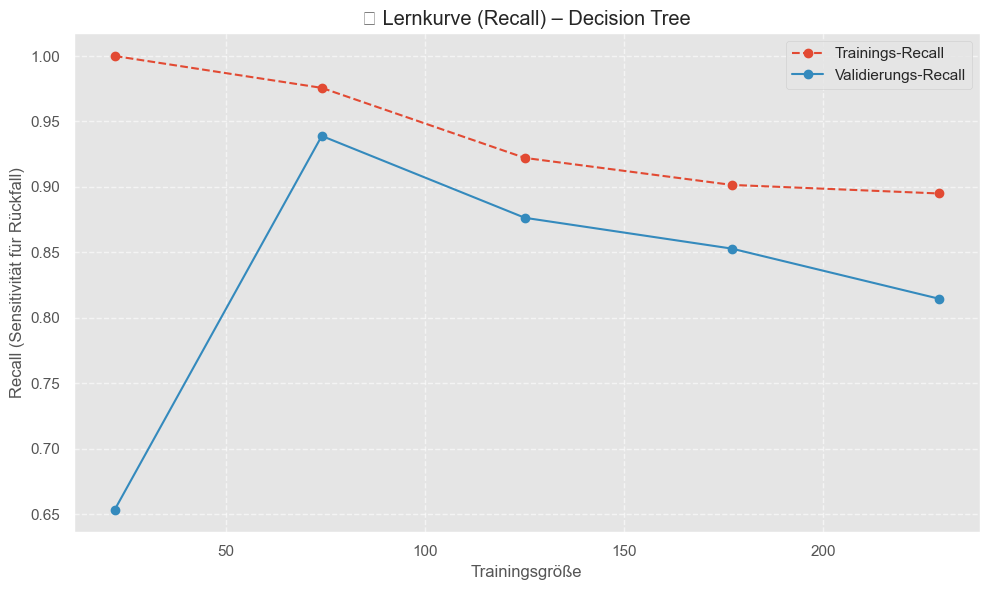


📊 Zeichne Lernkurve (Recall) für: Random Forest


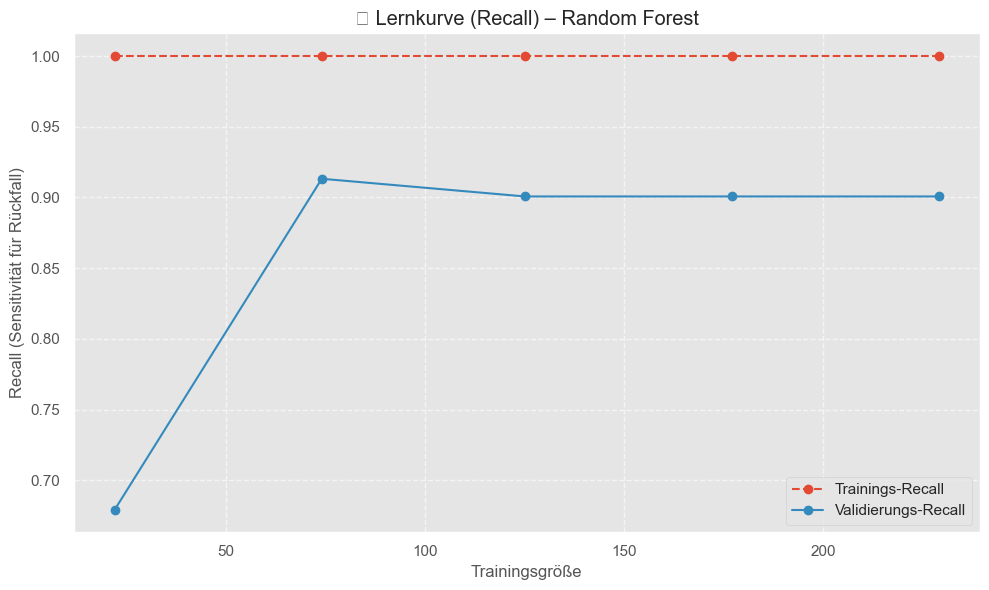


📊 Zeichne Lernkurve (Recall) für: XGBoost


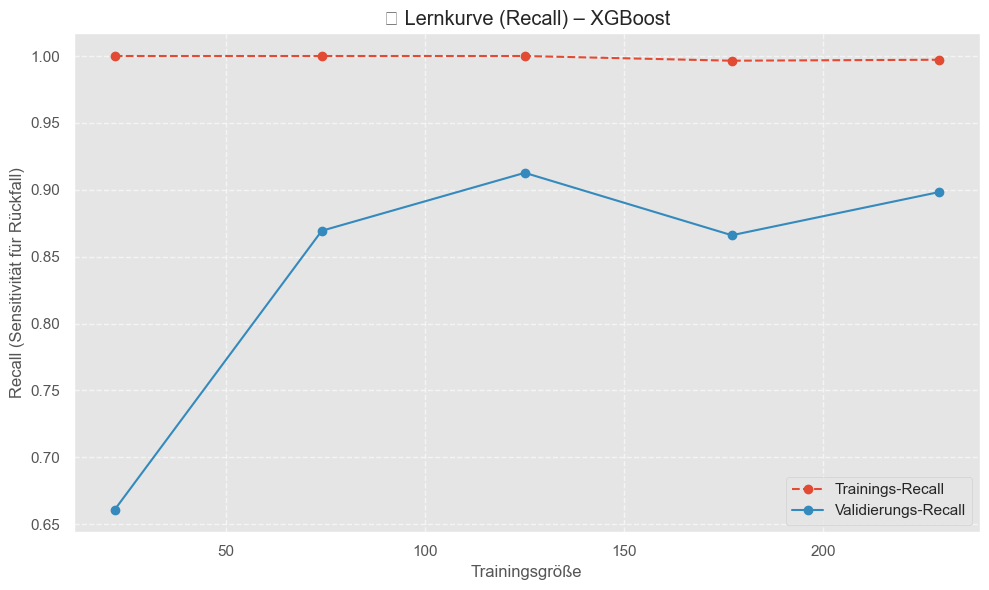

In [3411]:
#  Lernkurven-Analyse für jeden Klassifikator
for name, modell in models.items():
    print(f"\n Zeichne Lernkurve (Recall) für: {name}")

    #  Lernkurvendaten sammeln (nur für Klasse 1 → Rückfall)
    train_sizes, train_scores, val_scores = learning_curve(
        modell, X_train, y_train,
        cv=5,
        scoring=make_scorer(recall_score, pos_label=1),
        train_sizes=np.linspace(0.1, 1.0, 5),
        random_state=42
    )

    #  Durchschnitt berechnen
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    #  Plot erstellen
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o--', label="Trainings-Recall")
    plt.plot(train_sizes, val_mean, 'o-', label="Validierungs-Recall")
    plt.title(f" Lernkurve (Recall) – {name}")
    plt.xlabel("Trainingsgröße")
    plt.ylabel("Recall (Sensitivität für Rückfall)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


In [3412]:
#  Stratified K-Fold vorbereiten
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#  Kreuzvalidierung durchführen
for name, modell in models.items():
    print(f"\n Stratifizierte Kreuzvalidierung für: {name}")

    #  Cross-Validation auf Trainingsdaten (für Recall von Klasse 1)
    recall_scores = cross_val_score(
        modell, X_train, y_train,
        cv=stratified_kfold,
        scoring=make_scorer(recall_score, pos_label=1)
    )

    #  Ergebnisse anzeigen
    print(f"Recall-Werte (CV) für {name}: {recall_scores}")
    print(f" Durchschnittlicher Recall (CV): {recall_scores.mean():.4f}")



🔁 Stratifizierte Kreuzvalidierung für: Decision Tree
Recall-Werte (CV) für Decision Tree: [0.6875     0.82352941 0.8125     0.75       0.875     ]
📊 Durchschnittlicher Recall (CV): 0.7897

🔁 Stratifizierte Kreuzvalidierung für: Random Forest
Recall-Werte (CV) für Random Forest: [0.6875     0.94117647 0.875      0.8125     0.9375    ]
📊 Durchschnittlicher Recall (CV): 0.8507

🔁 Stratifizierte Kreuzvalidierung für: XGBoost
Recall-Werte (CV) für XGBoost: [0.6875     0.94117647 0.875      0.8125     0.9375    ]
📊 Durchschnittlicher Recall (CV): 0.8507


In [3413]:
#  Ignore Warnings
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn')

#  Hiperparameter-Raster für jedes Modell
param_grid = {
    'Decision Tree': {
        'max_depth': [5, 10, 15, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [100, 150, 200],
        'max_depth': [10, 20, 30, 50],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 150],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.7, 1.0],
        'colsample_bytree': [0.7, 1.0],
    },
}

#  Modelle definieren
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

#  Bestes Modell für jeden Typ speichern
best_models = {}

#  GridSearchCV für jedes Modell durchführen
for name, model in models.items():
    print(f"\n GridSearchCV für {name} wird durchgeführt...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid[name],
        cv=5,
        scoring=make_scorer(recall_score, pos_label=1),
        verbose=1,
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_

    print(f" Beste Parameter für {name}: {grid.best_params_}")
    print(f" Bester Recall-Score: {grid.best_score_:.4f}")



🎯 GridSearchCV für Decision Tree wird durchgeführt...
Fitting 5 folds for each of 45 candidates, totalling 225 fits
✅ Beste Parameter für Decision Tree: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
📊 Bester Recall-Score: 0.8757

🎯 GridSearchCV für Random Forest wird durchgeführt...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
✅ Beste Parameter für Random Forest: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
📊 Bester Recall-Score: 0.9125

🎯 GridSearchCV für XGBoost wird durchgeführt...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
✅ Beste Parameter für XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 150, 'subsample': 0.7}
📊 Bester Recall-Score: 0.8993


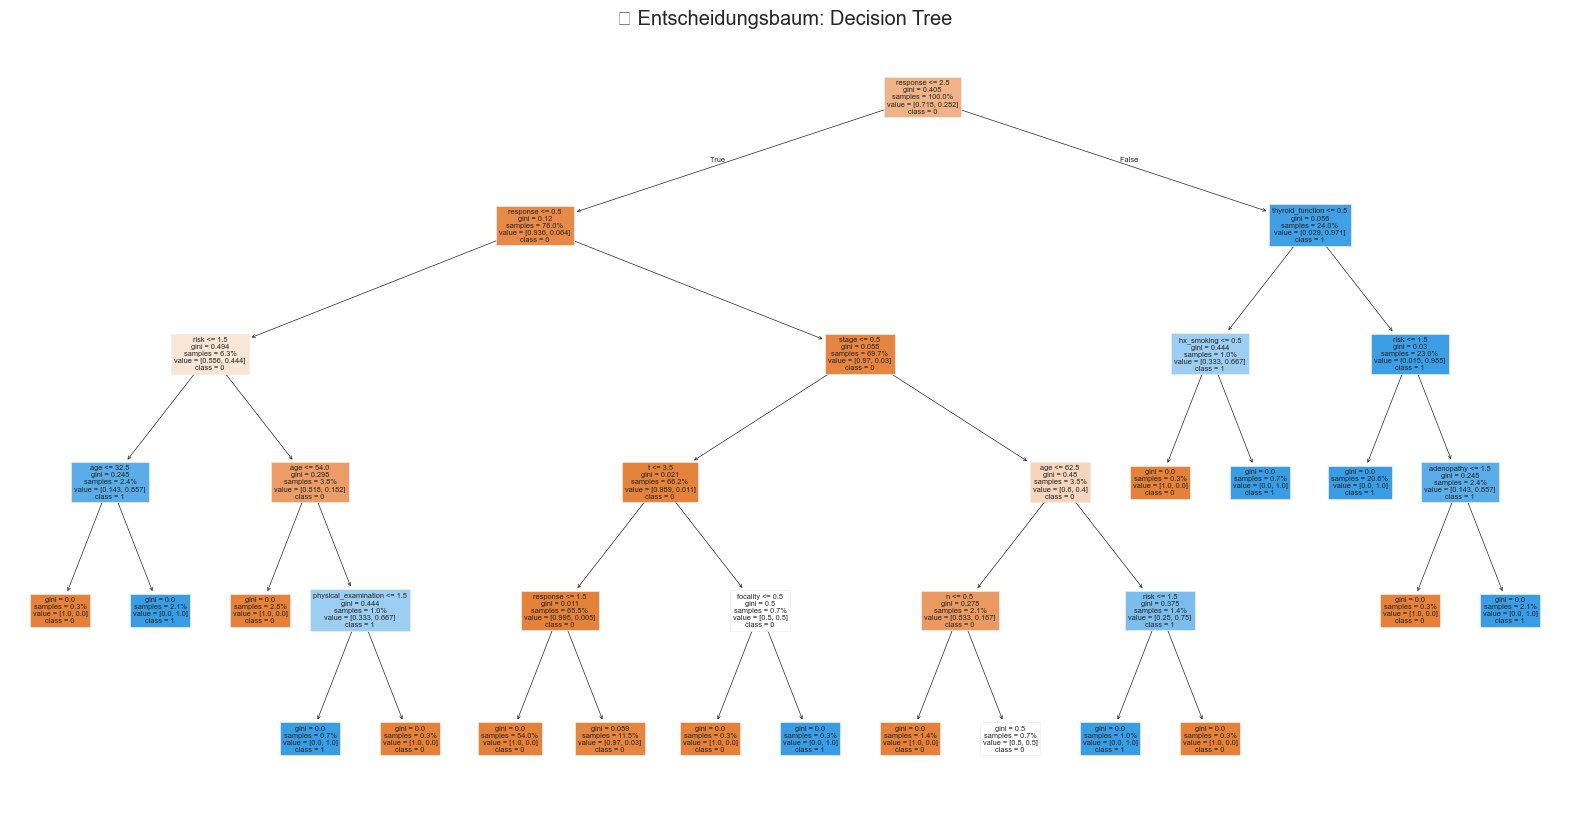

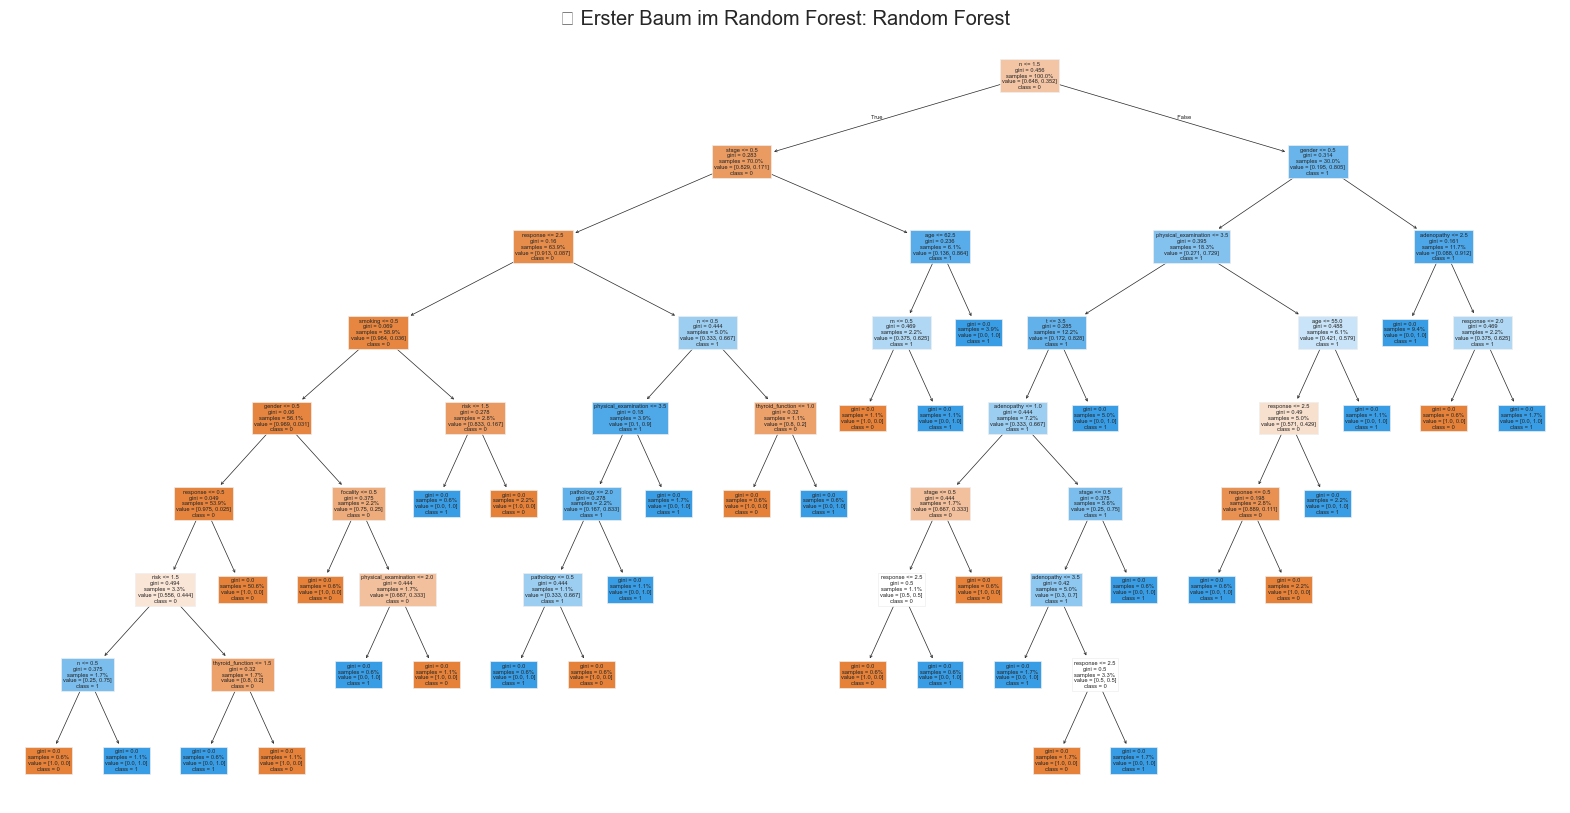

<Figure size 2000x1000 with 0 Axes>

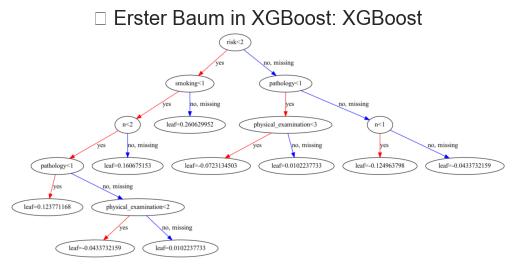

In [3414]:
def plot_best_models(best_models, X_train, model_names):
    for name in model_names:
        modell = best_models[name]

        if isinstance(modell, DecisionTreeClassifier):
            plt.figure(figsize=(20, 10))
            plot_tree(modell, filled=True, feature_names=X_train.columns.tolist(),
                      class_names=modell.classes_.astype(str), proportion=True)
            plt.title(f' Entscheidungsbaum: {name}')
            plt.show()

        elif isinstance(modell, RandomForestClassifier):
            baum = modell.estimators_[0]
            plt.figure(figsize=(20, 10))
            plot_tree(baum, filled=True, feature_names=X_train.columns.tolist(),
                      class_names=modell.classes_.astype(str), proportion=True)
            plt.title(f' Erster Baum im Random Forest: {name}')
            plt.show()

        elif isinstance(modell, XGBClassifier):
            plt.figure(figsize=(20, 10))
            xgb.plot_tree(modell, num_trees=0)
            plt.title(f' Erster Baum in XGBoost: {name}')
            plt.show()

#  Modelle zeichnen
model_names = ['Decision Tree', 'Random Forest', 'XGBoost']
plot_best_models(best_models, X_train, model_names)


In [3415]:
# Modelle bewerten und Metriken speichern
metriken = []

for model_name, model in rsmpl_models.items():
    print(f"\nTrainiere {model_name}...")  # Modelin eğitildiğini belirtiyoruz
    model.fit(X_train, y_train)  # Modeli verilerle eğitiyoruz
    
    # Vorhersagen machen
    y_pred = model.predict(X_test)

    # Metriken berechnen
    recall = recall_score(y_test, y_pred, pos_label=1)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Ergebnisse speichern
    metriken.append({
        'Modell': model_name,
        'Genauigkeit': accuracy,
        'Präzision': precision,
        'Recall (Klasse 1)': recall,
        'F1-Score': f1
    })

# Eine DataFrame erstellen, um die Modelle besser zu vergleichen
metriken_df = pd.DataFrame(metriken)

# Zeige das DataFrame im Jupyter Notebook an
metriken_df



Trainiere Entscheidungsbaum...

Trainiere Zufallswald...

Trainiere XGBoost...


,Modell,Genauigkeit,Präzision,Recall (Klasse 1),F1-Score
0,Entscheidungsbaum,0.979167,0.979754,0.925926,0.978915
1,Zufallswald,0.968750,0.970052,0.888889,0.968163
2,XGBoost,0.989583,0.989732,0.962963,0.989523


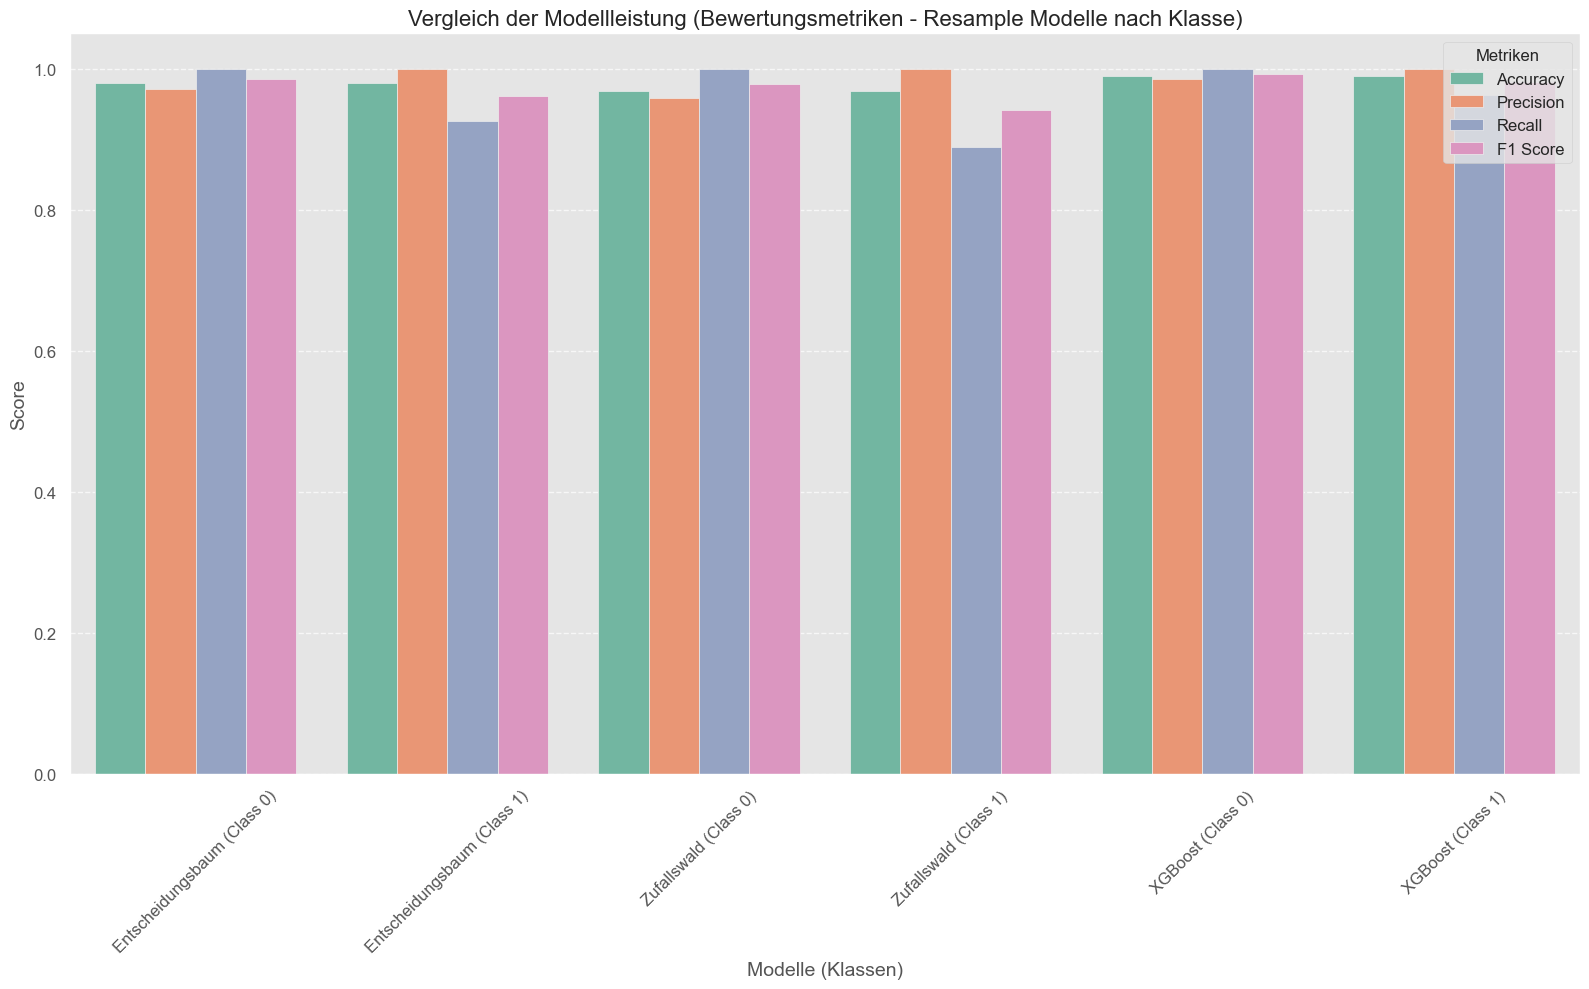


Detaillierte Metriken für jedes resampled Modell und jede Klasse:
                          Model     Metric     Value
0   Entscheidungsbaum (Class 0)   Accuracy  0.979167
1   Entscheidungsbaum (Class 0)  Precision  0.971831
2   Entscheidungsbaum (Class 0)     Recall  1.000000
3   Entscheidungsbaum (Class 0)   F1 Score  0.985714
4   Entscheidungsbaum (Class 1)   Accuracy  0.979167
5   Entscheidungsbaum (Class 1)  Precision  1.000000
6   Entscheidungsbaum (Class 1)     Recall  0.925926
7   Entscheidungsbaum (Class 1)   F1 Score  0.961538
8         Zufallswald (Class 0)   Accuracy  0.968750
9         Zufallswald (Class 0)  Precision  0.958333
10        Zufallswald (Class 0)     Recall  1.000000
11        Zufallswald (Class 0)   F1 Score  0.978723
12        Zufallswald (Class 1)   Accuracy  0.968750
13        Zufallswald (Class 1)  Precision  1.000000
14        Zufallswald (Class 1)     Recall  0.888889
15        Zufallswald (Class 1)   F1 Score  0.941176
16            XGBoost (Class 0) 

In [3416]:
# Ergebnisse der bewerteten Modelle speichern
results_rsmpl_1 = []

# Modelle bewerten und Metriken berechnen
for model_name, model in rsmpl_models.items():
    y_pred = model.predict(X_test)

    # Metriken für Klasse 0 berechnen
    accuracy = accuracy_score(y_test, y_pred)
    precision_0 = precision_score(y_test, y_pred, pos_label=0)
    recall_0 = recall_score(y_test, y_pred, pos_label=0)
    f1_0 = f1_score(y_test, y_pred, pos_label=0)

    results_rsmpl_1.append({'Model': f"{model_name} (Class 0)", 'Metric': 'Accuracy', 'Value': accuracy})
    results_rsmpl_1.append({'Model': f"{model_name} (Class 0)", 'Metric': 'Precision', 'Value': precision_0})
    results_rsmpl_1.append({'Model': f"{model_name} (Class 0)", 'Metric': 'Recall', 'Value': recall_0})
    results_rsmpl_1.append({'Model': f"{model_name} (Class 0)", 'Metric': 'F1 Score', 'Value': f1_0})

    # Metriken für Klasse 1 berechnen
    precision_1 = precision_score(y_test, y_pred, pos_label=1)
    recall_1 = recall_score(y_test, y_pred, pos_label=1)
    f1_1 = f1_score(y_test, y_pred, pos_label=1)

    results_rsmpl_1.append({'Model': f"{model_name} (Class 1)", 'Metric': 'Accuracy', 'Value': accuracy})  # Accuracy ist gleich
    results_rsmpl_1.append({'Model': f"{model_name} (Class 1)", 'Metric': 'Precision', 'Value': precision_1})
    results_rsmpl_1.append({'Model': f"{model_name} (Class 1)", 'Metric': 'Recall', 'Value': recall_1})
    results_rsmpl_1.append({'Model': f"{model_name} (Class 1)", 'Metric': 'F1 Score', 'Value': f1_1})

# Ergebnisse in ein DataFrame umwandeln
comparison_df_rsmpl = pd.DataFrame(results_rsmpl_1)

# Leistung der Modelle visualisieren (alle Bewertungsmetriken für die resampled Modelle nach Klasse)
plt.figure(figsize=(16, 10))
sns.barplot(data=comparison_df_rsmpl, x="Model", y="Value", hue="Metric", palette="Set2", dodge=True)
plt.title("Vergleich der Modellleistung (Bewertungsmetriken - Resample Modelle nach Klasse)", fontsize=16)
plt.ylabel("Score", fontsize=14)
plt.xlabel("Modelle (Klassen)", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Metriken", loc="upper right", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Detaillierte Metriken für jedes Modell ausgeben
print("\nDetaillierte Metriken für jedes resampled Modell und jede Klasse:")
print(comparison_df_rsmpl)


In [3417]:
# Mit SMOTE und ENN kombinasyonu Beispiele
smote_enn = SMOTEENN(sampling_strategy='auto', random_state=42)
X_resampled_smote_enn, y_resampled_smote_enn = smote_enn.fit_resample(X_train, y_train)

# X_resampled_smote_enn ve y_resampled_smote_enn jetzt


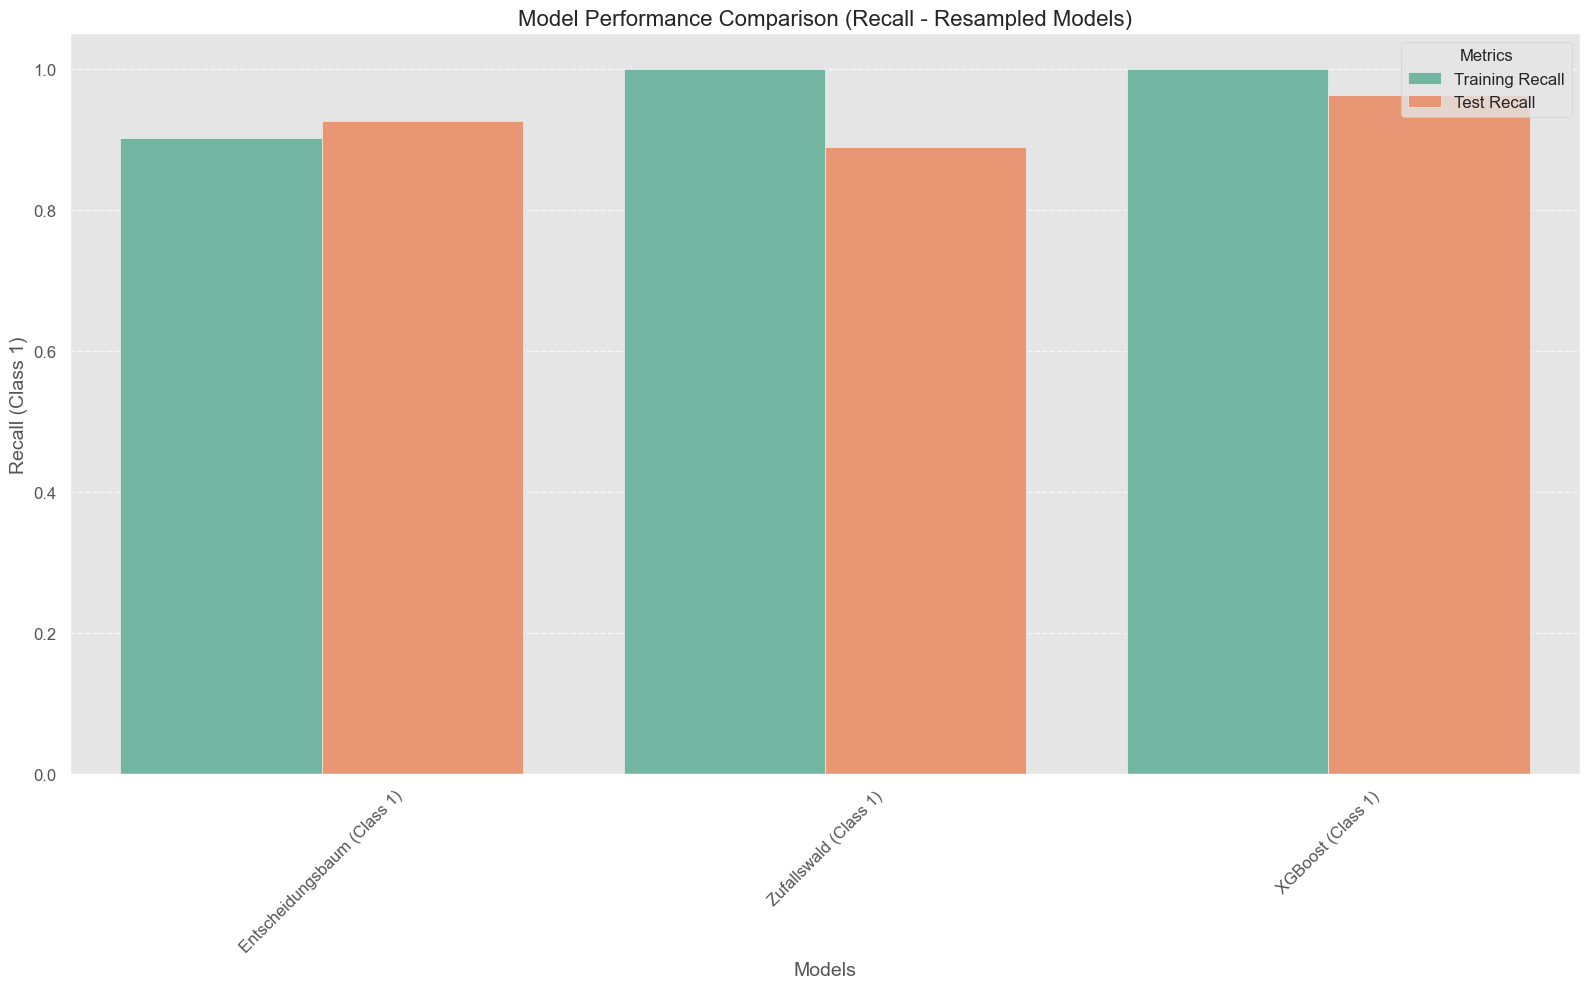


Plotting Learning Curve for Entscheidungsbaum...


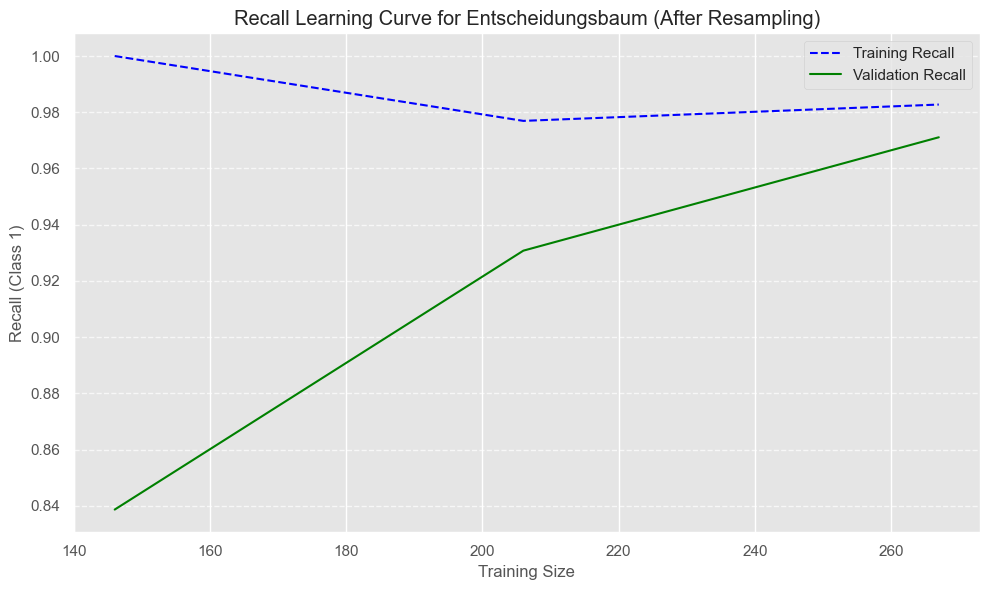


Plotting Learning Curve for Zufallswald...


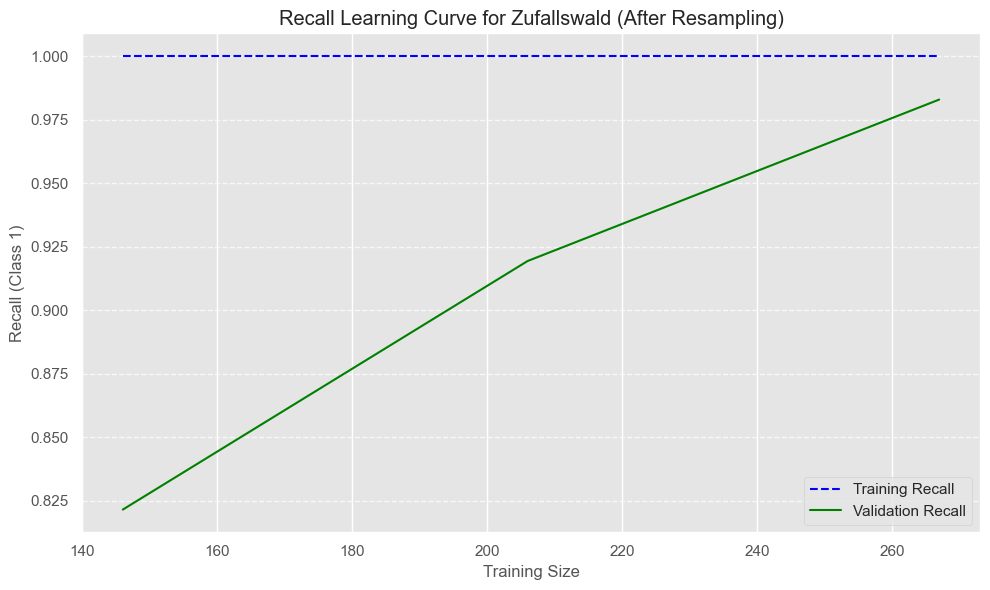


Plotting Learning Curve for XGBoost...


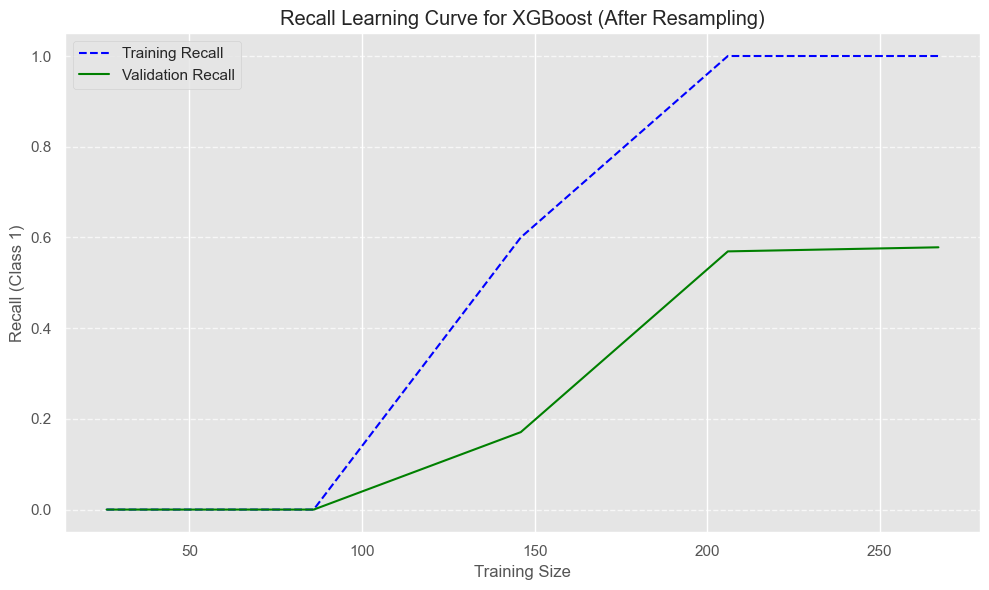

In [3418]:
# Modelle bewerten und Metriken für beide Klassen berechnen
results_rsmpl_1 = []

# Modelle evaluieren
for model_name, model in rsmpl_models.items():
    # Vorhersage für Training und Test
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training Recall
    train_recall = recall_score(y_train, y_train_pred, pos_label=1)
    # Test Recall
    test_recall = recall_score(y_test, y_test_pred, pos_label=1)

    # Ergebnisse speichern
    results_rsmpl_1.append({'Model': f"{model_name} (Class 1)", 'Metric': 'Training Recall', 'Value': train_recall})
    results_rsmpl_1.append({'Model': f"{model_name} (Class 1)", 'Metric': 'Test Recall', 'Value': test_recall})

# Convert results to DataFrame for better comparison
comparison_df_rsmpl = pd.DataFrame(results_rsmpl_1)

# Plot model performance comparison (all recall metrics for resampled models by class)
plt.figure(figsize=(16, 10))
sns.barplot(data=comparison_df_rsmpl, x="Model", y="Value", hue="Metric", palette="Set2", dodge=True)
plt.title("Model Performance Comparison (Recall - Resampled Models)", fontsize=16)
plt.ylabel("Recall (Class 1)", fontsize=14)
plt.xlabel("Models", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Metrics", loc="upper right", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Learning Curve für Recall
for model_name, model in rsmpl_models.items():
    print(f"\nPlotting Learning Curve for {model_name}...")

    # Learning curve for Recall (Class 1)
    train_sizes_recall, train_scores_recall, validation_scores_recall = learning_curve(
        model, X_resampled_smote_enn, y_resampled_smote_enn, cv=5, scoring=make_scorer(recall_score, pos_label=1), n_jobs=-1
    )

    # Plot Recall Learning Curve
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes_recall, train_scores_recall.mean(axis=1), label='Training Recall', linestyle='--', color='blue')
    plt.plot(train_sizes_recall, validation_scores_recall.mean(axis=1), label='Validation Recall', color='green')
    plt.xlabel('Training Size')
    plt.ylabel('Recall (Class 1)')
    plt.title(f'Recall Learning Curve for {model_name} (After Resampling)')
    plt.legend(loc='best')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [3419]:
# Hyperparameter-Raster definieren
param_grid_rsmpl = {
    'Entscheidungsbaum': {
        'max_depth': [5, 10, 15, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Zufallswald': {
        'n_estimators': [100, 150, 200],
        'max_depth': [10, 20, 30, 50],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 6, 9, 12],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.7, 1.0],
        'colsample_bytree': [0.7, 1.0],
    },
}

# Modelle definieren
models = {
    'Entscheidungsbaum': DecisionTreeClassifier(random_state=42),
    'Zufallswald': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
}

# Hyperparameter-Optimierung mit GridSearchCV durchführen
rsmpl_best_models = {}

for model_name, model in models.items():
    print(f"GridSearchCV für {model_name}...")

    # GridSearchCV initialisieren
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid_rsmpl[model_name],
        cv=5,
        scoring=make_scorer(f1_score, pos_label=1),  # F1-Score für Klasse 1
        verbose=1,
        n_jobs=-1
    )

    # GridSearchCV mit den resampleten Daten anpassen
    grid_search.fit(X_resampled_smote_enn, y_resampled_smote_enn)

    # Das beste Modell speichern
    rsmpl_best_models[model_name] = grid_search.best_estimator_

    print(f"Beste Parameter für {model_name}: {grid_search.best_params_}")
    print(f"Beste F1-Score für {model_name}: {grid_search.best_score_}\n")

# Die besten Modelle sind jetzt im 'rsmpl_best_models'-Dictionary gespeichert


GridSearchCV für Entscheidungsbaum...
Fitting 5 folds for each of 45 candidates, totalling 225 fits
Beste Parameter für Entscheidungsbaum: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Beste F1-Score für Entscheidungsbaum: 0.971477509506024

GridSearchCV für Zufallswald...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Beste Parameter für Zufallswald: {'bootstrap': False, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Beste F1-Score für Zufallswald: 0.983330117692456

GridSearchCV für XGBoost...
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Beste Parameter für XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.7}
Beste F1-Score für XGBoost: 0.5954429794124451




Visualisierung von Entscheidungsbaum...


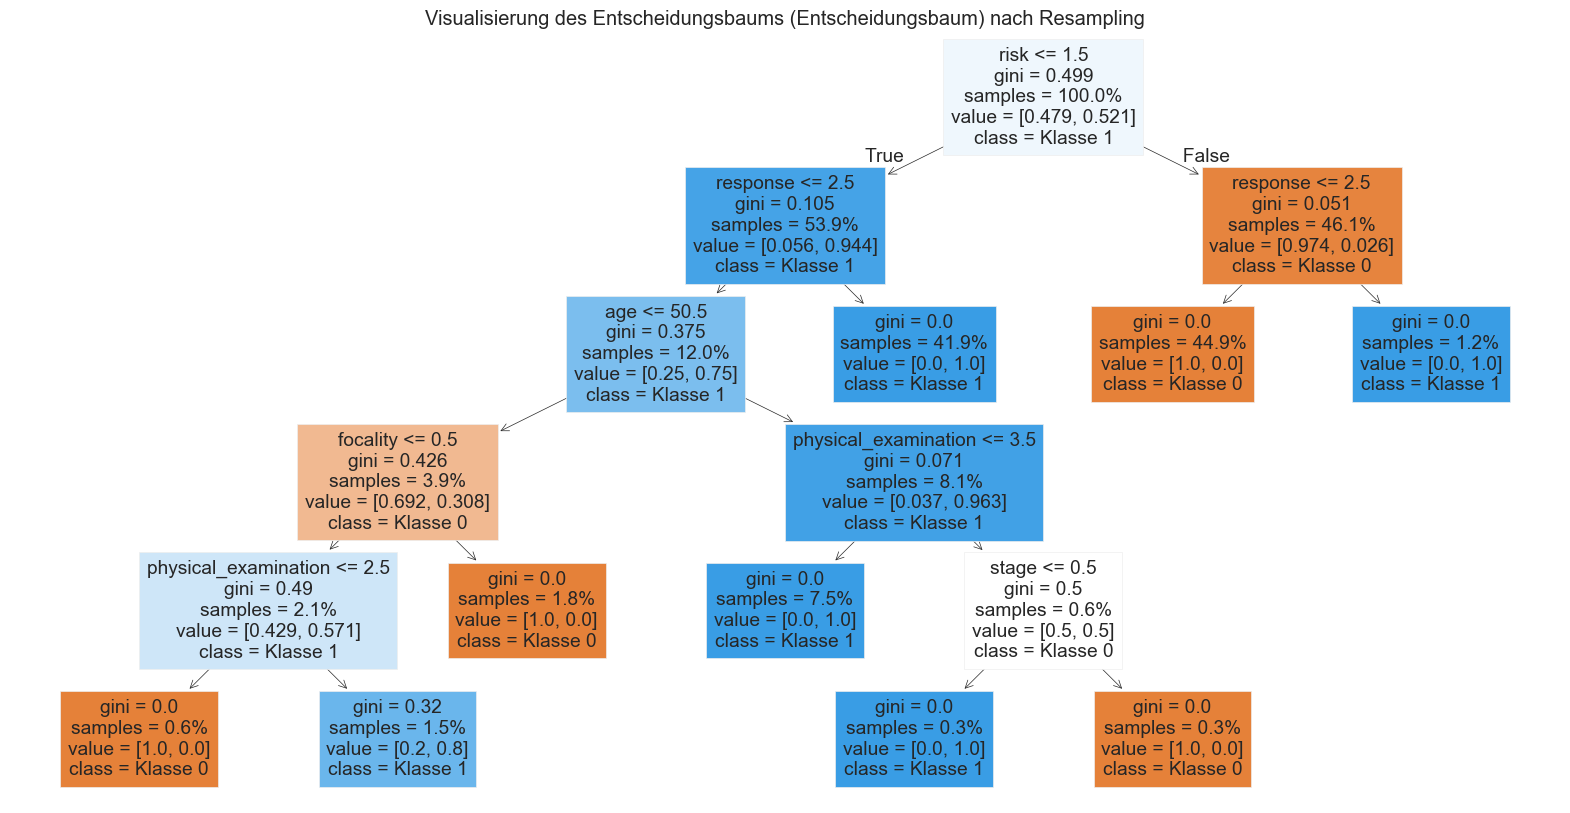


Visualisierung von Zufallswald...


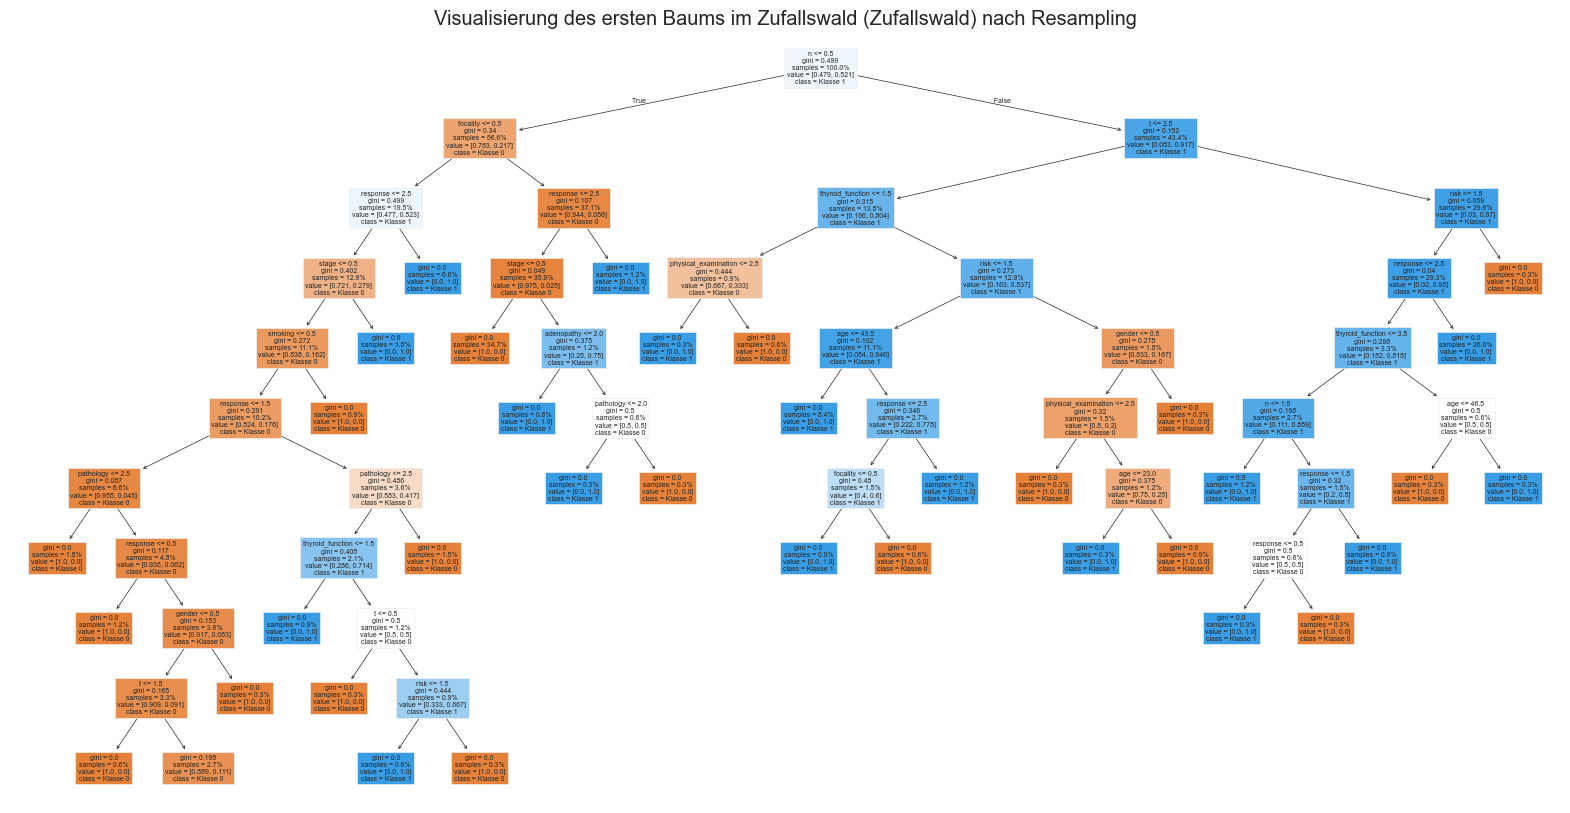


Visualisierung von XGBoost...


<Figure size 2000x1000 with 0 Axes>

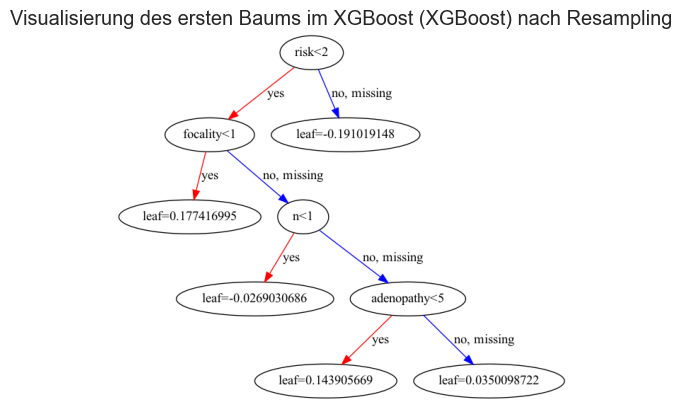

In [3420]:
# Modellvisualisierung Funktion
def plot_best_models_after_resampling(rsmpl_best_models, feature_names, class_names):
    for model_name, model in rsmpl_best_models.items():
        print(f"\nVisualisierung von {model_name}...")

        # Entscheidungsbaum: Visualisierung des Baums
        if isinstance(model, DecisionTreeClassifier):
            plt.figure(figsize=(20, 10))
            plot_tree(
                model,
                filled=True,
                feature_names=feature_names,
                class_names=class_names,
                proportion=True
            )
            plt.title(f'Visualisierung des Entscheidungsbaums ({model_name}) nach Resampling')
            plt.show()

        # Zufallswald: Visualisierung eines Baums im Wald
        elif isinstance(model, RandomForestClassifier):
            tree_to_plot = model.estimators_[0]  # Den ersten Baum im Wald holen
            plt.figure(figsize=(20, 10))
            plot_tree(
                tree_to_plot,
                filled=True,
                feature_names=feature_names,
                class_names=class_names,
                proportion=True
            )
            plt.title(f'Visualisierung des ersten Baums im Zufallswald ({model_name}) nach Resampling')
            plt.show()

        # XGBoost: Visualisierung eines Baums aus XGBoost
        elif isinstance(model, XGBClassifier):
            plt.figure(figsize=(20, 10))
            xgb.plot_tree(model, num_trees=0, fmap='', ax=None)  # Den ersten Baum plotten
            plt.title(f'Visualisierung des ersten Baums im XGBoost ({model_name}) nach Resampling')
            plt.show()

# Merkmale und Klassennamen definieren
feature_names = X_resampled_smote_enn.columns.tolist()  # Den Namen der Merkmale verwenden
class_names = ["Klasse 0", "Klasse 1"]  # Klassennamen anpassen

# Modelle visualisieren
plot_best_models_after_resampling(rsmpl_best_models, feature_names, class_names)


In [3421]:
# Modelle evaluieren nach Hyperparameter Tuning und Resampling
for model_name, model in rsmpl_best_models.items():
    print(f"\nEvaluierung von {model_name} nach Hyperparameter Tuning und Resampling...")

    # Training Set auf Vorhersagen machen
    y_train_pred = model.predict(X_train)  # Vorhersagen für Trainingsdaten
    train_f1 = f1_score(y_train, y_train_pred, pos_label=1)  # F1-Score für Klasse 1 berechnen

    # Test Set auf Vorhersagen machen
    y_test_pred = model.predict(X_test)  # Vorhersagen für Testdaten
    test_f1 = f1_score(y_test, y_test_pred, pos_label=1)  # F1-Score für Klasse 1 berechnen

    # F1-Score für Training und Test ausgeben
    print(f"F1-Score für Training bei {model_name} (Klasse 1): {train_f1:.4f}")
    print(f"F1-Score für Test bei {model_name} (Klasse 1): {test_f1:.4f}")



Evaluierung von Entscheidungsbaum nach Hyperparameter Tuning und Resampling...
F1-Score für Training bei Entscheidungsbaum (Klasse 1): 0.9036
F1-Score für Test bei Entscheidungsbaum (Klasse 1): 0.8727

Evaluierung von Zufallswald nach Hyperparameter Tuning und Resampling...
F1-Score für Training bei Zufallswald (Klasse 1): 0.8862
F1-Score für Test bei Zufallswald (Klasse 1): 0.9259

Evaluierung von XGBoost nach Hyperparameter Tuning und Resampling...
F1-Score für Training bei XGBoost (Klasse 1): 0.8994
F1-Score für Test bei XGBoost (Klasse 1): 0.9091



Generiere F1-Score Kurve für Decision Tree...


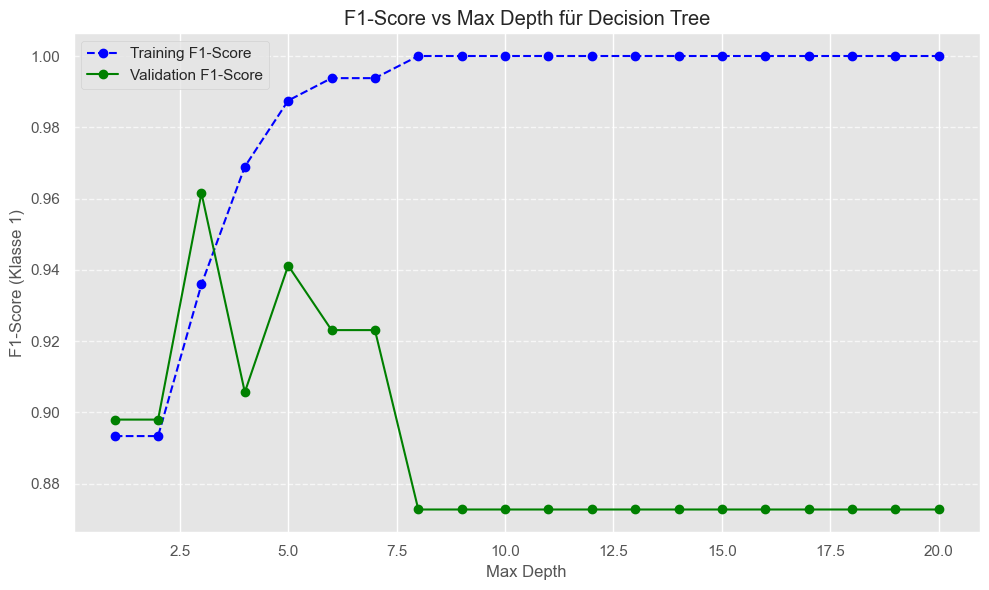


Generiere F1-Score Kurve für Random Forest...


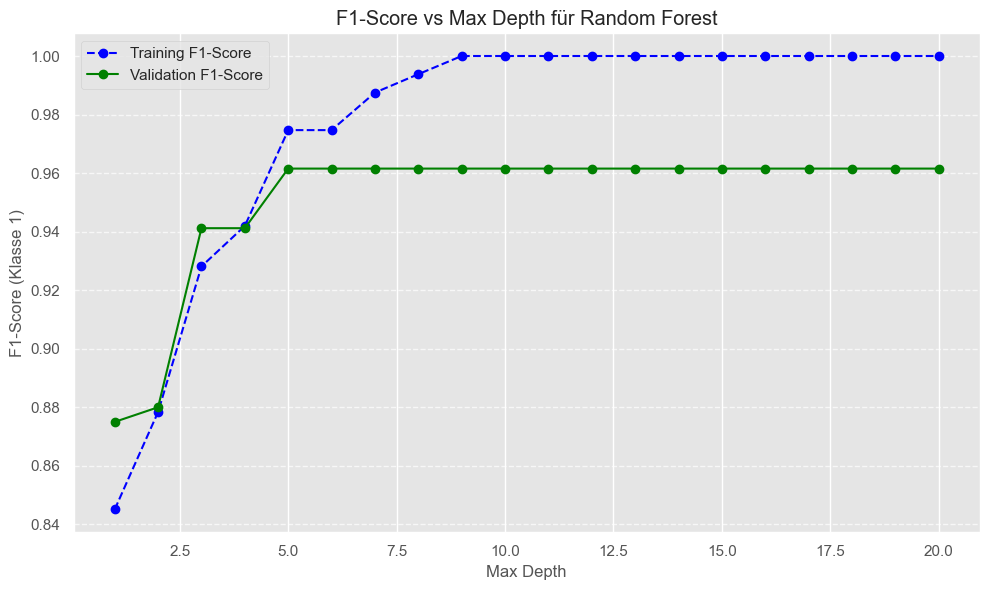


Generiere F1-Score Kurve für XGBoost...


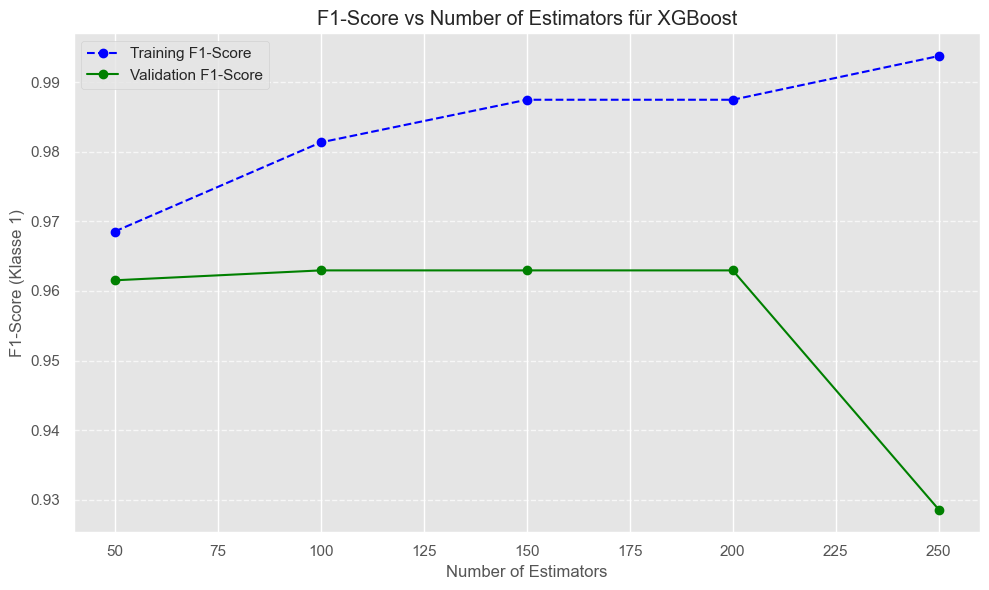

In [3422]:
# Funktion zum Plotten von F1-Score vs max_depth für Entscheidungsbaum und Zufallswald
def plot_max_depth_vs_f1(models, X_train, y_train, X_test, y_test):
    for model_name, best_model in models.items():
        if isinstance(best_model, (DecisionTreeClassifier, RandomForestClassifier)):
            print(f"\nGeneriere F1-Score Kurve für {model_name}...")

            # max_depth Bereich definieren
            max_depth_range = range(1, 21)
            training_f1_scores = []
            validation_f1_scores = []

            for max_depth in max_depth_range:
                # Modell mit aktuellem max_depth aktualisieren und anpassen
                model = best_model.set_params(max_depth=max_depth)
                model.fit(X_train, y_train)

                # F1-Score für Klasse 1 berechnen
                train_f1 = f1_score(y_train, model.predict(X_train), pos_label=1)
                val_f1 = f1_score(y_test, model.predict(X_test), pos_label=1)

                training_f1_scores.append(train_f1)
                validation_f1_scores.append(val_f1)

            # F1-Score vs max_depth plotten
            plt.figure(figsize=(10, 6))
            plt.plot(max_depth_range, training_f1_scores, label='Training F1-Score', linestyle='--', marker='o', color='blue')
            plt.plot(max_depth_range, validation_f1_scores, label='Validation F1-Score', marker='o', color='green')
            plt.xlabel('Max Depth')
            plt.ylabel('F1-Score (Klasse 1)')
            plt.title(f'F1-Score vs Max Depth für {model_name}')
            plt.legend(loc='best')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()

# Funktion zum Plotten von F1-Score vs n_estimators für XGBoost
def plot_n_estimators_vs_f1(models, X_train, y_train, X_test, y_test):
    for model_name, best_model in models.items():
        if isinstance(best_model, XGBClassifier):
            print(f"\nGeneriere F1-Score Kurve für {model_name}...")

            # n_estimators Bereich definieren
            n_estimators_range = [50, 100, 150, 200, 250]
            training_f1_scores = []
            validation_f1_scores = []

            for n_estimators in n_estimators_range:
                # Modell mit aktuellem n_estimators aktualisieren und anpassen
                model = best_model.set_params(n_estimators=n_estimators)
                model.fit(X_train, y_train)

                # F1-Score für Klasse 1 berechnen
                train_f1 = f1_score(y_train, model.predict(X_train), pos_label=1)
                val_f1 = f1_score(y_test, model.predict(X_test), pos_label=1)

                training_f1_scores.append(train_f1)
                validation_f1_scores.append(val_f1)

            # F1-Score vs n_estimators plotten
            plt.figure(figsize=(10, 6))
            plt.plot(n_estimators_range, training_f1_scores, label='Training F1-Score', linestyle='--', marker='o', color='blue')
            plt.plot(n_estimators_range, validation_f1_scores, label='Validation F1-Score', marker='o', color='green')
            plt.xlabel('Number of Estimators')
            plt.ylabel('F1-Score (Klasse 1)')
            plt.title(f'F1-Score vs Number of Estimators für {model_name}')
            plt.legend(loc='best')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()

# Funktionen aufrufen
plot_max_depth_vs_f1(best_models, X_train, y_train, X_test, y_test)
plot_n_estimators_vs_f1(best_models, X_train, y_train, X_test, y_test)


In [3423]:
# Stratified K-Fold Cross-Validation nach Resampling und Hyperparameter Tuning einrichten
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Durch jedes resamplete Modell iterieren und Stratified K-Fold Cross-Validation durchführen
for model_name, model in rsmpl_best_models.items():
    print(f"\nDurchführung der Stratified Cross-Validation für {model_name} nach Resampling und Hyperparameter Tuning...")

    # Cross-Validation mit F1-Score für Klasse 1 durchführen
    cross_val_scores = cross_val_score(
        model, X_train, y_train,
        cv=stratified_kfold,
        scoring=make_scorer(f1_score, pos_label=1)
    )

    # Ergebnisse für das aktuelle Modell ausgeben
    print(f"Stratified Cross-Validation F1-Scores für {model_name}: {cross_val_scores}")
    print(f"Durchschnittlicher Stratified Cross-Validation F1-Score für {model_name}: {cross_val_scores.mean():.4f}")



Durchführung der Stratified Cross-Validation für Entscheidungsbaum nach Resampling und Hyperparameter Tuning...
Stratified Cross-Validation F1-Scores für Entscheidungsbaum: [0.70588235 0.875      0.89655172 0.82758621 0.9375    ]
Durchschnittlicher Stratified Cross-Validation F1-Score für Entscheidungsbaum: 0.8485

Durchführung der Stratified Cross-Validation für Zufallswald nach Resampling und Hyperparameter Tuning...
Stratified Cross-Validation F1-Scores für Zufallswald: [0.73333333 0.96969697 0.93333333 0.93333333 0.9375    ]
Durchschnittlicher Stratified Cross-Validation F1-Score für Zufallswald: 0.9014

Durchführung der Stratified Cross-Validation für XGBoost nach Resampling und Hyperparameter Tuning...
Stratified Cross-Validation F1-Scores für XGBoost: [0.70967742 0.97142857 0.93333333 0.89655172 0.9375    ]
Durchschnittlicher Stratified Cross-Validation F1-Score für XGBoost: 0.8897



Feature Importance für Entscheidungsbaum nach Resampling:
                 Feature  Importance
10                  risk    0.848091
15              response    0.070749
0                    age    0.045641
6   physical_examination    0.016683
9               focality    0.012779
14                 stage    0.006057
1                 gender    0.000000
2                smoking    0.000000
3             hx_smoking    0.000000
4        hx_radiothreapy    0.000000
5       thyroid_function    0.000000
7             adenopathy    0.000000
8              pathology    0.000000
11                     t    0.000000
12                     n    0.000000
13                     m    0.000000


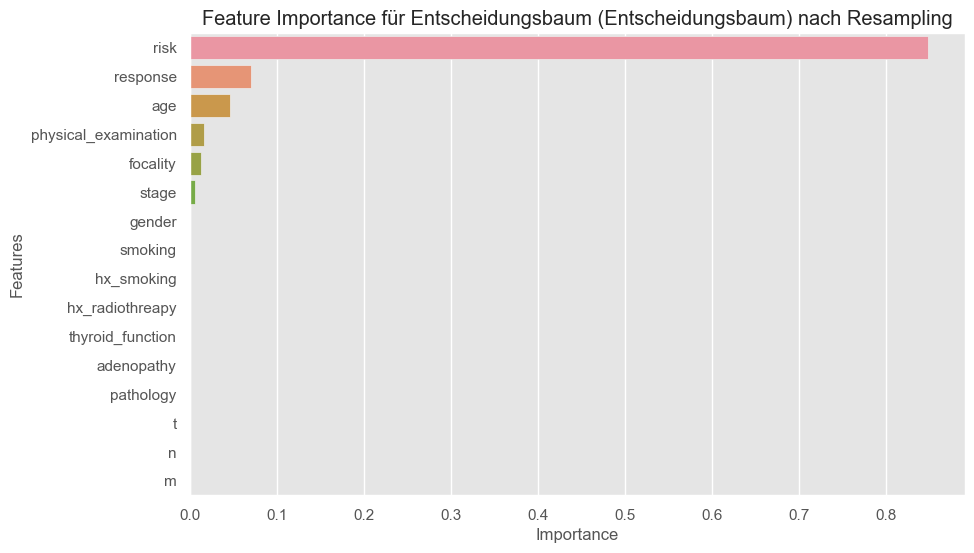


Feature Importance für Zufallswald nach Resampling:
                 Feature    Importance
10                  risk  3.611362e-01
15              response  2.458493e-01
12                     n  1.271329e-01
9               focality  7.638085e-02
0                    age  5.366614e-02
7             adenopathy  4.124995e-02
11                     t  3.703719e-02
14                 stage  3.185893e-02
6   physical_examination  1.061748e-02
8              pathology  4.567720e-03
2                smoking  3.606705e-03
1                 gender  3.099368e-03
5       thyroid_function  3.074122e-03
13                     m  5.465014e-04
3             hx_smoking  1.767086e-04
4        hx_radiothreapy  5.243958e-09


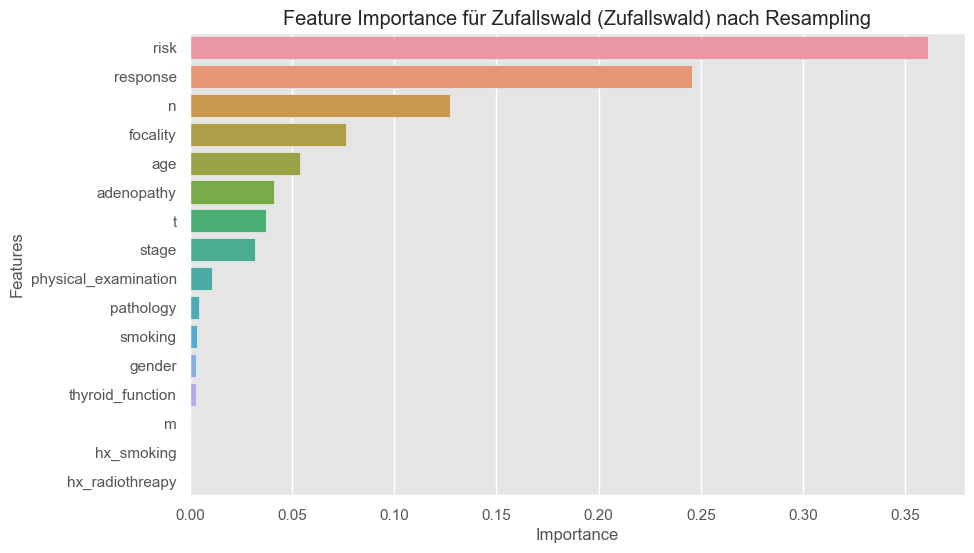


Feature Importance für XGBoost nach Resampling:
                 Feature  Importance
10                  risk    0.556128
15              response    0.149015
12                     n    0.068940
7             adenopathy    0.046119
14                 stage    0.044143
0                    age    0.038124
9               focality    0.034229
11                     t    0.021708
1                 gender    0.016721
6   physical_examination    0.012970
8              pathology    0.010899
5       thyroid_function    0.001004
2                smoking    0.000000
3             hx_smoking    0.000000
4        hx_radiothreapy    0.000000
13                     m    0.000000


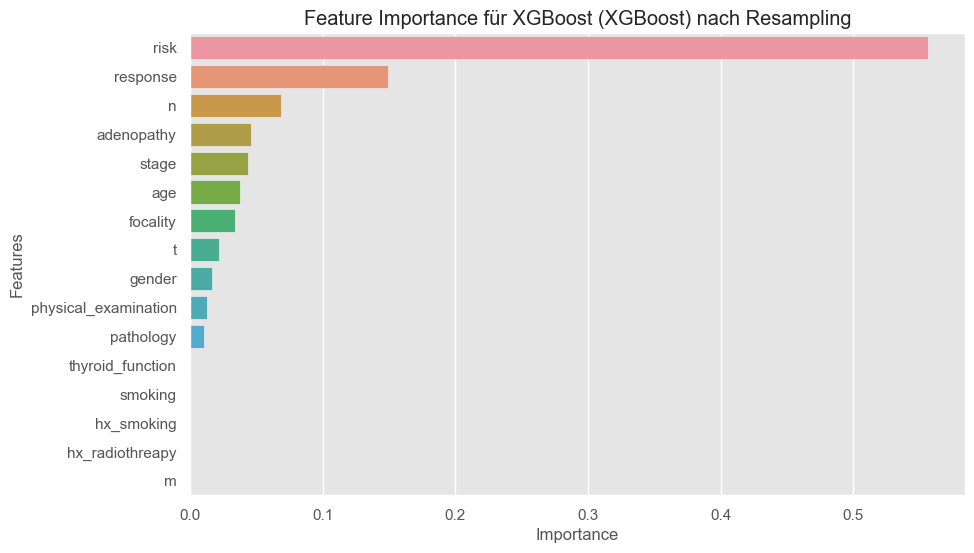

In [3424]:
# Funktion zum Plotten und Drucken der Feature Importance nach Resampling und Hyperparameter Tuning
def plot_and_print_feature_importance_after_resampling(rsmpl_best_models, X_resampled_smote_enn):
    for model_name, model in rsmpl_best_models.items():
        print(f"\nFeature Importance für {model_name} nach Resampling:")

        # Entscheidungsbaum: Feature Importance drucken und plotten
        if isinstance(model, DecisionTreeClassifier):
            feature_importance = model.feature_importances_

            # DataFrame für Feature Importance erstellen
            importance_df = pd.DataFrame({
                'Feature': X_resampled_smote_enn.columns,
                'Importance': feature_importance
            }).sort_values(by='Importance', ascending=False)

            # Feature Importance drucken
            print(importance_df)

            # Feature Importance plotten
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Importance', y='Feature', data=importance_df)
            plt.title(f'Feature Importance für {model_name} (Entscheidungsbaum) nach Resampling')
            plt.xlabel('Importance')
            plt.ylabel('Features')
            plt.show()

        # Zufallswald: Feature Importance drucken und plotten
        elif isinstance(model, RandomForestClassifier):
            feature_importance = model.feature_importances_

            # DataFrame für Feature Importance erstellen
            importance_df = pd.DataFrame({
                'Feature': X_resampled_smote_enn.columns,
                'Importance': feature_importance
            }).sort_values(by='Importance', ascending=False)

            # Feature Importance drucken
            print(importance_df)

            # Feature Importance plotten
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Importance', y='Feature', data=importance_df)
            plt.title(f'Feature Importance für {model_name} (Zufallswald) nach Resampling')
            plt.xlabel('Importance')
            plt.ylabel('Features')
            plt.show()

        # XGBoost: Feature Importance drucken und plotten
        elif isinstance(model, XGBClassifier):
            feature_importance = model.feature_importances_
            feature_names = X_resampled_smote_enn.columns

            # DataFrame für Feature Importance erstellen
            importance_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': feature_importance
            }).sort_values(by='Importance', ascending=False)

            # Feature Importance drucken
            print(importance_df)

            # Feature Importance plotten
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Importance', y='Feature', data=importance_df)
            plt.title(f'Feature Importance für {model_name} (XGBoost) nach Resampling')
            plt.xlabel('Importance')
            plt.ylabel('Features')
            plt.show()


plot_and_print_feature_importance_after_resampling(rsmpl_best_models, X_resampled_smote_enn)



📌 Bewertung von Decision Tree...

🎯 Genauigkeit für Decision Tree: 0.9271
🧾 Klassifikationsbericht:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        69
           1       0.86      0.89      0.87        27

    accuracy                           0.93        96
   macro avg       0.91      0.92      0.91        96
weighted avg       0.93      0.93      0.93        96

📉 Konfusionsmatrix:
[[65  4]
 [ 3 24]]


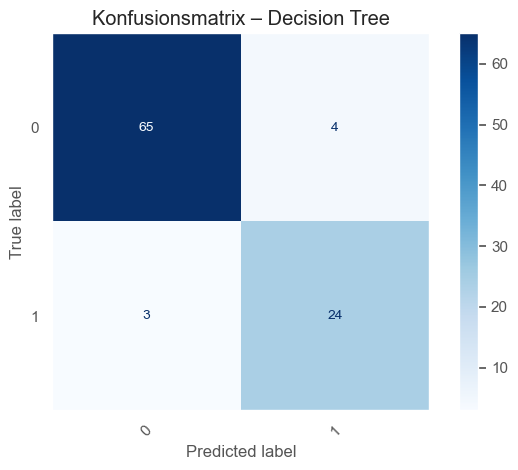


📌 Bewertung von Random Forest...

🎯 Genauigkeit für Random Forest: 0.9792
🧾 Klassifikationsbericht:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        69
           1       1.00      0.93      0.96        27

    accuracy                           0.98        96
   macro avg       0.99      0.96      0.97        96
weighted avg       0.98      0.98      0.98        96

📉 Konfusionsmatrix:
[[69  0]
 [ 2 25]]


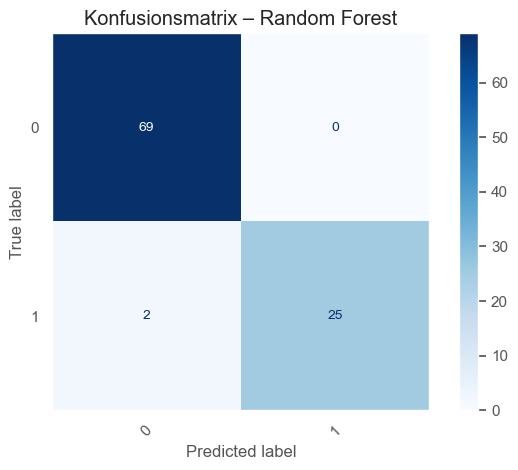


📌 Bewertung von XGBoost...

🎯 Genauigkeit für XGBoost: 0.9583
🧾 Klassifikationsbericht:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        69
           1       0.90      0.96      0.93        27

    accuracy                           0.96        96
   macro avg       0.94      0.96      0.95        96
weighted avg       0.96      0.96      0.96        96

📉 Konfusionsmatrix:
[[66  3]
 [ 1 26]]


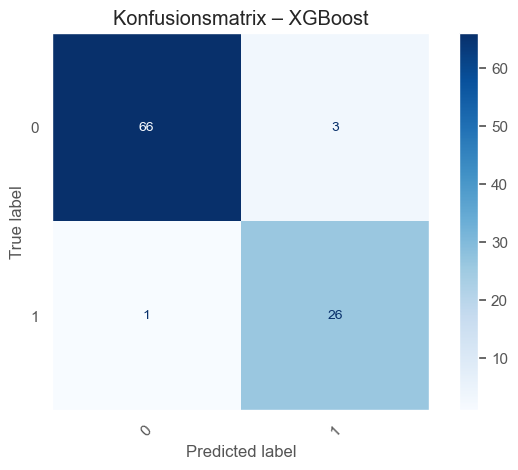

In [3425]:
#  Funktion zur Bewertung der getunten Modelle
def bewerte_getunte_modelle(best_models, X_test, y_test):
    bewertungen = {}

    for name, modell in best_models.items():
        print(f"\n Bewertung von {name}...")

        #  Vorhersagen für Testdaten
        y_pred = modell.predict(X_test)

        #  Metriken berechnen
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        # Ergebnisse speichern
        bewertungen[name] = {
            'Genauigkeit': accuracy,
            'Präzision': precision,
            'Recall': recall,
            'F1-Score': f1
        }

        # Klassifikationsbericht anzeigen
        print(f"\n Genauigkeit für {name}: {accuracy:.4f}")
        print(" Klassifikationsbericht:")
        print(classification_report(y_test, y_pred))

        # Konfusionsmatrix berechnen und anzeigen
        print(" Konfusionsmatrix:")
        cm = confusion_matrix(y_test, y_pred)
        print(cm)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modell.classes_)
        disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
        plt.title(f"Konfusionsmatrix – {name}")
        plt.grid(False)
        plt.tight_layout()
        plt.show()

    return bewertungen

#  Funktion ausführen
bewertungsergebnisse = bewerte_getunte_modelle(best_models, X_test, y_test)


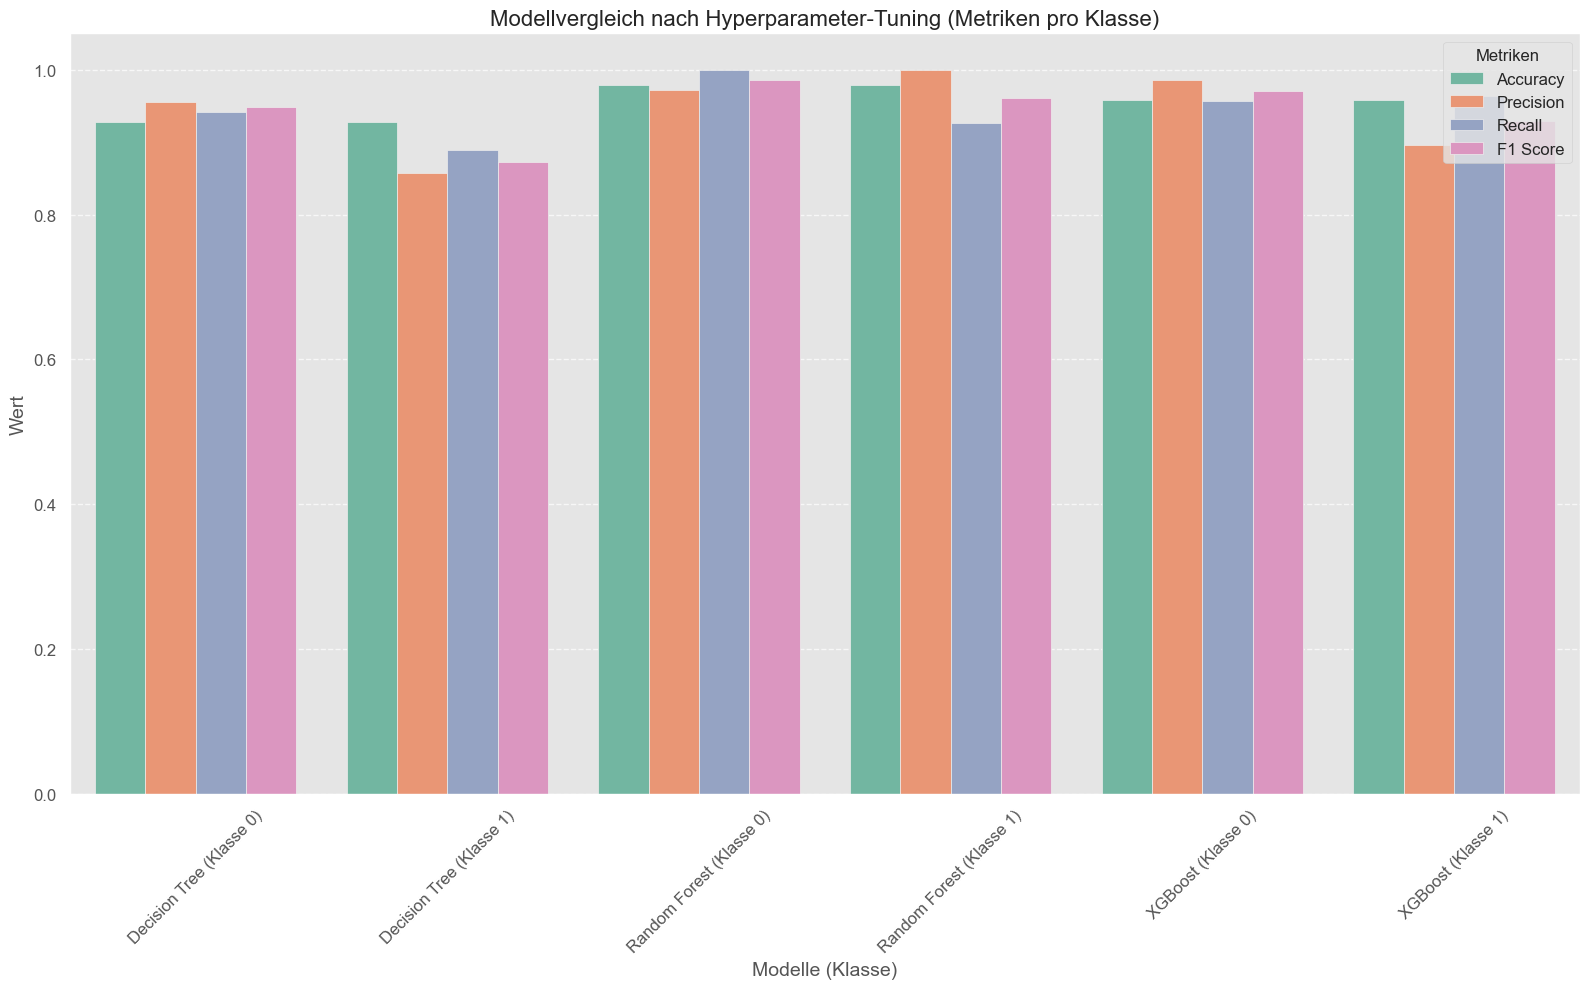


📋 Detaillierte Metriken pro Modell und Klasse nach Tuning:
                      Modell     Metrik      Wert
0   Decision Tree (Klasse 0)   Accuracy  0.927083
1   Decision Tree (Klasse 0)  Precision  0.955882
2   Decision Tree (Klasse 0)     Recall  0.942029
3   Decision Tree (Klasse 0)   F1 Score  0.948905
4   Decision Tree (Klasse 1)   Accuracy  0.927083
5   Decision Tree (Klasse 1)  Precision  0.857143
6   Decision Tree (Klasse 1)     Recall  0.888889
7   Decision Tree (Klasse 1)   F1 Score  0.872727
8   Random Forest (Klasse 0)   Accuracy  0.979167
9   Random Forest (Klasse 0)  Precision  0.971831
10  Random Forest (Klasse 0)     Recall  1.000000
11  Random Forest (Klasse 0)   F1 Score  0.985714
12  Random Forest (Klasse 1)   Accuracy  0.979167
13  Random Forest (Klasse 1)  Precision  1.000000
14  Random Forest (Klasse 1)     Recall  0.925926
15  Random Forest (Klasse 1)   F1 Score  0.961538
16        XGBoost (Klasse 0)   Accuracy  0.958333
17        XGBoost (Klasse 0)  Precision 

In [3426]:
#  Liste zur Speicherung der Ergebnisse
results_2 = []

#  Jede Modellbewertung für Klasse 0 und Klasse 1
for modellname, modell in best_models.items():
    #  Vorhersagen auf Testdaten
    y_pred = modell.predict(X_test)

    #  Metriken für Klasse 0
    accuracy = accuracy_score(y_test, y_pred)
    precision_0 = precision_score(y_test, y_pred, pos_label=0)
    recall_0 = recall_score(y_test, y_pred, pos_label=0)
    f1_0 = f1_score(y_test, y_pred, pos_label=0)

    results_2.append({'Modell': f"{modellname} (Klasse 0)", 'Metrik': 'Accuracy', 'Wert': accuracy})
    results_2.append({'Modell': f"{modellname} (Klasse 0)", 'Metrik': 'Precision', 'Wert': precision_0})
    results_2.append({'Modell': f"{modellname} (Klasse 0)", 'Metrik': 'Recall', 'Wert': recall_0})
    results_2.append({'Modell': f"{modellname} (Klasse 0)", 'Metrik': 'F1 Score', 'Wert': f1_0})

    #  Metriken für Klasse 1
    precision_1 = precision_score(y_test, y_pred, pos_label=1)
    recall_1 = recall_score(y_test, y_pred, pos_label=1)
    f1_1 = f1_score(y_test, y_pred, pos_label=1)

    results_2.append({'Modell': f"{modellname} (Klasse 1)", 'Metrik': 'Accuracy', 'Wert': accuracy})  # gleiche Accuracy
    results_2.append({'Modell': f"{modellname} (Klasse 1)", 'Metrik': 'Precision', 'Wert': precision_1})
    results_2.append({'Modell': f"{modellname} (Klasse 1)", 'Metrik': 'Recall', 'Wert': recall_1})
    results_2.append({'Modell': f"{modellname} (Klasse 1)", 'Metrik': 'F1 Score', 'Wert': f1_1})

#  Ergebnisse als DataFrame
vergleich_df = pd.DataFrame(results_2)

#  Balkendiagramm der Modellmetriken
plt.figure(figsize=(16, 10))
sns.barplot(data=vergleich_df, x="Modell", y="Wert", hue="Metrik", palette="Set2", dodge=True)
plt.title("Modellvergleich nach Hyperparameter-Tuning (Metriken pro Klasse)", fontsize=16)
plt.ylabel("Wert", fontsize=14)
plt.xlabel("Modelle (Klasse)", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Metriken", loc="upper right", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#  Detaillierte Tabelle anzeigen
print("\n Detaillierte Metriken pro Modell und Klasse nach Tuning:")
print(vergleich_df)


In [3427]:
#  Iteration über die besten Modelle zur Bewertung von Recall (Klasse 1)
for modellname, bestes_modell in best_models.items():
    print(f"\n Bewertung von {modellname}...")

    #  Trainingsleistung (Recall für Klasse 1)
    y_train_pred = bestes_modell.predict(X_train)
    recall_train = recall_score(y_train, y_train_pred, pos_label=1)

    #  Testleistung (Recall für Klasse 1)
    y_test_pred = bestes_modell.predict(X_test)
    recall_test = recall_score(y_test, y_test_pred, pos_label=1)

    print(f" Trainings-Recall für {modellname} (Klasse 1): {recall_train:.4f}")
    print(f" Test-Recall für {modellname} (Klasse 1): {recall_test:.4f}")



🔍 Bewertung von Decision Tree...
📚 Trainings-Recall für Decision Tree (Klasse 1): 1.0000
🧪 Test-Recall für Decision Tree (Klasse 1): 0.8889

🔍 Bewertung von Random Forest...
📚 Trainings-Recall für Random Forest (Klasse 1): 1.0000
🧪 Test-Recall für Random Forest (Klasse 1): 0.9259

🔍 Bewertung von XGBoost...
📚 Trainings-Recall für XGBoost (Klasse 1): 0.9877
🧪 Test-Recall für XGBoost (Klasse 1): 0.9630


In [3428]:
def recall_vs_max_depth(models, X_train, y_train, X_test, y_test):
    for name, model in models.items():
        if isinstance(model, (DecisionTreeClassifier, RandomForestClassifier)):
            print(f"\n Generiere Recall-Kurve für {name}...")

            max_depths = range(1, 21)
            train_recalls = []
            test_recalls = []

            for depth in max_depths:
                model.set_params(max_depth=depth).fit(X_train, y_train)
                train_r = recall_score(y_train, model.predict(X_train), pos_label=1)
                test_r = recall_score(y_test, model.predict(X_test), pos_label=1)
                train_recalls.append(train_r)
                test_recalls.append(test_r)

            plt.figure(figsize=(10, 6))
            plt.plot(max_depths, train_recalls, label='Train Recall', linestyle='--', marker='o')
            plt.plot(max_depths, test_recalls, label='Test Recall', marker='o')
            plt.title(f'Recall vs Max Depth für {name}')
            plt.xlabel('Max Depth')
            plt.ylabel('Recall (Klasse 1: Rückfall)')
            plt.legend()
            plt.grid(alpha=0.7)
            plt.tight_layout()
            plt.show()


In [3429]:
def recall_vs_estimators(models, X_train, y_train, X_test, y_test):
    for name, model in models.items():
        if isinstance(model, XGBClassifier):
            print(f"\n Generiere Recall-Kurve für {name}...")

            n_range = [50, 100, 150, 200, 250]
            train_recalls = []
            test_recalls = []

            for n in n_range:
                model.set_params(n_estimators=n).fit(X_train, y_train)
                train_r = recall_score(y_train, model.predict(X_train), pos_label=1)
                test_r = recall_score(y_test, model.predict(X_test), pos_label=1)
                train_recalls.append(train_r)
                test_recalls.append(test_r)

            plt.figure(figsize=(10, 6))
            plt.plot(n_range, train_recalls, label='Train Recall', linestyle='--', marker='o')
            plt.plot(n_range, test_recalls, label='Test Recall', marker='o')
            plt.title(f'Recall vs n_estimators für {name}')
            plt.xlabel('Anzahl der Bäume')
            plt.ylabel('Recall (Klasse 1: Rückfall)')
            plt.legend()
            plt.grid(alpha=0.7)
            plt.tight_layout()
            plt.show()



📈 Generiere Recall-Kurve für Decision Tree...


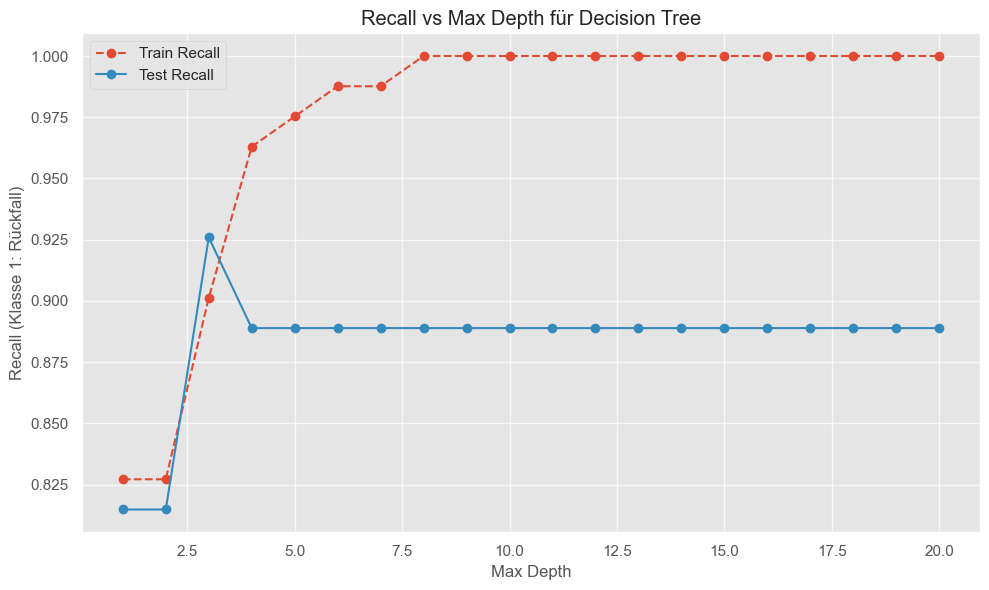


📈 Generiere Recall-Kurve für Random Forest...


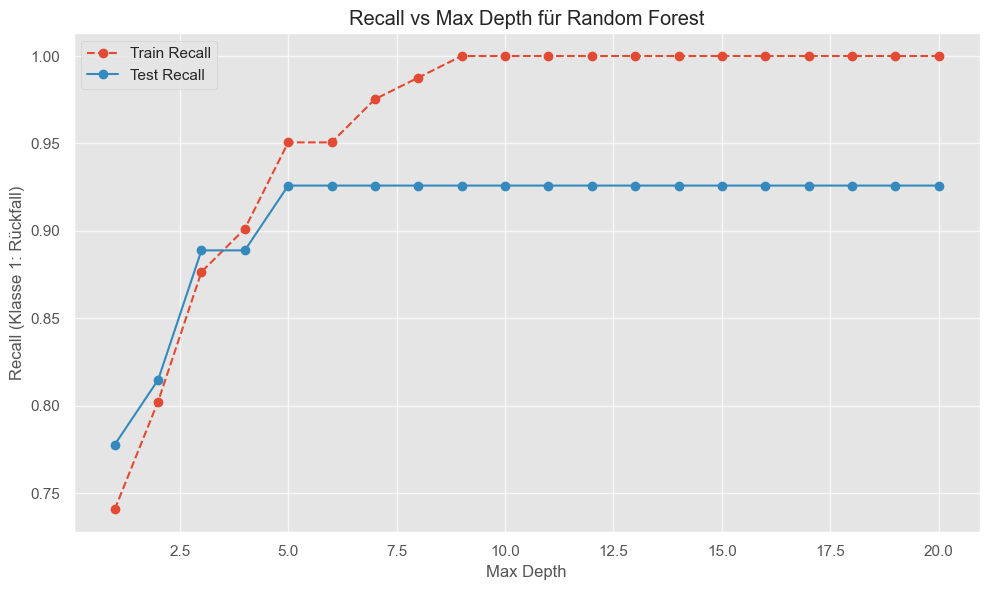


📈 Generiere Recall-Kurve für XGBoost...


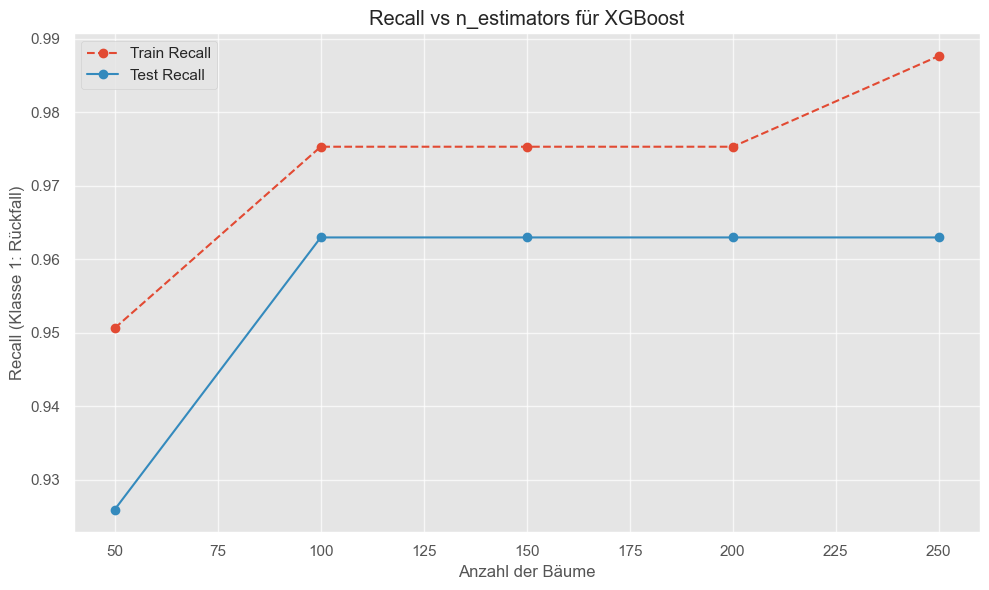

In [3430]:
recall_vs_max_depth(best_models, X_train, y_train, X_test, y_test)
recall_vs_estimators(best_models, X_train, y_train, X_test, y_test)


In [3431]:
#  Stratified Cross-Validation nach Tuning
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n Stratified Cross-Validation Ergebnisse (Recall, Klasse 1):")
for modell_name, modell in best_models.items():
    print(f"\n Modell: {modell_name}")

    scores = cross_val_score(
        modell,
        X_train,
        y_train,
        cv=stratified_kfold,
        scoring=make_scorer(recall_score, pos_label=1)
    )

    print(f"Cross-Validation Scores (Recall): {scores}")
    print(f"Durchschnittlicher Recall: {scores.mean():.4f}")



📋 Stratified Cross-Validation Ergebnisse (Recall, Klasse 1):

🔍 Modell: Decision Tree
Cross-Validation Scores (Recall): [0.75       0.76470588 0.8125     0.75       0.9375    ]
Durchschnittlicher Recall: 0.8029

🔍 Modell: Random Forest
Cross-Validation Scores (Recall): [0.6875 1.     0.875  0.8125 0.9375]
Durchschnittlicher Recall: 0.8625

🔍 Modell: XGBoost
Cross-Validation Scores (Recall): [0.6875     0.94117647 0.875      0.8125     0.9375    ]
Durchschnittlicher Recall: 0.8507


In [3432]:
#  Visualisierung der wichtigsten Merkmale
def zeige_feature_importanz(modelle, X_train, modell_namen):
    for name in modell_namen:
        modell = modelle[name]

        # Für Entscheidungsbaum & Random Forest
        if isinstance(modell, (DecisionTreeClassifier, RandomForestClassifier)):
            wichtigkeit = modell.feature_importances_
            wichtigkeit_df = pd.DataFrame({
                'Merkmal': X_train.columns,
                'Wichtigkeit': wichtigkeit
            }).sort_values(by='Wichtigkeit', ascending=False)

            print(f"\n Wichtigkeit der Merkmale – {name}:")
            print(wichtigkeit_df)

            # Plot
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Wichtigkeit', y='Merkmal', data=wichtigkeit_df)
            plt.title(f'Merkmalswichtigkeit für {name}')
            plt.xlabel('Wichtigkeit')
            plt.ylabel('Merkmale')
            plt.tight_layout()
            plt.show()

        # Für XGBoost
        elif isinstance(modell, XGBClassifier):
            wichtigkeit = modell.feature_importances_
            wichtigkeit_df = pd.DataFrame({
                'Merkmal': X_train.columns,
                'Wichtigkeit': wichtigkeit
            }).sort_values(by='Wichtigkeit', ascending=False)

            print(f"\n Wichtigkeit der Merkmale – {name}:")
            print(wichtigkeit_df)

            plt.figure(figsize=(10, 6))
            sns.barplot(x='Wichtigkeit', y='Merkmal', data=wichtigkeit_df)
            plt.title(f'Merkmalswichtigkeit für {name}')
            plt.xlabel('Wichtigkeit')
            plt.ylabel('Merkmale')
            plt.tight_layout()
            plt.show()


In [3433]:
#  Auswahl der wichtigsten Merkmale
def get_important_features(best_models, X_train, threshold=0.01):
    feature_importance_scores = pd.DataFrame(0, index=X_train.columns, columns=['Decision Tree', 'Random Forest', 'XGBoost'])

    for model_name, model in best_models.items():
        if isinstance(model, (DecisionTreeClassifier, RandomForestClassifier)):
            importance = model.feature_importances_
            feature_importance_scores[model_name] = importance
        elif isinstance(model, XGBClassifier):
            importance = model.feature_importances_
            feature_importance_scores[model_name] = importance

    feature_importance_scores['Average'] = feature_importance_scores.mean(axis=1)
    selected = feature_importance_scores[feature_importance_scores['Average'] > threshold].index.tolist()

    print(f" Ausgewählte Merkmale:\n{selected}")
    return selected

#  Jetzt ausführen!
selected_features = get_important_features(best_models, X_train)


✅ Ausgewählte Merkmale:
['age', 'gender', 'smoking', 'thyroid_function', 'physical_examination', 'adenopathy', 'pathology', 'focality', 'risk', 't', 'n', 'stage', 'response']


In [3434]:
X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]


In [3435]:
#  Standardisieren
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

#  SMOTEENN Resampler
smote_enn = SMOTEENN(random_state=42)
X_resampled_smote_enn, y_resampled_smote_enn = smote_enn.fit_resample(X_train_scaled, y_train)

#  Neue Klassenverteilung
print(" Klassenverteilung nach SMOTE-ENN:")
print(Counter(y_resampled_smote_enn))


📌 Klassenverteilung nach SMOTE-ENN:
Counter({1: 179, 0: 173})


In [3436]:
# Skalierung
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# SMOTE-ENN anwenden
smote_enn = SMOTEENN(random_state=42)
X_resampled_smote_enn, y_resampled_smote_enn = smote_enn.fit_resample(X_train_scaled, y_train)

# Kontrolle
print(" Klassenverteilung nach SMOTE-ENN:")
print(Counter(y_resampled_smote_enn))


📌 Klassenverteilung nach SMOTE-ENN:
Counter({1: 179, 0: 173})


In [3437]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'random_state': [1]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    verbose=1
)

#  Modeli fit 
grid_search_rf.fit(X_train, y_train)


Fitting 5 folds for each of 81 candidates, totalling 405 fits


,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


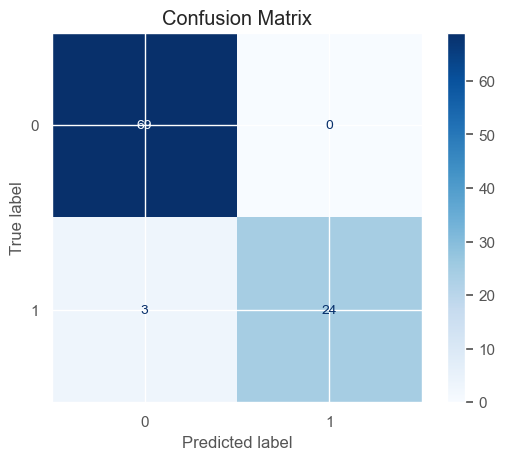

Klassifikationsbericht:
               precision    recall  f1-score   support

        Died       0.96      1.00      0.98        69
    Survived       1.00      0.89      0.94        27

    accuracy                           0.97        96
   macro avg       0.98      0.94      0.96        96
weighted avg       0.97      0.97      0.97        96



In [3438]:
y_pred_best_rf = grid_search_rf.best_estimator_.predict(X_test)

# Konfusionsmatrix
conf_matrix = confusion_matrix(y_test, y_pred_best_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Klassifikationsbericht
report = classification_report(y_test, y_pred_best_rf, target_names=['Died', 'Survived'])
print("Klassifikationsbericht:\n", report)


In [3439]:
#  Spalten prüfen
print("Spalten:", df.columns.tolist())

#  Zielspalte checken
if 'Recurred' not in df.columns:
    raise ValueError(" 'Recurred' Spalte nicht gefunden!")

#  Zielvariable binär machen
df['Recurred'] = df['Recurred'].map({'Yes': 1, 'No': 0})
df = df[df['Recurred'].notna()]  # NaNs filtern

#  Kategorische Spalten encodieren
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

#  Nachprüfen, ob Zeilen vorhanden
if df_encoded.shape[0] == 0:
    raise ValueError(" Der DataFrame ist nach dem Encoding leer! Bitte Eingabedaten prüfen.")

#  Features & Target
X = df_encoded.drop(columns=['Recurred'])
y = df_encoded['Recurred']

#  Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Spalten: ['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']


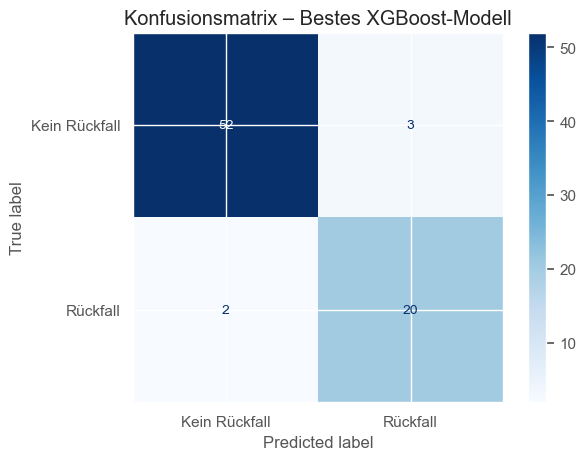

📋 Klassifikationsbericht für bestes XGBoost:

               precision    recall  f1-score   support

Kein Rückfall       0.96      0.95      0.95        55
     Rückfall       0.87      0.91      0.89        22

     accuracy                           0.94        77
    macro avg       0.92      0.93      0.92        77
 weighted avg       0.94      0.94      0.94        77



In [3447]:
df = pd.read_csv(file_path)

# Spaltennamen in Kleinbuchstaben umwandeln und Leerzeichen durch Unterstriche ersetzen
df.columns = df.columns.str.replace(' ', '_').str.lower()

# Trainings- und Testdatensätze auf gleiche Spaltennamen umstellen
X_train.columns = X_train.columns.str.replace(' ', '_').str.lower()
X_test.columns = X_test.columns.str.replace(' ', '_').str.lower()

# Testdatensatz mit den Spalten von X_train abgleichen
X_test = X_test[X_train.columns]

#  Vorhersagen mit dem besten XGBoost-Modell
y_pred_xgb = grid_search.best_estimator_.predict(X_test)

#  Konfusionsmatrix anzeigen
conf_matrix = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                              display_labels=['Kein Rückfall', 'Rückfall'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Konfusionsmatrix – Bestes XGBoost-Modell')
plt.show()

#  Klassifikationsbericht drucken
report_xgb = classification_report(
    y_test, y_pred_xgb,
    target_names=['Kein Rückfall', 'Rückfall']
)
print(" Klassifikationsbericht für bestes XGBoost:\n")
print(report_xgb)


In [3449]:
#  Daten aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Modelle definieren 
models = {
    'Logistische Regression': LogisticRegression(max_iter=200),
    'Entscheidungsbaum': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')  # binary classification
}

#  Modelle trainieren und bewerten
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    results[name] = accuracy

#  Ergebnisse anzeigen
print("´ Genauigkeitsvergleich der Modelle:")
for name, accuracy in results.items():
    print(f"{name}: Genauigkeit = {accuracy:.2f}")


📈 Genauigkeitsvergleich der Modelle:
Logistische Regression: Genauigkeit = 0.94
Entscheidungsbaum: Genauigkeit = 0.94
Random Forest: Genauigkeit = 0.99
XGBoost: Genauigkeit = 0.96


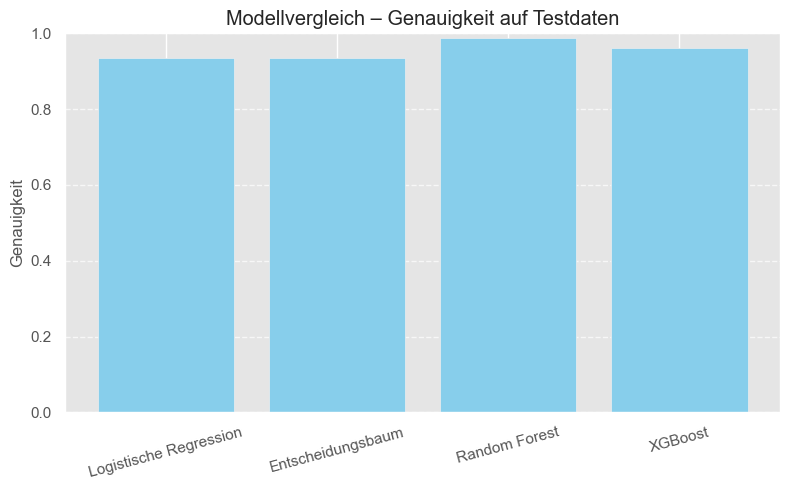

In [3451]:
# Plot
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.ylabel('Genauigkeit')
plt.title('Modellvergleich – Genauigkeit auf Testdaten')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Fitting 5 folds for each of 27 candidates, totalling 135 fits


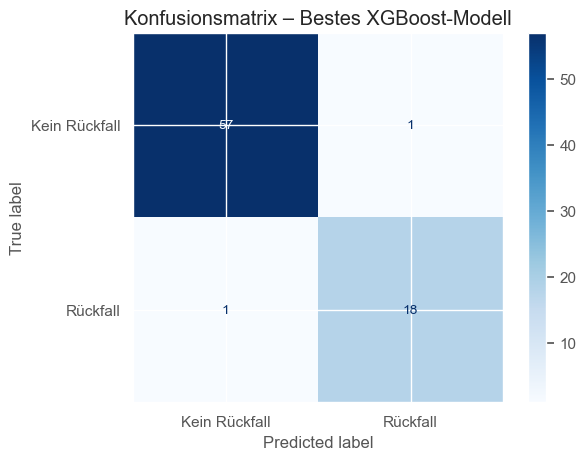

📋 Klassifikationsbericht für bestes XGBoost:

               precision    recall  f1-score   support

Kein Rückfall       0.98      0.98      0.98        58
     Rückfall       0.95      0.95      0.95        19

     accuracy                           0.97        77
    macro avg       0.97      0.97      0.97        77
 weighted avg       0.97      0.97      0.97        77



In [3455]:
# Parametergitter für XGBoost (zum Beispiel)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# XGBoost-Modell
xgb_model = XGBClassifier()

# Neues GridSearch-Objekt speziell für XGBoost
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)

# Die GridSearch auf den Trainingsdaten ausführen
grid_search_xgb.fit(X_train, y_train)

# Bestes XGBoost-Modell speichern
best_xgb = grid_search_xgb.best_estimator_

# Vorhersagen mit dem besten Modell
y_pred_xgb = best_xgb.predict(X_test)

# Konfusionsmatrix anzeigen
conf_matrix = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                              display_labels=['Kein Rückfall', 'Rückfall'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Konfusionsmatrix – Bestes XGBoost-Modell')
plt.show()

# Klassifikationsbericht drucken
report_xgb = classification_report(
    y_test, y_pred_xgb,
    target_names=['Kein Rückfall', 'Rückfall']
)
print(" Klassifikationsbericht für bestes XGBoost:\n")
print(report_xgb)


In [3456]:
#  Feature Importance berechnen
importances_xgb = best_xgb.feature_importances_


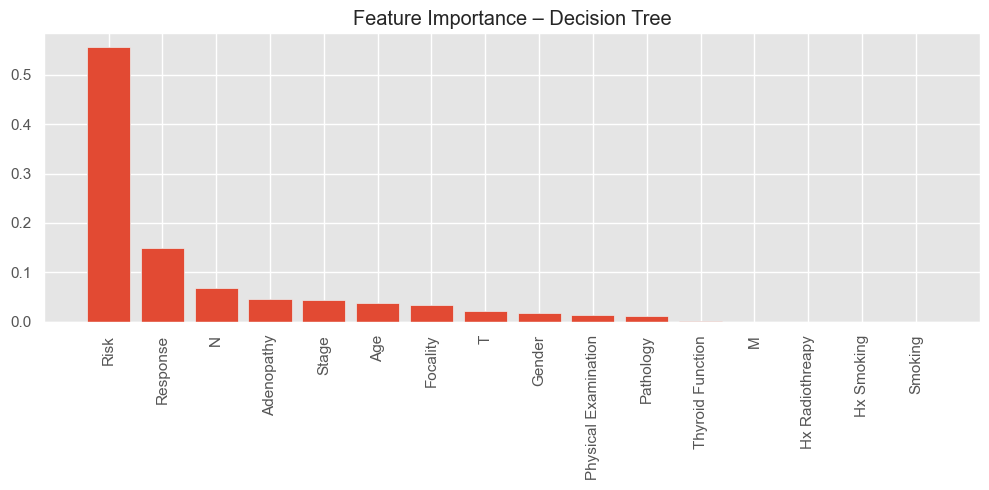

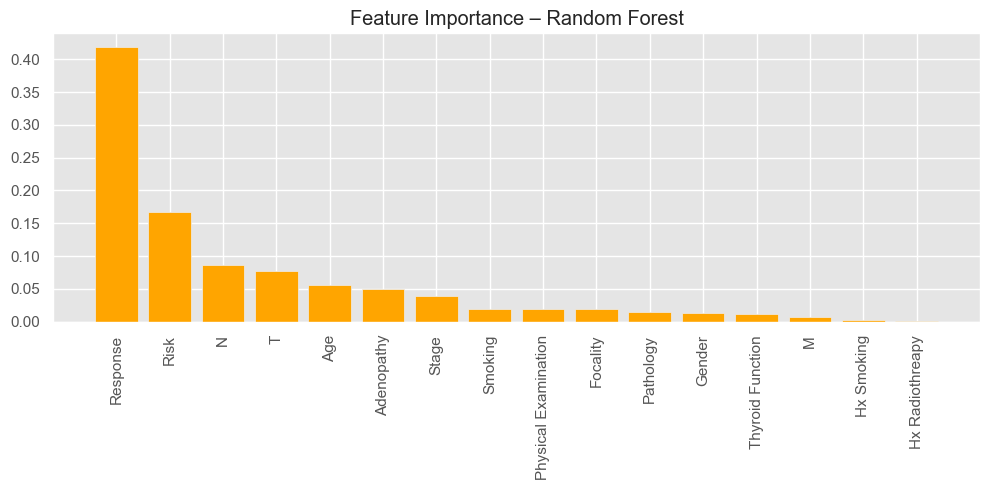

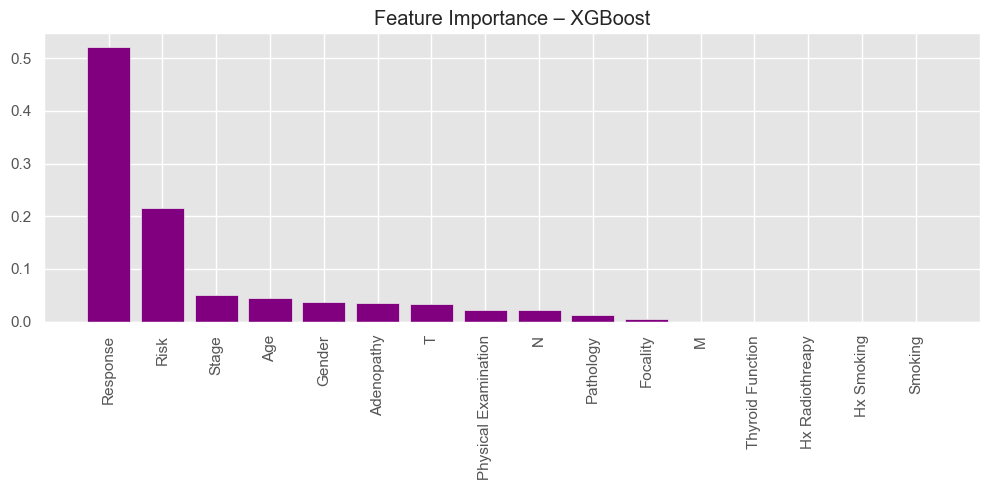

In [3457]:
#  Beste Modelle aus dem Tuning
best_dt = grid_search.best_estimator_          # Decision Tree
best_rf = grid_search_rf.best_estimator_       # Random Forest
best_xgb = grid_search_xgb.best_estimator_     # XGBoost

#  Feature Importance berechnen
importances_dt = best_dt.feature_importances_
importances_rf = best_rf.feature_importances_
importances_xgb = best_xgb.feature_importances_

#  Feature-Namen aus Trainingsdaten
feature_names = X_train.columns

#  Visualisierung – Entscheidungsbaum
indices_dt = np.argsort(importances_dt)[::-1]
plt.figure(figsize=(10, 5))
plt.title('Feature Importance – Decision Tree')
plt.bar(range(len(importances_dt)), importances_dt[indices_dt], align="center")
plt.xticks(range(len(importances_dt)), feature_names[indices_dt], rotation=90)
plt.tight_layout()
plt.show()

#  Visualisierung – Random Forest
indices_rf = np.argsort(importances_rf)[::-1]
plt.figure(figsize=(10, 5))
plt.title('Feature Importance – Random Forest')
plt.bar(range(len(importances_rf)), importances_rf[indices_rf], color='orange', align="center")
plt.xticks(range(len(importances_rf)), feature_names[indices_rf], rotation=90)
plt.tight_layout()
plt.show()

#  Visualisierung – XGBoost
indices_xgb = np.argsort(importances_xgb)[::-1]
plt.figure(figsize=(10, 5))
plt.title('Feature Importance – XGBoost')
plt.bar(range(len(importances_xgb)), importances_xgb[indices_xgb], color='purple', align="center")
plt.xticks(range(len(importances_xgb)), feature_names[indices_xgb], rotation=90)
plt.tight_layout()
plt.show()


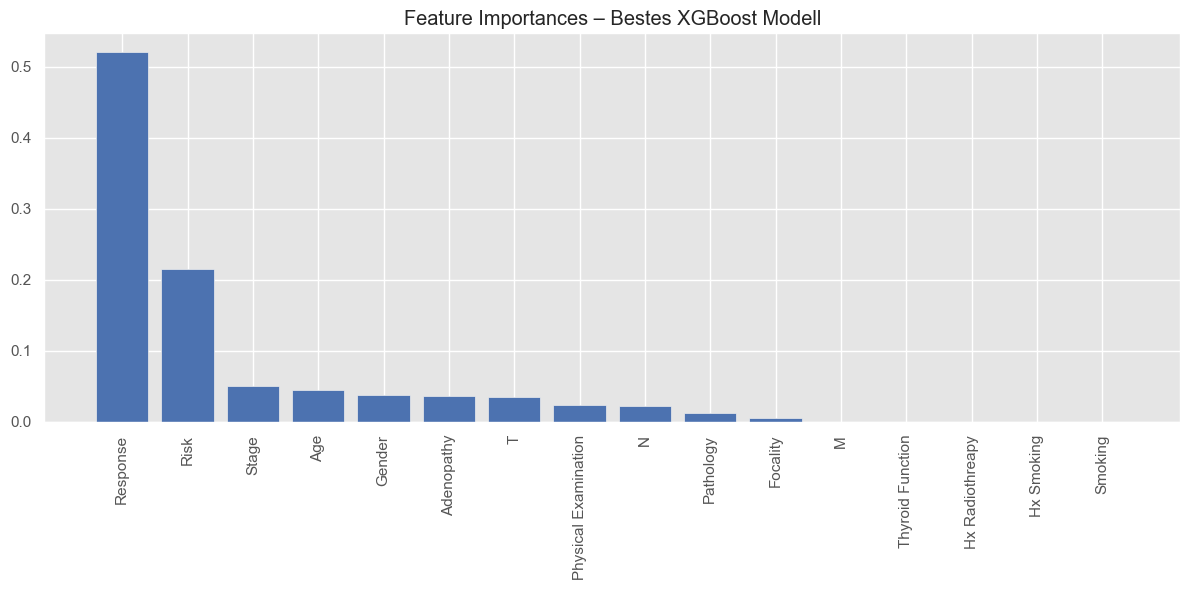

In [3461]:
#  Feature Importance – XGBoost
importances_xgb = best_xgb.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]
feature_names = X.columns

# Plot
plt.figure(figsize=(12, 6))
plt.title('Feature Importances – Bestes XGBoost Modell')
plt.bar(range(X.shape[1]), importances_xgb[indices_xgb], color="b", align="center")
plt.xticks(range(X.shape[1]), feature_names[indices_xgb], rotation=90)
plt.tight_layout()
plt.show()

# Zur Bewertung der wichtigsten Einflussgrößen auf die Vorhersage des Rezidivs (Recurred) wurden die Feature-Importances der drei besten Modelle analysiert. Die Auswertung zeigt, dass sowohl beim Random Forest als auch beim XGBoost Modell die Variablen **T**, **N**, **Response** und **Stage** eine hohe Bedeutung besitzen. Diese Ergebnisse stimmen mit medizinischen Erkenntnissen über die Relevanz von Tumorstadien und Behandlungsantworten überein.



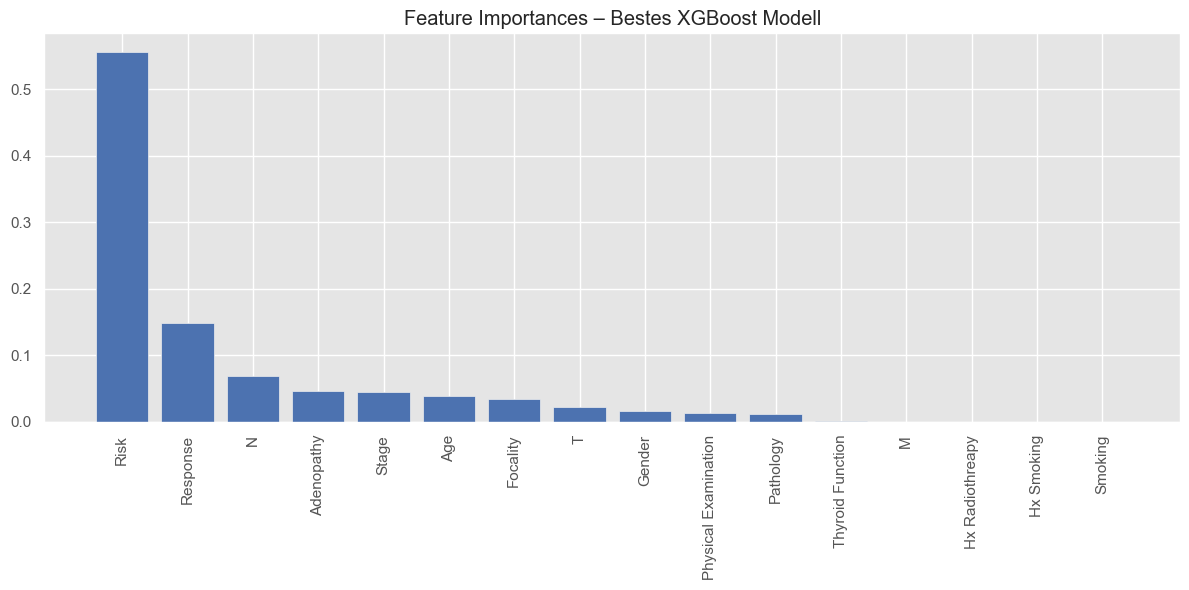

In [3463]:
#  Feature Importance vom besten XGBoost Modell berechnen
best_xgb = grid_search.best_estimator_  # Sicherstellen, dass dieses Model vorhanden ist
importances_xgb_best = best_xgb.feature_importances_
indices_xgb_best = np.argsort(importances_xgb_best)[::-1]

#  Plot erstellen
plt.figure(figsize=(12, 6))
plt.title('Feature Importances – Bestes XGBoost Modell')
plt.bar(range(X.shape[1]), importances_xgb_best[indices_xgb_best], color="b", align="center")
plt.xticks(range(X.shape[1]), X.columns[indices_xgb_best], rotation=90)
plt.tight_layout()
plt.show()

# Die Abbildung zeigt die Feature-Importances des besten XGBoost-Modells, das durch GridSearchCV optimiert wurde. 
# Besonders hervorzuheben sind Merkmale wie **T**, **N**, **Stage** und **Response**, die eine signifikante Rolle bei der 
# Vorhersage eines möglichen Rückfalls (Rezidiv) spielen. Die visuelle Gewichtung hilft bei der Interpretation und 
# zeigt, welche klinischen Faktoren für das Modell besonders entscheidend sind.



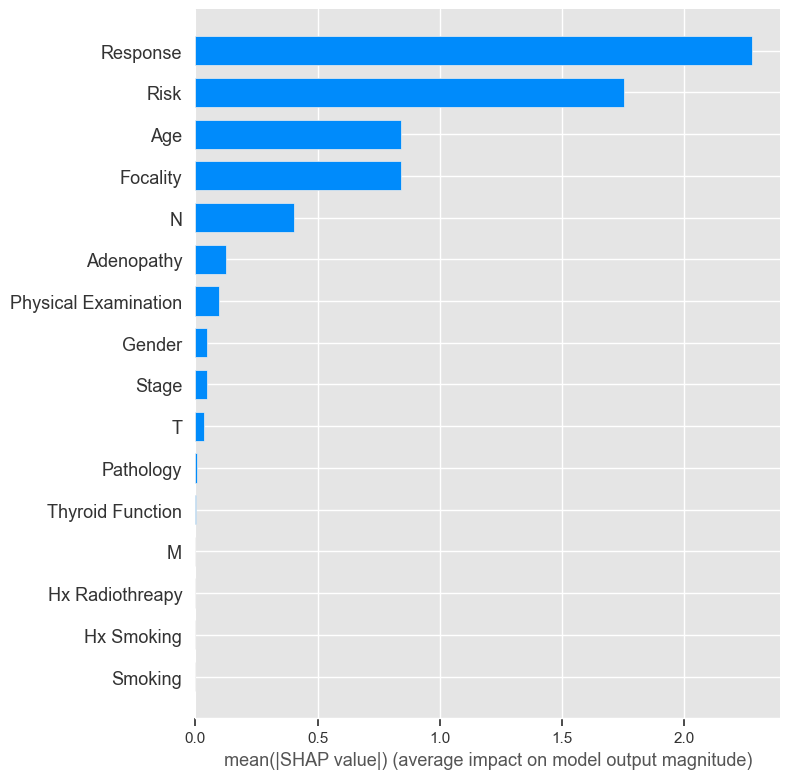

In [3465]:
# SHAP-Werte für das beste Entscheidungsbaummodell berechnen
explainer_dt = shap.TreeExplainer(best_dt)
shap_values_dt = explainer_dt.shap_values(X_train)

# SHAP-Zusammenfassungsplot (Balken)
shap.summary_plot(shap_values_dt, X_train, plot_type="bar")




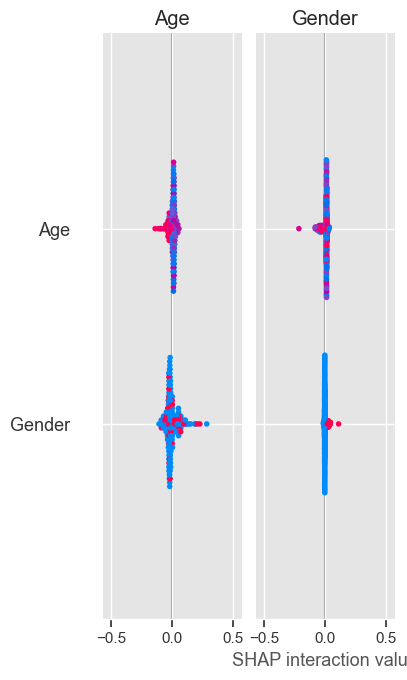

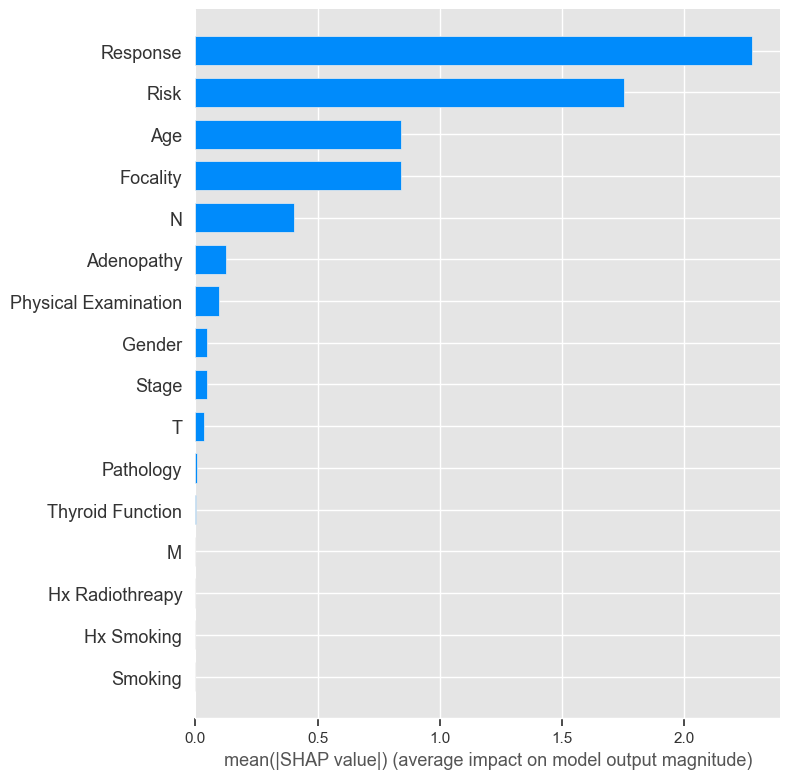

In [3467]:
# SHAP initialisieren (optional, für Jupyter Notebooks)
shap.initjs()

#  SHAP-Werte für Random Forest
explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf.shap_values(X_train)

#  SHAP Summary Plot (Bar)
shap.summary_plot(shap_values_rf, X_train, plot_type="bar")

#  SHAP-Werte für XGBoost
explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_train)

#  SHAP Summary Plot (Bar)
shap.summary_plot(shap_values_xgb, X_train, plot_type="bar")


In [3469]:
#  Ein Beispielindex aus dem Testset
i = 9
sample = X_test.iloc[i]
print("Merkmalswerte der Beispielinstanz:")
print(sample)

#  LIME-Erklärer für Klassifikation
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['Nicht rezidiviert', 'Rezidiviert'],
    mode='classification'
)

#  Erklärung mit dem besten Modell (z.B. XGBoost oder Random Forest)
exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=best_xgb.predict_proba  # ← oder best_rf.predict_proba
)

#  Visualisierung im Notebook
exp.show_in_notebook(show_table=True, show_all=False)


Merkmalswerte der Beispielinstanz:
Age                     29
Gender                   0
Smoking                  1
Hx Smoking               0
Hx Radiothreapy          0
Thyroid Function         2
Physical Examination     3
Adenopathy               3
Pathology                0
Focality                 1
Risk                     2
T                        2
N                        0
M                        0
Stage                    0
Response                 3
Name: 238, dtype: int64


In [3475]:

#  Bestes Modell für Entscheidungsbaum, Zufallswald und XGBoost definieren
best_tree = DecisionTreeClassifier(max_depth=5, random_state=42)  # Beispielwert, anpassen
best_rf = RandomForestClassifier(n_estimators=100, random_state=42)  # Beispielwert, anpassen
best_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)  # Beispielwert, anpassen

# Modelle trainieren (passende Trainingsdaten verwenden)
best_tree.fit(X_train, y_train)
best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)

#  Zielklassen: 0 = 'Nicht Rezidiviert', 1 = 'Rezidiviert'

#  Entscheidungsbaum: Vorhersagen für den Testdatensatz erstellen
y_pred1 = best_tree.predict(X_test)
report1 = classification_report(y_test, y_pred1, target_names=['Nicht Rezidiviert', 'Rezidiviert'])
print(" Klassifikationsbericht - Entscheidungsbaum")
print(report1)

#  Random Forest: Vorhersagen für den Testdatensatz erstellen
y_pred2 = best_rf.predict(X_test)
report2 = classification_report(y_test, y_pred2, target_names=['Nicht Rezidiviert', 'Rezidiviert'])
print(" Klassifikationsbericht - Random Forest")
print(report2)

#  XGBoost: Vorhersagen für den Testdatensatz erstellen (prüfen, ob y_pred3 existiert, falls nicht, erneut vorhersagen)
try:
    report3 = classification_report(y_test, y_pred3, target_names=['Nicht Rezidiviert', 'Rezidiviert'])
except NameError:
    y_pred3 = best_xgb.predict(X_test)
    report3 = classification_report(y_test, y_pred3, target_names=['Nicht Rezidiviert', 'Rezidiviert'])

print(" Klassifikationsbericht - XGBoost")
print(report3)


📊 Klassifikationsbericht - Entscheidungsbaum
                   precision    recall  f1-score   support

Nicht Rezidiviert       0.97      1.00      0.98        58
      Rezidiviert       1.00      0.89      0.94        19

         accuracy                           0.97        77
        macro avg       0.98      0.95      0.96        77
     weighted avg       0.97      0.97      0.97        77

📊 Klassifikationsbericht - Random Forest
                   precision    recall  f1-score   support

Nicht Rezidiviert       0.98      1.00      0.99        58
      Rezidiviert       1.00      0.95      0.97        19

         accuracy                           0.99        77
        macro avg       0.99      0.97      0.98        77
     weighted avg       0.99      0.99      0.99        77

📊 Klassifikationsbericht - XGBoost
                   precision    recall  f1-score   support

Nicht Rezidiviert       0.98      0.98      0.98        58
      Rezidiviert       0.95      0.95      0.

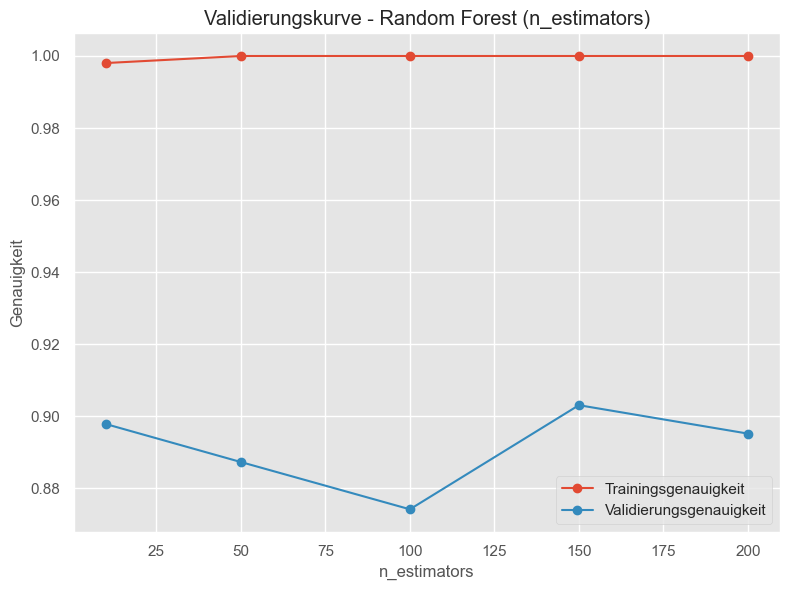

In [3477]:
#  Warnings ignorieren (z.B. wegen Pickle-Versionskonflikten)
warnings.filterwarnings('ignore')

#  Plot-Funktion für Validierungskurve
def plot_validation_curve(estimator, title, X, y, param_name, param_range, cv=5, scoring='accuracy'):
    train_scores, test_scores = validation_curve(
        estimator, X, y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring=scoring,
        n_jobs=1  #  Wichtig: Kein Parallelprozess wegen Pickle-Problemen
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
    plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
    plt.xlabel(param_name)
    plt.ylabel('Genauigkeit')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#  Modell vorbereiten
rf_model = RandomForestClassifier(random_state=42)

#  Anzahl der Bäume testen
param_range_rf = [10, 50, 100, 150, 200]

#  Kurve plotten
plot_validation_curve(
    estimator=rf_model,
    title='Validierungskurve - Random Forest (n_estimators)',
    X=X, y=y,
    param_name='n_estimators',
    param_range=param_range_rf,
    cv=5,
    scoring='accuracy'
)


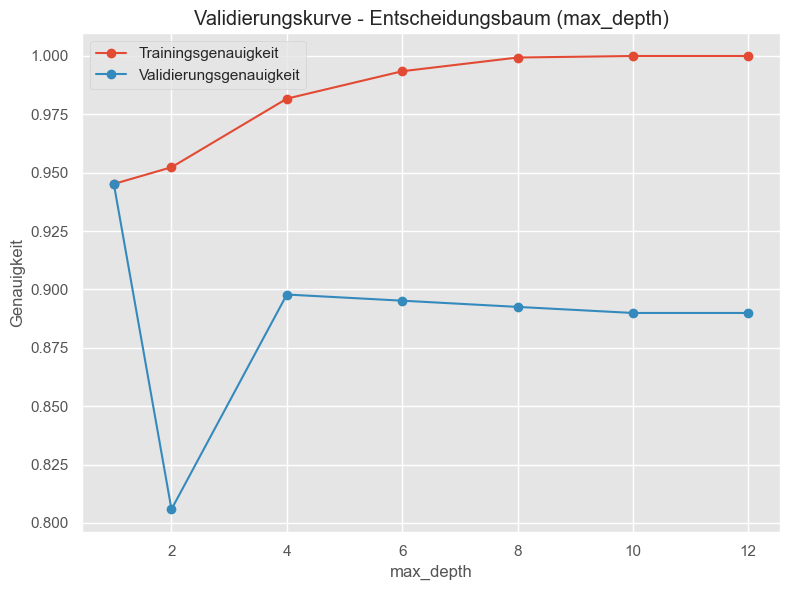

In [3479]:
#  Plot-Funktion
def plot_validation_curve(estimator, title, X, y, param_name, param_range, cv=5, scoring='accuracy'):
    from sklearn.model_selection import validation_curve


    train_scores, test_scores = validation_curve(
        estimator, X, y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring=scoring,
        n_jobs=1  #  Kein Parallel wegen Pickle-Problemen
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
    plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
    plt.xlabel(param_name)
    plt.ylabel('Genauigkeit')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#  Validierungskurve für Entscheidungsbaum
estimator = DecisionTreeClassifier(random_state=42)  # Alternativ: model1 falls bereits trainiert
param_name = 'max_depth'
param_range = [1, 2, 4, 6, 8, 10, 12]

plot_validation_curve(
    estimator=estimator,
    title='Validierungskurve - Entscheidungsbaum (max_depth)',
    X=X,
    y=y,
    param_name=param_name,
    param_range=param_range
)


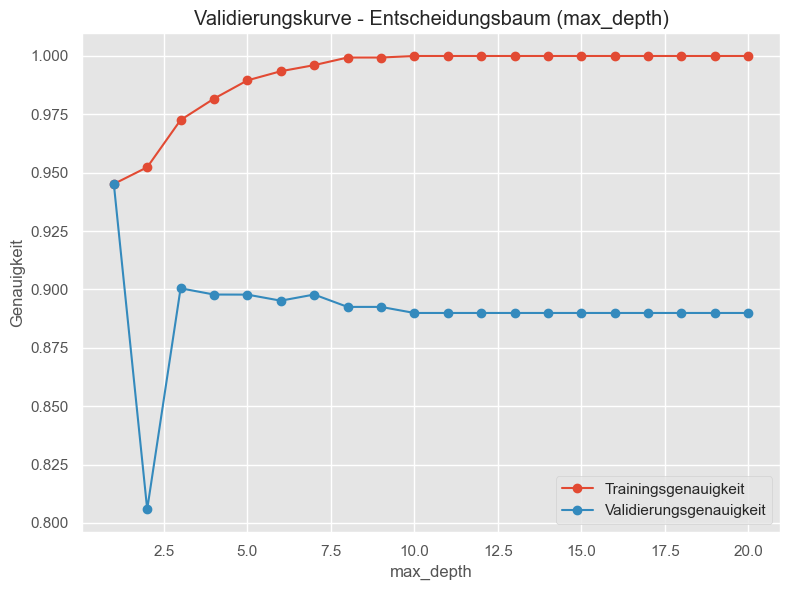

In [3481]:
#  Estimator Für Bäume
estimator = DecisionTreeClassifier(random_state=42)

#  Parameterbereich: Tiefe von 1 bis 20
param_name = 'max_depth'
param_range = np.arange(1, 21)

#  Validierungskurven generieren (n_jobs=1 wegen Pickle-Problemen)
train_scores, test_scores = validation_curve(
    estimator, X, y,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=1  # Wichtig, um BrokenProcessPool zu vermeiden
)

#  Mittelwerte berechnen
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

#  Plotten
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
plt.title('Validierungskurve - Entscheidungsbaum (max_depth)')
plt.xlabel('max_depth')
plt.ylabel('Genauigkeit')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


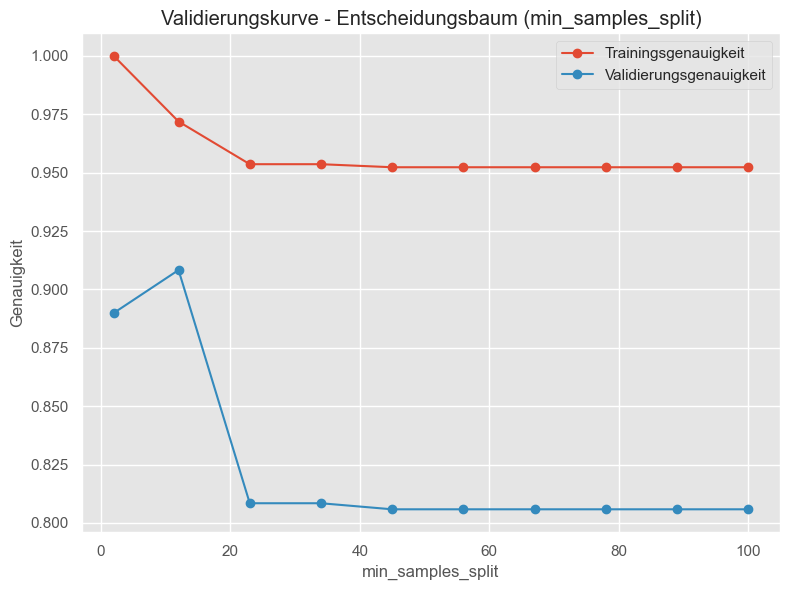

In [3483]:
#  Estimator (Decision Tree Classifier)
estimator = DecisionTreeClassifier(random_state=42)

#  Parameter: min_samples_split von 2 bis 100 in 10 gleichmäßigen Schritten
param_name = 'min_samples_split'
param_range = np.linspace(2, 100, 10, dtype=int)

#  Validation Curve berechnen
train_scores, test_scores = validation_curve(
    estimator, X, y,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=1  #  n_jobs=1 wegen BrokenProcessPool auf deinem System
)

#  Mittelwerte berechnen
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

#  Plot erstellen
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
plt.title('Validierungskurve - Entscheidungsbaum (min_samples_split)')
plt.xlabel('min_samples_split')
plt.ylabel('Genauigkeit')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


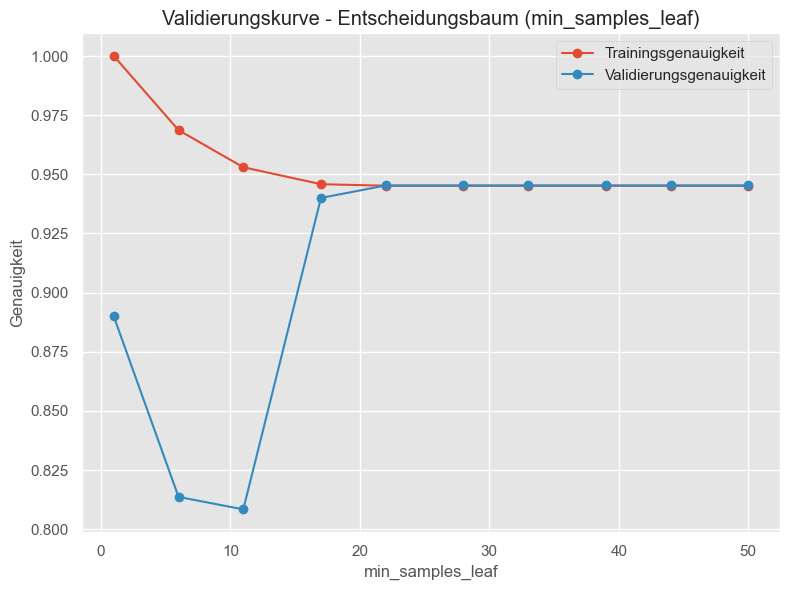

In [3485]:
#  Modell: Entscheidungsbaum
estimator = DecisionTreeClassifier(random_state=42)

#  Parameter: min_samples_leaf von 1 bis 50 (10 Schritte)
param_name = 'min_samples_leaf'
param_range = np.linspace(1, 50, 10, dtype=int)

#  Validation Curve berechnen
train_scores, test_scores = validation_curve(
    estimator, X, y,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=1  #  Kein Parallelbetrieb wegen lokaler Pickling-Probleme
)

#  Mittelwerte berechnen
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

#  Plot erzeugen
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
plt.title('Validierungskurve - Entscheidungsbaum (min_samples_leaf)')
plt.xlabel('min_samples_leaf')
plt.ylabel('Genauigkeit')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


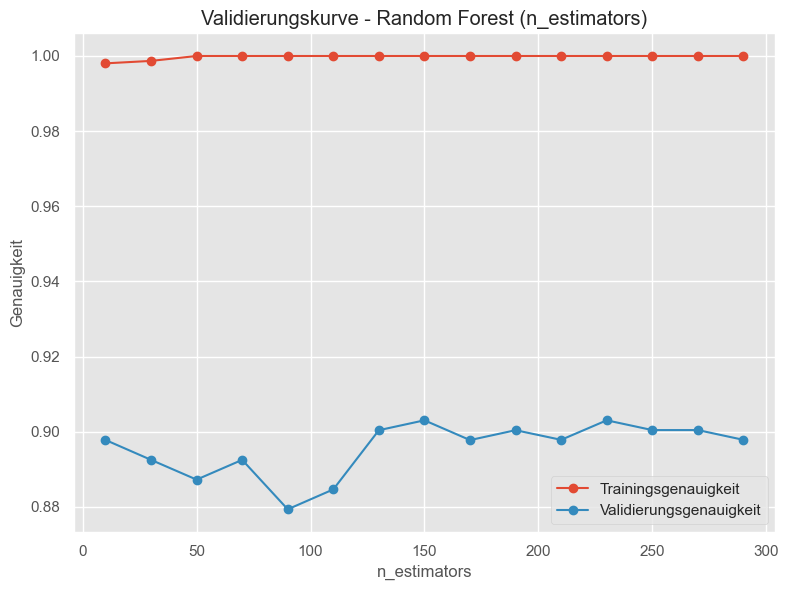

In [3487]:
#  Modell: Random Forest
estimator = RandomForestClassifier(random_state=42)

#  Parameter: Anzahl der Bäume (n_estimators) von 10 bis 290 in Schritten von 20
param_name = 'n_estimators'
param_range = np.arange(10, 300, 20)

#  Validation Curve berechnen
train_scores, test_scores = validation_curve(
    estimator, X, y,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=1  #  Kein Parallelbetrieb wegen Pickling-Problemen (lokal)
)

#  Mittelwerte berechnen
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

#  Plot erzeugen
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
plt.title('Validierungskurve - Random Forest (n_estimators)')
plt.xlabel('n_estimators')
plt.ylabel('Genauigkeit')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


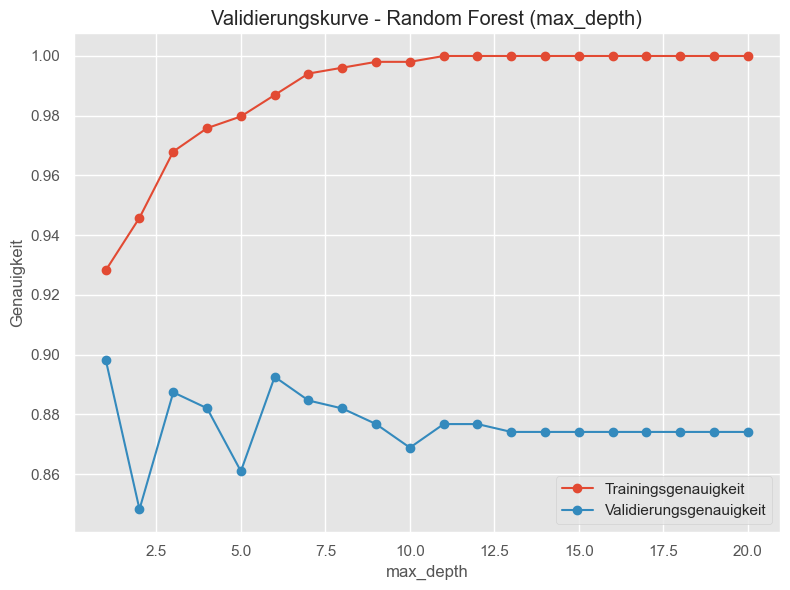

In [3489]:
#  Modell: Random Forest
estimator = RandomForestClassifier(random_state=42)

#  Parameter: maximale Tiefe der Bäume
param_name = 'max_depth'
param_range = np.arange(1, 21)  # Tiefe von 1 bis 20

#  Validation Curve berechnen
train_scores, test_scores = validation_curve(
    estimator, X, y,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=1  #  Kein Parallelbetrieb (lokal, wegen Pickle-Fehlern)
)

#  Mittelwerte berechnen
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

#  Plot erzeugen
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
plt.title('Validierungskurve - Random Forest (max_depth)')
plt.xlabel('max_depth')
plt.ylabel('Genauigkeit')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


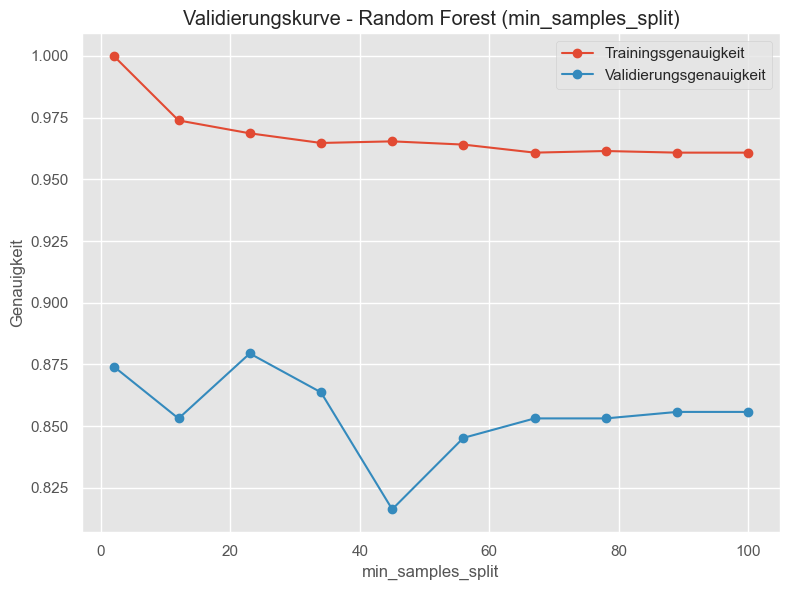

In [3491]:
#  Random Forest Modell
estimator = RandomForestClassifier(random_state=42)

#  Parameter: Minimale Stichprobengröße für einen Split
param_name = 'min_samples_split'
param_range = np.linspace(2, 100, 10, dtype=int)  # Werte von 2 bis 100 in 10 Schritten

#  Validierungskurve berechnen
train_scores, test_scores = validation_curve(
    estimator, X, y,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=1  # Kein Parallelbetrieb wegen Pickle-Problemen
)

#  Mittelwerte berechnen
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

#  Plot erzeugen
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
plt.title('Validierungskurve - Random Forest (min_samples_split)')
plt.xlabel('min_samples_split')
plt.ylabel('Genauigkeit')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


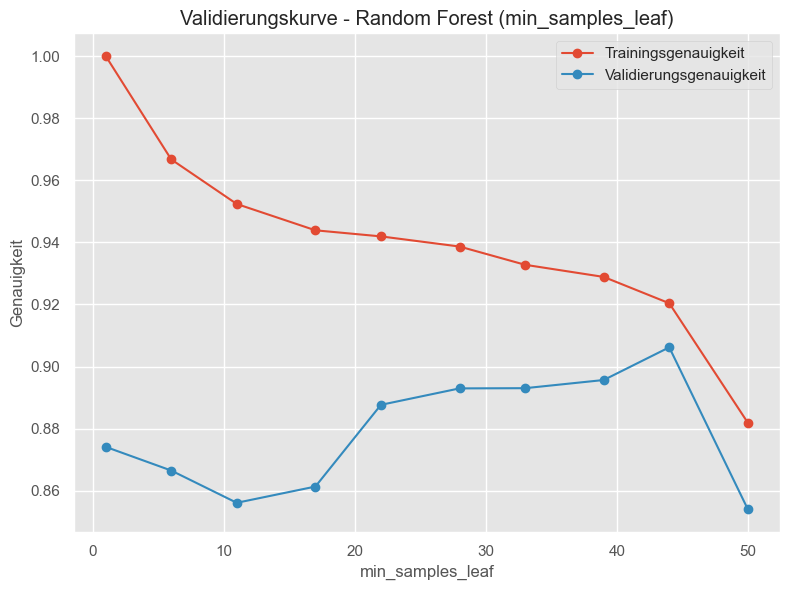

In [3493]:
#  Random Forest Klassifikator
estimator = RandomForestClassifier(random_state=42)

#  Parameter: Minimale Anzahl der Samples in einem Blattknoten
param_name = 'min_samples_leaf'
param_range = np.linspace(1, 50, 10, dtype=int)  # Von 1 bis 50 in 10 Schritten

#  Validierungskurve berechnen
train_scores, test_scores = validation_curve(
    estimator, X, y,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=1  #  Kein Parallelbetrieb wegen Pickle-Problemen
)

#  Mittelwerte berechnen
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

#  Plotten
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
plt.title('Validierungskurve - Random Forest (min_samples_leaf)')
plt.xlabel('min_samples_leaf')
plt.ylabel('Genauigkeit')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


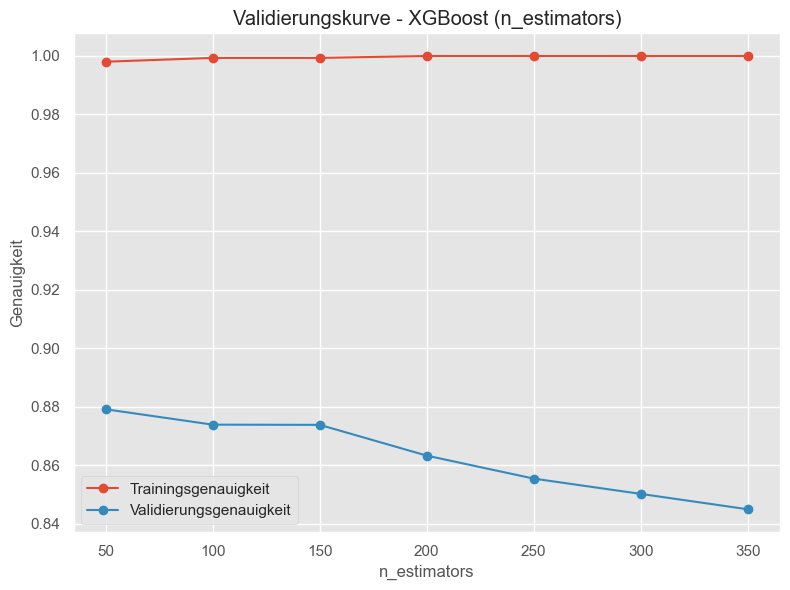

In [3495]:
#  XGBoost-Klassifikator
estimator = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

#  Parameter: Anzahl der Bäume
param_name = 'n_estimators'
param_range = np.arange(50, 400, 50)  # Von 50 bis 350 mit Schrittweite 50

#  Validierungskurve berechnen
train_scores, test_scores = validation_curve(
    estimator, X, y,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=1  #  Kein Parallelbetrieb wegen Pickle-Problemen
)

#  Mittelwerte berechnen
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

#  Plotten
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
plt.title('Validierungskurve - XGBoost (n_estimators)')
plt.xlabel('n_estimators')
plt.ylabel('Genauigkeit')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


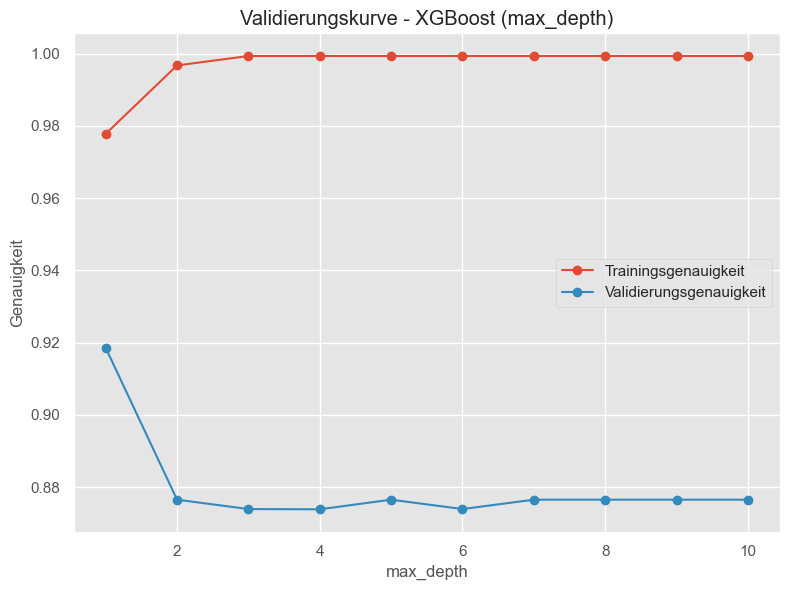

In [3497]:
#  Parameter: max_depth (Baumtiefe)
param_name = 'max_depth'
param_range = np.arange(1, 11)  # Von Tiefe 1 bis 10

#  Validierungskurve berechnen
train_scores, test_scores = validation_curve(
    estimator, X, y,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=1  # Kein Parallelbetrieb wegen Pickle-Problemen
)

#  Mittelwerte berechnen
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

#  Plotten
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
plt.title('Validierungskurve - XGBoost (max_depth)')
plt.xlabel('max_depth')
plt.ylabel('Genauigkeit')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


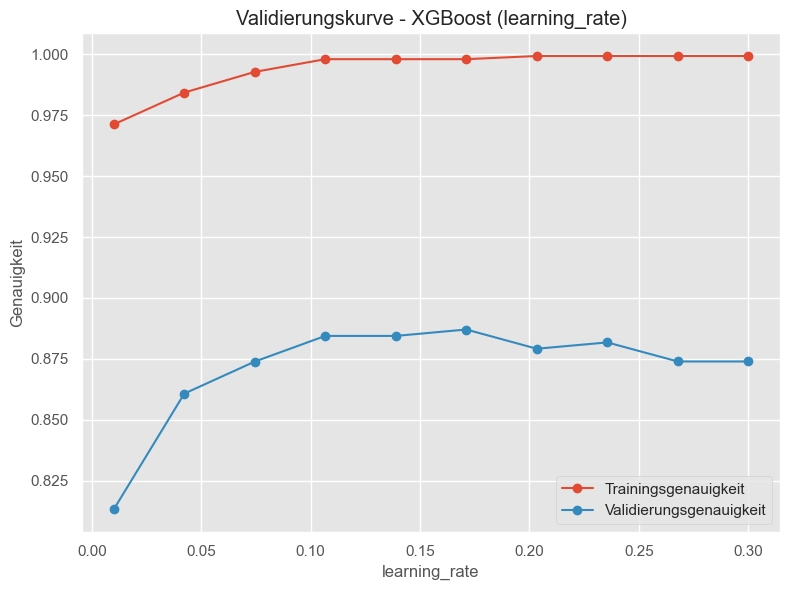

In [3499]:
#  Parameter: learning_rate (Lernrate)
param_name = 'learning_rate'
param_range = np.linspace(0.01, 0.3, 10)  # Von 0.01 bis 0.3 in 10 Schritten

#  Validierungskurve berechnen
train_scores, test_scores = validation_curve(
    estimator, X, y,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=1  # Kein Parallelbetrieb wegen Pickle-Problemen
)

#  Mittelwerte berechnen
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

#  Plotten
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
plt.title('Validierungskurve - XGBoost (learning_rate)')
plt.xlabel('learning_rate')
plt.ylabel('Genauigkeit')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


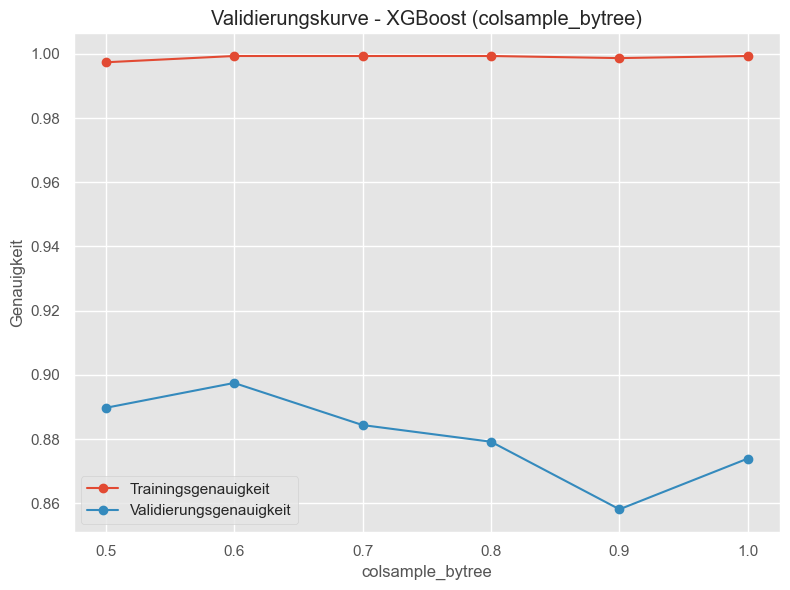

In [3501]:
#  Parameter: colsample_bytree (Anteil der Merkmale pro Baum)
param_name = 'colsample_bytree'
param_range = np.linspace(0.5, 1.0, 6)  # Von 0.5 bis 1.0 in 6 Schritten

#  Validierungskurve berechnen
train_scores, test_scores = validation_curve(
    estimator, X, y,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=1  # Keine Parallelisierung wegen Pickle-Problem
)

#  Mittelwerte berechnen
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

#  Plotten
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
plt.title('Validierungskurve - XGBoost (colsample_bytree)')
plt.xlabel('colsample_bytree')
plt.ylabel('Genauigkeit')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


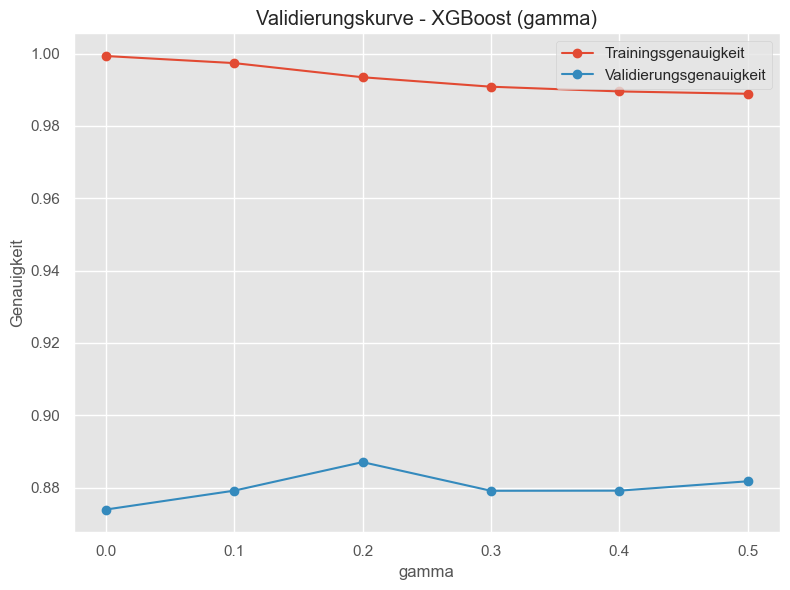

In [3503]:
#  Parameter: gamma (Mindestverlustreduzierung für Splits)
param_name = 'gamma'
param_range = np.linspace(0, 0.5, 6)  # Werte von 0 bis 0.5

#  Validierungskurve berechnen
train_scores, test_scores = validation_curve(
    estimator, X, y,
    param_name=param_name,
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=1  # Kein Parallel wegen Pickle-Fehler
)

#  Mittelwerte berechnen
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

#  Plotten
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_scores_mean, label='Trainingsgenauigkeit', marker='o')
plt.plot(param_range, test_scores_mean, label='Validierungsgenauigkeit', marker='o')
plt.title('Validierungskurve - XGBoost (gamma)')
plt.xlabel('gamma')
plt.ylabel('Genauigkeit')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()
